In [1]:
library(dplyr)
library(readr)
library(tidyr)
library(stringr)
library(ggplot2)
library(microshades)
library(openxlsx)
library(GenomicSEM)

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“replacing previous import ‘gdata::nobs’ by ‘lavaan::nobs’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::first’ by ‘data.table::first’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::last’ by ‘data.table::last’ when loading ‘GenomicSEM’”
Warning message:
“replacing previous import ‘gdata::resample’ by ‘R.utils::resample’ when loading ‘GenomicSEM’”
Warning message:
“replacing p

In [2]:
sample_sizes <- read_csv(
  "
Pheno,Nca,Nco,Neff
Clin,27196,43792,67108.0876767904
Comm,32091,737230,123009.500221624
BDI,25060,449978,94951.971673845
BDII,6781,364075,26628.0451172423
ADHD,19099,34194,45684.86
AN,16992,55525,46321.9
ALC,NA,NA,26853.43
ASD,18381,27969,44366.62
MDD,357636,1281936,1118502.79
BMI,NA,NA,681275
CAD,95830,385536,285937.77
Chrono,NA,NA,449734
CRP,NA,NA,204402
Height,NA,NA,693529
Neu,NA,NA,390278
PD,2147,7760,6665.06
PTSD,23212,151447,140475
SCZ,53386,77258,117498.3
Smoking,NA,NA,263954
T2D,80154,853816,251739.50
PartEM,NA,NA,356560.32
PartMH,NA,NA,311999.52
PartSF,NA,NA,449041.88
"
)

#BIP,59287,781022,163367

Rows: 23 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Pheno
dbl (3): Nca, Nco, Neff

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Population and sample prevalences

In [3]:
#sample prevalences can be set to 0.5 as N for the munged files has been converted to effective N. It could also be odne by specifying the correct sample prevalence when convertint to the liability scale, but for compatibility purposes the neffe variant has been applied
bip_prevalences <- c("Clin" = 0.02, "Comm" = 0.02, "BDI" = 0.01, "BDII" = 0.01)
bip_names <- names(bip_prevalences)

other_prevalences <- c(
  "ADHD" = 0.03, "ALC" = 0.16, "AN" = 0.01,
  "ASD" = 0.01, "MDD" = 0.15, "BMI" = NA,
  "CAD" = 0.05, "Chrono" = NA, "CRP" = NA,
  "Height" = NA, "Neu" = NA, "PD" = 0.03,
  "PTSD" = 0.3, "SCZ" = 0.01, "Smoking" = NA,
  "T2D" = 0.06, "PartEM" = 0.6, "PartMH" = 0.3, "PartSF" = 0.5
)
other_names <- names(other_prevalences)

all_prevalences <- c(bip_prevalences, other_prevalences)
all_names <- names(all_prevalences)

#"BIP" = 0.01

## LDSC

In [4]:
#load the paths of necessary documents as not all of them are in this directory
ld <- "/local1/hdata/REF/eur_ref_ld_chr"
weights <- "/local1/hdata/REF/eur_w_ld_chr"
samples <- c("/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_clinical_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_community_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDI_cleaned_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDII_cleaned_neff.sumstats.gz")
sample_names <-c("Clin", "Comm", "BDI", "BDII")
other_basepath <- "/local1/scratch/pazweifel/sumstats_ambits/munged/" #phenotype.sumstats.gz

In [5]:
#create a matrices directory
#dir.create("matrices", showWarnings = FALSE)
#create a path for a covstruct object where you store the covariance structure of the bipolar disorders and store it in the matrices directory
covstruct_bip <- here::here("matrices",paste("BD", "R", sep = "."))
#extract population prevalence 
pop_prev <- as.vector(all_prevalences[bip_names])
#fill the samp_prev vector depending on the pop_prev vector, if NA use NA and if not use 0.5
samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))
#check if the covstruct file already exists to not do the analysis unnecessarily, first time no file there
if (!file.exists(covstruct_bip)){
    covstruct_bip_ldsc <- ldsc(
        traits = samples,
        trait.names = sample_names,
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_bip_ldsc, covstruct_bip, control = c("all", "digits17"))
}

In [6]:
# do the same thing but include the other phenotypes one by one and name them after the current phenotype used
for (phenotype in other_names){
    covstruct_pheno <- here::here("matrices",paste(phenotype,"R", sep = "."))
    #extract population prevalences
    pop_prev <- c(all_prevalences[bip_names], all_prevalences[phenotype])
    #fill the sample prevalences depending on pop vector
    samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))
    #concatenate the sample vector with the bip filepaths and the specific single phenotype filepath
    if (phenotype == "MDD"){
        samples_plus1 <- c(samples, "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz")
    } else {
        samples_plus1 <- c(samples, paste0(other_basepath,phenotype,".sumstats.gz"))
    }
    #check if file already exists
    if (!file.exists(covstruct_pheno)){
        covstruct_ldsc <- ldsc(
            traits = samples_plus1,
            trait.names = c(sample_names, phenotype),
            sample.prev = samp_prev,
            population.prev = pop_prev,
            ld = ld,
            wld = weights,
            stand = TRUE
        )
        dput(covstruct_ldsc, covstruct_pheno, control = c("all", "digits17"))
    }
}
        

## Modelling

In [7]:
#First define the base model
#get the base covariance matrix from the matrices directory
covstruct_base <- dget(here::here("matrices/BD.R"))
#define the model using NA*Clin to say that this parameter loading has to be freely estimated, we fix the factor variance to 1 and ensure residual genetic variance of phenotypes isnt negative
base_model <- "BD=~NA*Clin+Comm+BDI+BDII
BD~~1*BD
Clin~~a*Clin
a > .0001"

base.fit <- usermodel(covstruct_base,
                      estimation = "DWLS",
                      model = base_model,
                      imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.306 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00230032743668621 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.243467754445721 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruct_base, estimation = "DWLS", model = base_model, :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [8]:
base.fit

$modelfit
      chisq df    p_chisq      AIC       CFI       SRMR
df 7.353786  2 0.02530147 23.35379 0.9988052 0.02269718

$results
   lhs op  rhs Unstand_Est          Unstand_SE STD_Genotype    STD_Genotype_SE
3   BD =~ Clin 0.437244488  0.0132666812073236   1.00388390  0.030452824624281
4   BD =~ Comm 0.222550644  0.0107035722732005   0.94115926 0.0452655874835151
1   BD =~  BDI 0.347975938  0.0108876974489879   0.96139931 0.0300815557844358
2   BD =~ BDII 0.259795073  0.0161819761794392   0.90268989 0.0562267964986999
8 Clin ~~ Clin 0.000100000  0.0059768042373838   0.00010000 0.0315011407299536
9 Comm ~~ Comm 0.006381599 0.00436246046159522   0.11421924 0.0780207353579752
6  BDI ~~  BDI 0.009907505  0.0041582135922471   0.07571137 0.0317402156907084
7 BDII ~~ BDII 0.015331898 0.00890446721169956   0.18515097  0.107508931508311
5   BD ~~   BD 1.000000000                       1.00000000                   
     STD_All       p_value
3 1.00388390 3.239503e-238
4 0.94115926  5.093900e-96
1 0.96139931 3.864922e-224
2 0.90268989  5.308433e-58
8 0.00010000  9.866509e-01
9 0.11421924  1.435101e-01
6 0.07571137  1.718923e-02
7 0.18515097  8.510197e-02
5 1.00000000            NA

$resid_cov
$resid_cov$`Model Implied Covariance Matrix`
           Clin       Comm        BDI       BDII
Clin 0.19128274 0.09730904 0.15215056 0.11359396
Comm 0.09730904 0.05591039 0.07744227 0.05781756
BDI  0.15215056 0.07744227 0.13099476 0.09040243
BDII 0.11359396 0.05781756 0.09040243 0.08282538

$resid_cov$`Residual Covariance Matrix: Calculated as Observed Cov - Model Implied Cov`
              Clin          Comm           BDI          BDII
Clin -0.0015200616 -8.066022e-04  4.209113e-03 -1.352099e-03
Comm -0.0008066022 -1.545641e-09 -1.240123e-03  3.868260e-03
BDI   0.0042091125 -1.240123e-03 -9.447785e-09 -2.863656e-03
BDII -0.0013520993  3.868260e-03 -2.863656e-03  3.548273e-09

In [9]:
base.fit$results

,lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
3,BD,=~,Clin,0.437244488,0.0132666812073236,1.00388390,0.030452824624281,1.00388390,3.239503e-238
4,BD,=~,Comm,0.222550644,0.0107035722732005,0.94115926,0.0452655874835151,0.94115926,5.093900e-96
1,BD,=~,BDI,0.347975938,0.0108876974489879,0.96139931,0.0300815557844358,0.96139931,3.864922e-224
2,BD,=~,BDII,0.259795073,0.0161819761794392,0.90268989,0.0562267964986999,0.90268989,5.308433e-58
8,Clin,~~,Clin,0.000100000,0.0059768042373838,0.00010000,0.0315011407299536,0.00010000,9.866509e-01
9,Comm,~~,Comm,0.006381599,0.00436246046159522,0.11421924,0.0780207353579752,0.11421924,1.435101e-01
6,BDI,~~,BDI,0.009907505,0.0041582135922471,0.07571137,0.0317402156907084,0.07571137,1.718923e-02
7,BDII,~~,BDII,0.015331898,0.00890446721169956,0.18515097,0.107508931508311,0.18515097,8.510197e-02
5,BD,~~,BD,1.000000000,,1.00000000,,1.00000000,NA


Clin,Comm,BDI,BDII
0.05691824,0.05697720,0.05415812,0.07875669
0.05697720,0.07845389,0.05672839,0.08664490
0.05415812,0.05672839,0.05427365,0.07053401
0.07875669,0.08664490,0.07053401,0.15183248


x,y,values,se
<fct>,<fct>,<dbl>,<dbl>
Clin,Clin,1.00,0.06
Comm,Clin,0.95,0.06
BDI,Clin,1.02,0.05
BDII,Clin,0.90,0.08
Clin,Comm,0.95,0.06
Comm,Comm,1.00,0.08
BDI,Comm,0.89,0.06
BDII,Comm,0.91,0.09
Clin,BDI,1.02,0.05


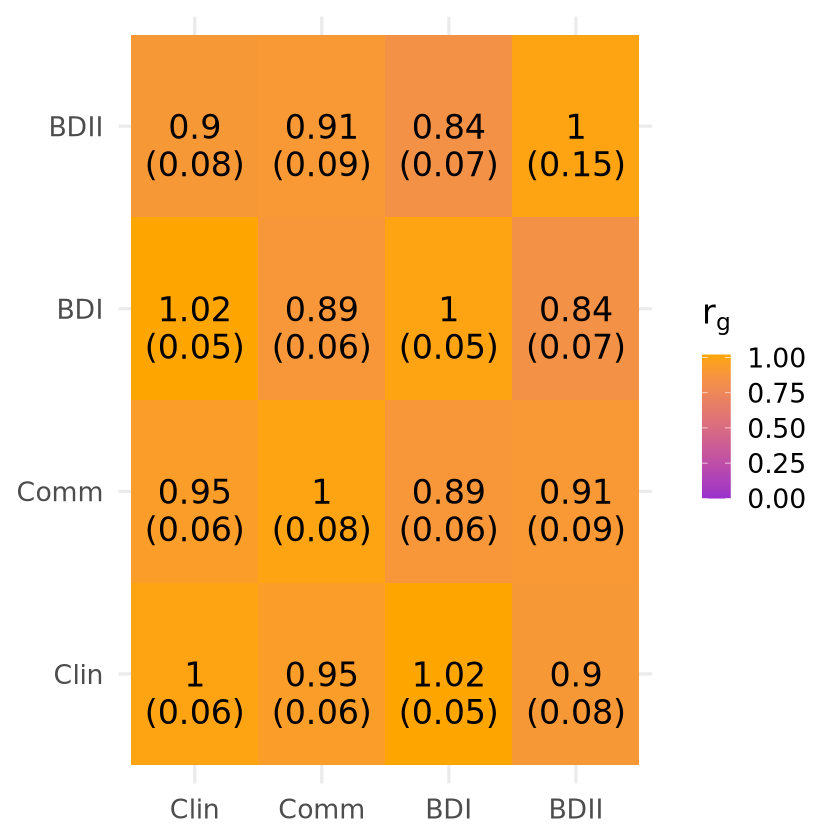

In [295]:
sstand <- covstruct_base$S_Stand
vstand <- covstruct_base$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:10), function(index) vstand[index, index])
                      
#copy the structure of the sstand matrix
error_matrix <- sstand
                      
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
                      
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
error_matrix
                      
#vectorize the error matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)

#initialize the dataframe for the matrix values of both matrices
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

#vectorize the standard matrix and store matrix values in df columns
sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 2)
expanded_df$se <- round(error_vectorized, 2)
expanded_df
#create the ggplot
correlation_plot <- ggplot(expanded_df, aes(x = x, y = y, fill = values)) +
scale_fill_gradient(low = "darkorchid", high = "orange", limits = c(0, max(expanded_df$values))) +
theme_minimal(base_size = 20) +
geom_tile() +
theme(axis.title = element_blank()) +
labs(fill = expression(r[g])) +
geom_text(aes(label = values)) +
geom_text(aes(label = paste0("(",se,")"), vjust = 2))

correlation_plot

In [296]:
ggsave("/local1/home/pazweifel/plots/bip_paper/correlation_matrix.pdf", correlation_plot, width = 7, height = 5, device = "pdf")

In [297]:
write_csv(expanded_df, "/local1/home/pazweifel/plots/bip_paper/correlations_base.csv")

In [12]:
#same thing but with fixed loading of 1 on the clinical, factor variance freely estimated
anchor_model <- "BD=~1*Clin+Comm+BDI+BDII
BD~~BD
Clin~~a*Clin
a > 0.0001
"
anchor.fit <- usermodel(covstruct_base,
                        estimation = "DWLS",
                        model = anchor_model,
                        imp_cov = TRUE
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.225 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00230032743668621 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.243467754445721 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruct_base, estimation = "DWLS", model = anchor_model, :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [13]:
anchor.fit$modelfit

,chisq,df,p_chisq,AIC,CFI,SRMR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df,7.353768,2,0.02530169,23.35377,0.9988052,0.02269717


## Pathway models


In [14]:
#define the common and the independent pathway models and introduce a placeholder which can filled by the repsective phenotype corresponding to the used covariance matrix
#set the factor variance to 1
common.model <- "BD=~NA*Clin+Comm+BDI+BDII
BD~~{trait}
BD~~1*BD
Clin~~a*Clin
a > 0.0001
"

independent.model <- "BD=~NA*Clin+Comm+BDI+BDII
Clin~~{trait}
Comm~~{trait}
BDI~~{trait}
BDII~~{trait}
BD~~1*BD
Clin~~a*Clin
a > 0.0001
"

In [15]:
#define a list with trait names named after themselves, so that that the naming remains when using this list with lapply and therefore specific elements can be accessed by name
traits <- other_names
names(traits) <- traits
traits

ADHD       ALC        AN       ASD       MDD       BMI       CAD    Chrono 
   "ADHD"     "ALC"      "AN"     "ASD"     "MDD"     "BMI"     "CAD"  "Chrono" 
      CRP    Height       Neu        PD      PTSD       SCZ   Smoking       T2D 
    "CRP"  "Height"     "Neu"      "PD"    "PTSD"     "SCZ" "Smoking"     "T2D" 
   PartEM    PartMH    PartSF 
 "PartEM"  "PartMH"  "PartSF"

In [16]:
#make a named vector with all the common models and all the applied models, take advantage of the palceholder introduced
traits_common.models <- lapply(traits, 
                               function(trait) str_glue(common.model)
)

traits_independent.models <- lapply(traits,
                                    function(trait) str_glue(independent.model)
)

In [17]:
traits_independent.models

$ADHD
BD=~NA*Clin+Comm+BDI+BDII
Clin~~ADHD
Comm~~ADHD
BDI~~ADHD
BDII~~ADHD
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$ALC
BD=~NA*Clin+Comm+BDI+BDII
Clin~~ALC
Comm~~ALC
BDI~~ALC
BDII~~ALC
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$AN
BD=~NA*Clin+Comm+BDI+BDII
Clin~~AN
Comm~~AN
BDI~~AN
BDII~~AN
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$ASD
BD=~NA*Clin+Comm+BDI+BDII
Clin~~ASD
Comm~~ASD
BDI~~ASD
BDII~~ASD
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$MDD
BD=~NA*Clin+Comm+BDI+BDII
Clin~~MDD
Comm~~MDD
BDI~~MDD
BDII~~MDD
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$BMI
BD=~NA*Clin+Comm+BDI+BDII
Clin~~BMI
Comm~~BMI
BDI~~BMI
BDII~~BMI
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$CAD
BD=~NA*Clin+Comm+BDI+BDII
Clin~~CAD
Comm~~CAD
BDI~~CAD
BDII~~CAD
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$Chrono
BD=~NA*Clin+Comm+BDI+BDII
Clin~~Chrono
Comm~~Chrono
BDI~~Chrono
BDII~~Chrono
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$CRP
BD=~NA*Clin+Comm+BDI+BDII
Clin~~CRP
Comm~~CRP
BDI~~CRP
BDII~~CRP
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$Height
BD=~NA*Clin+Comm+BDI+BDII
Clin~~Height
Comm~~Height
BDI~~Height
BDII~~Height
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$Neu
BD=~NA*Clin+Comm+BDI+BDII
Clin~~Neu
Comm~~Neu
BDI~~Neu
BDII~~Neu
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$PD
BD=~NA*Clin+Comm+BDI+BDII
Clin~~PD
Comm~~PD
BDI~~PD
BDII~~PD
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$PTSD
BD=~NA*Clin+Comm+BDI+BDII
Clin~~PTSD
Comm~~PTSD
BDI~~PTSD
BDII~~PTSD
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$SCZ
BD=~NA*Clin+Comm+BDI+BDII
Clin~~SCZ
Comm~~SCZ
BDI~~SCZ
BDII~~SCZ
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$Smoking
BD=~NA*Clin+Comm+BDI+BDII
Clin~~Smoking
Comm~~Smoking
BDI~~Smoking
BDII~~Smoking
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$T2D
BD=~NA*Clin+Comm+BDI+BDII
Clin~~T2D
Comm~~T2D
BDI~~T2D
BDII~~T2D
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$PartEM
BD=~NA*Clin+Comm+BDI+BDII
Clin~~PartEM
Comm~~PartEM
BDI~~PartEM
BDII~~PartEM
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$PartMH
BD=~NA*Clin+Comm+BDI+BDII
Clin~~PartMH
Comm~~PartMH
BDI~~PartMH
BDII~~PartMH
BD~~1*BD
Clin~~a*Clin
a > 0.0001

$PartSF
BD=~NA*Clin+Comm+BDI+BDII
Clin~~PartSF
Comm~~PartSF
BDI~~PartSF
BDII~~PartSF
BD~~1*BD
Clin~~a*Clin
a > 0.0001

In [18]:
#load the genetic covariance matrices
trait.covstructs <- lapply(traits, 
                           function(trait) dget(here::here("matrices",paste(trait,"R", sep = ".")))
)

In [19]:
#now fit the common and the independent models using the two vectors
trait_common.fit <- lapply(traits, 
                           function(trait) {
                               usermodel(trait.covstructs[[trait]],
                               estimation = "DWLS",
                               model = traits_common.models[[trait]],
                               imp_cov = TRUE
    )
  }
)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.228 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00237470346007324 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.243082909605935 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.221 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00234281191239169 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.246072968698442 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.241 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00230453312512133 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.245173492660783 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


...

Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.456 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00231800455246403 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.246224823437142 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.236 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00239675491794403 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.251250603233693 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(trait.covstructs[[trait]], estimation = "DWLS", model = traits_common.models[[trait]], :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [ ]:
trait_independent.fit <- lapply(traits,
                                function(trait) {
                                    usermodel(
                                        trait.covstructs[[trait]],
                                        estimation = "DWLS",
                                        model = traits_independent.models[[trait]],
                                        imp_cov = TRUE
    )
  }
)

## ChiSquared difference between common and independent model

In [21]:
#define the chisquared function: a smaller chi squared value means that the estimated models covariance structure fits the observed covariance structure well
#if you subtract the chi squared of the independent model from the common one, you can see how much better it is
#the difference follows a chisquared distribution and you can calculate the p value of this observation

model_diff_chisq <- function(common_model, independent_model) {
    q_chisq <- common_model$modelfit$chisq - independent_model$modelfit$chisq
    q_df <- common_model$modelfit$df - independent_model$modelfit$df
    q_p <- pchisq(q = q_chisq, df = q_df, lower.tail =FALSE)
    data.frame(q_chisq, q_df, q_p)
}

model_diffs <- bind_rows(
    lapply(traits, function(trait) {
        model_diff_chisq(trait_common.fit[[trait]], trait_independent.fit[[trait]])
        }
    ),
    .id = "Trait"
    ) %>% 
    mutate(FDR = p.adjust(q_p, method = "fdr"))

In [22]:
#merge with samplesize df first
model_diff_neff_df <- left_join(model_diffs, sample_sizes, by = c("Trait" = "Pheno"))
model_diff_neff_df$Significant <- ifelse(model_diff_neff_df$FDR < 0.05, "FDR < 0.05", "No")

In [23]:
require(ggrepel)
model_diff_neff_df %>% subset(select = c(Trait, q_chisq, q_df, q_p, FDR)) %>% mutate(FDR_stars = case_when(
    FDR < 0.001 ~ "***",
    FDR < 0.01 ~ "**",
    FDR < 0.05 ~ "*",
    TRUE ~ "")) 

Loading required package: ggrepel



,Trait,q_chisq,q_df,q_p,FDR,FDR_stars
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ADHD,33.594530,3,2.412732e-07,1.146048e-06,***
2,ALC,3.186253,3,3.637905e-01,4.608013e-01,
3,AN,18.568842,3,3.356589e-04,7.971899e-04,***
4,ASD,22.991499,3,4.054811e-05,1.100591e-04,***
5,MDD,232.817703,3,3.400790e-50,6.461501e-49,***
6,BMI,10.317123,3,1.605418e-02,3.389216e-02,*
7,CAD,28.212475,3,3.277536e-06,1.245464e-05,***
8,Chrono,5.960715,3,1.135372e-01,1.961098e-01,
9,CRP,4.121935,3,2.485949e-01,3.633309e-01,


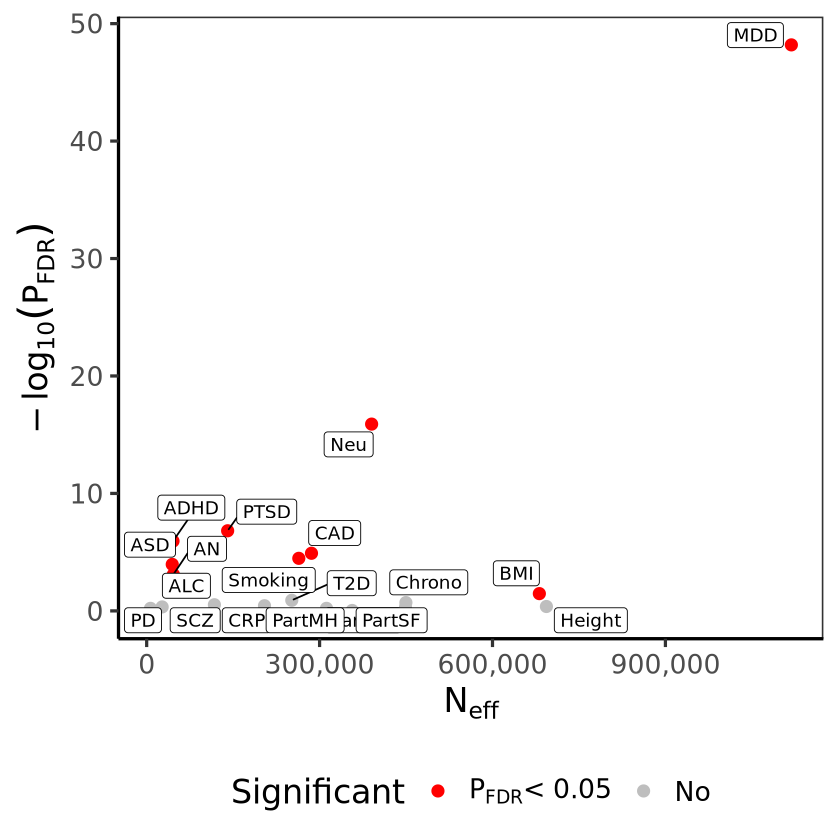

In [292]:
#create a dotplot with -log10(p) on the y axis and neff on the x axis
library(scales)

chisq_diff_plot <- ggplot(model_diff_neff_df, aes(x = Neff, y = -log10(FDR), label = Trait)) +
geom_point(aes(color = Significant), size = 2.5) +
scale_color_manual(values = c("red","grey"), labels = c("FDR < 0.05" = expression(P[FDR]*"< 0.05"))) +
theme_bw(base_size = 20) +
geom_label_repel() +
scale_x_continuous(labels = label_comma()) +
labs(x = expression(N[eff]), y = expression(-log[10](P[FDR]))) + 
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), legend.position = "bottom") 



chisq_diff_plot

In [293]:
ggsave("../plots/bip_paper/chisq_diff_bipolar.pdf", chisq_diff_plot, width = 10, height = 10)

In [299]:
write_csv(model_diff_neff_df, "/local1/home/pazweifel/plots/bip_paper/chisquared_diffs.csv")

In [26]:
semPlotModel_GSEM <- function(gsem.object=cfa_bipolar){ 
        object <- gsem.object$results
        object$free=0
        numb=1:length(which(object$op!="~~"))
        object$free[which(object$op!="~~")]=numb
        varNames <- lavaanNames(object, type = "ov")
        factNames <- lavaanNames(object, type = "lv")
        factNames <- factNames[!factNames %in% varNames]
        n <- length(varNames)
        k <- length(factNames)
        if (is.null(object$label)) 
          object$label <- rep("", nrow(object))
        semModel <- new("semPlotModel")
        object$std <- object[,"STD_Genotype"]
        object$est <- object[,"Unstand_Est"]
        if (is.null(object$group)) 
          object$group <- ""
        semModel@Pars <- data.frame(label = object$label, lhs = ifelse(object$op == "~" | object$op == "~1", object$rhs, object$lhs), edge = "--", 
                                    rhs = ifelse(object$op == "~" | object$op == "~1", object$lhs, object$rhs), est = object$est, std = object$std, std = NA, group = object$group, 
                                    fixed = object$free==0, par = object$free, stringsAsFactors = FALSE)
        semModel@Pars$edge[object$op == "~~"] <- "<->"
        semModel@Pars$edge[object$op == "~*~"] <- "<->"
        semModel@Pars$edge[object$op == "~"] <- "~>"
        semModel@Pars$edge[object$op == "=~"] <- "->"
        semModel@Pars$edge[object$op == "~1"] <- "int"
        semModel@Pars$edge[grepl("\\|", object$op)] <- "|"
        semModel@Thresholds <- semModel@Pars[grepl("\\|", semModel@Pars$edge), 
                                             -(3:4)]
        semModel@Pars <- semModel@Pars[!object$op %in% c(":=", "<", 
                                                         ">", "==", "|", "<", ">"), ]
        semModel@Vars <- data.frame(name = c(varNames, factNames), 
                                    manifest = c(varNames, factNames) %in% varNames, exogenous = NA, 
                                    stringsAsFactors = FALSE)
        semModel@ObsCovs <- list()
        semModel@ImpCovs <- list()
        semModel@Computed <- FALSE
        semModel@Original <- list(object)
        return(semModel)
 }

In [27]:
library(lavaanPlot)
library(lavaan)
library(semPlot)

This is lavaan 0.6-20
lavaan is FREE software! Please report any bugs.



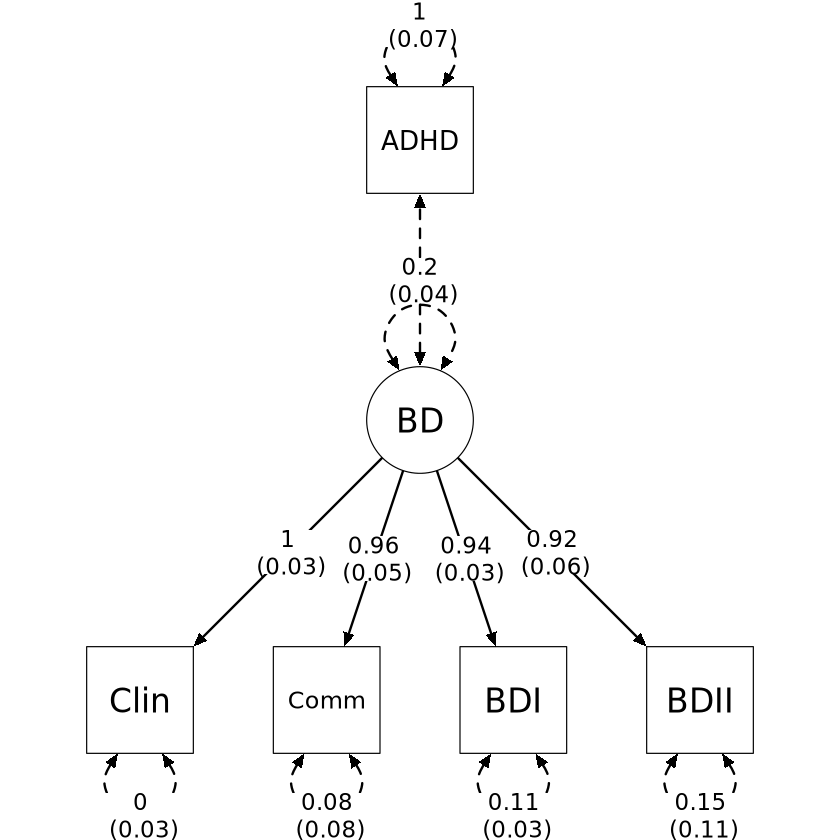

In [28]:
current_fit_common <- semPlotModel_GSEM(gsem.object = trait_common.fit[["ADHD"]])

se <- trait_common.fit[["ADHD"]]$results$STD_Genotype_SE
est <- trait_common.fit[["ADHD"]]$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

semPaths(current_fit_common, layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se[1:(length(est.se)-1)])

In [29]:
for (trait in other_names){
    #define the two sem objects
    current_fit_common <- semPlotModel_GSEM(gsem.object = trait_common.fit[[trait]])
    current_fit_independent <- semPlotModel_GSEM(gsem.object = trait_independent.fit[[trait]])
    #extract the std estimate and the corresponding se to plot them both, for common and independent model
    se <- trait_common.fit[[trait]]$results$STD_Genotype_SE
    est <- trait_common.fit[[trait]]$results$STD_Genotype
    est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

    se_in <- trait_independent.fit[[trait]]$results$STD_Genotype_SE
    est_in <- trait_independent.fit[[trait]]$results$STD_Genotype
    est.se_in <- paste0(round(as.numeric(est_in), 2),"\n (",round(as.numeric(se_in), 2),")")
    #save the common model as an svg object, remove the last label as overlapping and known as factor artificially set to variance of 1
    svg(paste0("/local1/home/pazweifel/plots/bip_paper/",trait,"_common_model.svg"), width = 11, height = 12)
    semPaths(current_fit_common, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se[1:10])
    dev.off()
    #save the indpendent mode as an svg object
    svg(paste0("/local1/home/pazweifel/plots/bip_paper/",trait,"_independent_model.svg"), width = 12, height = 11)
    semPaths(current_fit_independent, whatLabels = "std", layout = "circle", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        rotation = 1,
        esize = 2,
        edgeLabels = est.se_in)
    dev.off()
}

In [30]:
se <- base.fit$results$STD_Genotype_SE
est <- base.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

se_in <- anchor.fit$results$STD_Genotype_SE
est_in <- anchor.fit$results$STD_Genotype
est.se_in <- paste0(round(as.numeric(est_in), 2),"\n (",round(as.numeric(se_in), 2),")")

In [31]:
fit_sem_base <- semPlotModel_GSEM(base.fit)
fit_sem_anchor <- semPlotModel_GSEM(anchor.fit)

agg_record_1343626597 
                    2

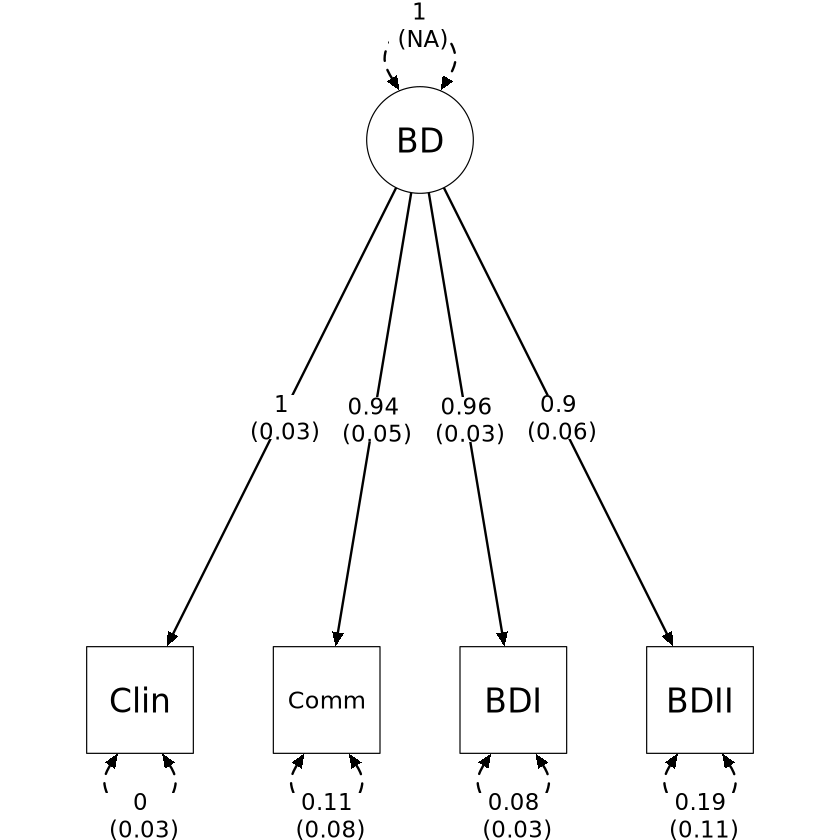

In [32]:
positions <- sapply(c(1:length(est.se)), function(index) {
    if (index%%2==0){
        0.7
    }else {
        0.3}
}
)
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se,
        edge.label.position = 0.5
        )

svg("/local1/home/pazweifel/plots/bip_paper/base_model_wse.svg", width = 10, height = 12)
semPaths(fit_sem_base, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se,
        edge.label.position = 0.5
        )
dev.off()

agg_record_630496343 
                   2

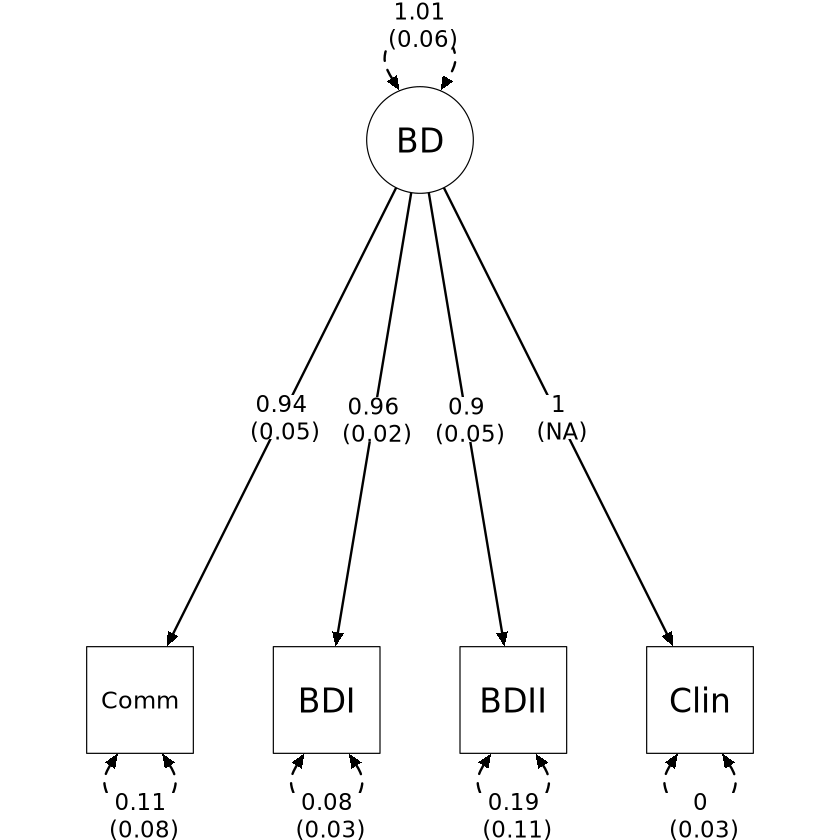

In [33]:
semPaths(fit_sem_anchor, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se_in)

svg("/local1/home/pazweifel/plots/bip_paper/anchor_model_wse.svg", width = 10, height = 12)
semPaths(fit_sem_anchor, whatLabels = "std", layout = "tree", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1.2,
        esize = 2,
        edgeLabels = est.se_in)
dev.off()

## GSEM Qtrait function to calculate 

In [34]:
trait.qtrait <- bind_rows(lapply(traits, function(trait) {
    QTrait(
    LDSCoutput = trait.covstructs[[trait]],
    indicators = sample_names,
    traits = trait)
    }),
    .id = "Trait")


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


corrplot 0.95 loaded




 ---------------------------- 

 Fitting common pathways model for external trait ADHD 
 

 Fitting independent pathways model for external trait ADHD 
 

 Fitting follow-up model for external trait ADHD 
 

 Most egregious outlier: BDII 
 

 ---------------------------- 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait ALC 
 

 Fitting independent pathways model for external trait ALC 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait AN 
 

 Fitting independent pathways model for external trait AN 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait ASD 
 

 Fitting independent pathways model for external trait ASD 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait MDD 
 

 Fitting independent pathways model for external trait MDD

In [35]:
trait.qtrait

,Trait,rGF1Trait_CPM,SErGF1Trait_CPM,pvalrGF1Trait_CPM,rGF1Trait_significat_CPM,QTrait_CPM,df_CPM,p_value_CPM,Qsignificant_CPM,lSRMR_CPM,⋯,pvalrGF1Trait_FUM,rGF1Trait_significat_FUM,QTrait_FUM,df_FUM,p_value_FUM,Qsignificant_FUM,lSRMR_FUM,lSRMR_above_threshold_FUM,heterogeneity_FUM,Unconstrained_paths
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
ADHD,ADHD,0.202076901,0.04166307,1.232970e-06,*,18.9885167,3,2.748977e-04,*,0.12115231,⋯,1.320272e-05,*,15.21187,2,4.974889e-04,*,0.08127240,No,No,BDII
ALC,ALC,0.292159549,0.06810187,1.786431e-05,*,-1.6617702,3,1.000000e+00,NS,0.05879574,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
AN,AN,0.230747823,0.03704739,4.710703e-10,*,8.6361225,3,3.454125e-02,*,0.06242593,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
ASD,ASD,0.206300977,0.04708236,1.177543e-05,*,12.5701770,3,5.664633e-03,*,0.09544419,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
MDD,MDD,0.497737963,0.03098105,4.424979e-58,*,68.5884028,3,8.560160e-15,*,0.17351999,⋯,6.411675e-54,*,28.03468,2,8.172344e-07,*,0.11985304,No,No,BDII
BMI,BMI,-0.022124074,0.02358510,3.482172e-01,NS,11.3706979,3,9.881316e-03,*,0.04005225,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
CAD,CAD,0.029874587,0.02515406,2.349656e-01,NS,27.6729631,3,4.253832e-06,*,0.08586107,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
Chrono,Chrono,-0.043299071,0.02654000,1.027923e-01,NS,5.8262381,3,1.203770e-01,NS,0.03081890,⋯,NA,-,NA,NA,NA,-,NA,-,-,None
CRP,CRP,-0.003599079,0.03718641,9.228973e-01,NS,4.3214501,3,2.287802e-01,NS,0.01945448,⋯,NA,-,NA,NA,NA,-,NA,-,-,None


## Visualization of Correlations for different models

In [36]:
cov2cor(trait_common.fit[["ADHD"]]$resid_cov$'Model Implied Covariance Matrix')[1:4, 5]

Clin      Comm       BDI      BDII 
0.2039802 0.1953909 0.1922639 0.1879393

In [37]:
#first extract the model implied covariances from the common model fit and convert to correlations
target_common_rg <- bind_rows(
    lapply(trait_common.fit, function(fit) {
        cov2cor(V = fit$resid_cov$'Model Implied Covariance Matrix')[1:4, 5]
        }
    ),
    .id = "trait")
    

In [38]:
#add the common pathway label and make the df longer so that you have one correlation per line to plot afterwards
target_common_rg <- target_common_rg %>% mutate(Pathway = "Common") %>% pivot_longer(Clin:BDII, names_to = "BD", values_to = "rg")

In [39]:
trait_independent.fit[[1]]$results

,lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
4,BD,=~,Clin,0.437206357,0.0132658253143622,1.00359974,0.0304448933603626,1.00359974,3.320431e-238
5,BD,=~,Comm,0.222514312,0.0107023097937672,0.94063944,0.0452426345881756,0.94063941,5.194888e-96
2,BD,=~,BDI,0.348132312,0.0108858344640841,0.96206236,0.0300836339338127,0.96206234,2.048697e-224
3,BD,=~,BDII,0.259810616,0.0161806059217895,0.90257696,0.0562116422593698,0.90257698,5.113588e-58
11,Clin,~~,ADHD,0.028083811,0.00852283706053562,0.15274392,0.0463545334909582,15.27439063,9.837801e-04
13,Comm,~~,ADHD,0.031396854,0.00571468569430946,0.31453511,0.0572500115831014,0.92671794,3.927859e-08
7,BDI,~~,ADHD,0.016756644,0.00672368755649638,0.10973954,0.0440335227056426,0.40222721,1.269614e-02
9,BDII,~~,ADHD,0.044412536,0.00909563695387841,0.36563032,0.0748806530547586,0.84925925,1.045690e-06
12,Clin,~~,Clin,0.000100000,0.00597540145506745,0.00010000,0.031481403956938,0.00010000,9.866478e-01


In [40]:
#now extract correlation of external phenotype with common factor form results table (BD~~E)
target_common_factor_rg <- bind_rows(
    lapply(trait_common.fit, function(fit){
        fit$results %>%
        filter(
            lhs == "BD",
            rhs != "BD",
            !rhs %in% bip_names
            ) %>%
        transmute(BD = "BD", rg = STD_Genotype, se = as.numeric(STD_Genotype_SE)
                  )
        }
    ),
    .id = "trait"
    ) %>%
    mutate(Pathway = "Common")

In [41]:
#now the same for the independent model, extract from model-implied covariance matrix
target_independent_rg <- bind_rows(
    lapply(
        trait_independent.fit, function(fit){
            cov2cor(fit$resid_cov$'Model Implied Covariance Matrix')[1:4, 5]
            }),
    .id = "trait"
    ) %>% mutate(Pathway = "Independent") %>% pivot_longer(Clin:BDII, names_to = "BD", values_to = "rg")

In [42]:
#for the independent model extract the correlation between factor and external trait form results
target_independent_rg_se <- bind_rows(
    lapply(trait_independent.fit, function(fit){
        fit$results %>% filter(
            lhs %in% bip_names,
            lhs != rhs
            ) %>% transmute(
            BD = lhs, rg = STD_Genotype, se = as.numeric(STD_Genotype_SE))
        }),
        .id = "trait"
    ) %>% mutate(
    Pathway = "Independent")
        

In [43]:
#extract the observed correlation and se
test <- trait.covstructs[["MDD"]]
S <- test$S_Stand
V <- test$V_Stand
rgs <- S[5, 1:4]
print(rgs)
names <- dimnames(S)[[2]][1:4]
print(names)
se_index <- c(5,9,12,14)
ses <- sapply(se_index, function(index) V[index, index])
print(ses)
tibble(BD = names, rg = rgs, se = ses)
#basically the same as the ones form the independent model, so not necessary

     Clin      Comm       BDI      BDII 
0.4099858 0.6404221 0.3655342 0.7136547 
[1] "Clin" "Comm" "BDI"  "BDII"
[1] 0.001451138 0.001621332 0.001058146 0.003057429


BD,rg,se
<chr>,<dbl>,<dbl>
Clin,0.4099858,0.001451138
Comm,0.6404221,0.001621332
BDI,0.3655342,0.001058146
BDII,0.7136547,0.003057429


In [44]:
#extract the heritabilities and their se
#for the base phenotypes
temp <- covstruct_base
S <- temp$S
V <- temp$V
herit_base <- sapply(c(1:4), function(index) S[index,index])
                  
index_se <- c(1, 5, 8, 10)
se_base <- sapply(index_se, function(index) sqrt(V[index, index]))
           
names <- dimnames(S)[[2]][1:4]
                
base_heritabilities <- tibble(trait = names, heritability = herit_base, se = se_base, group = "internal")

In [45]:
ext_heritabilities <- bind_rows(
                            lapply(traits, function(trait) {
                                temp <- trait.covstructs[[trait]]
                                heritability <- temp$S[5,5]
                                se <- sqrt(temp$V[15,15])
                                tibble(heritability = heritability, se = se, group = "external")
                                }),
                                .id = "trait")
                                

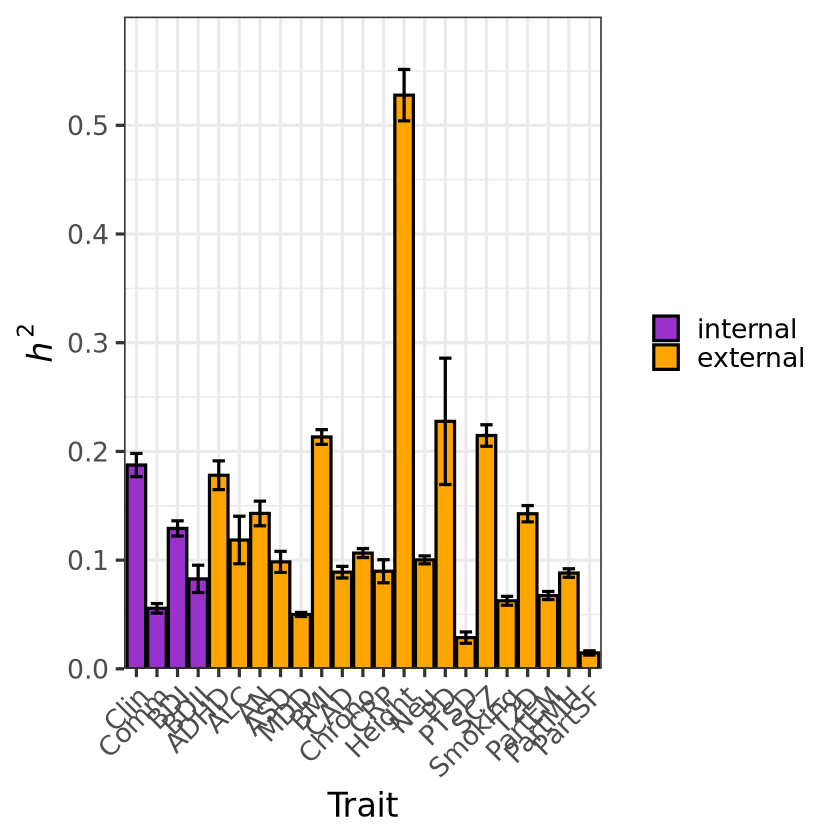

In [300]:
all_heritabilities <- bind_rows(base_heritabilities, ext_heritabilities)
all_heritabilities$trait <- factor(all_heritabilities$trait, levels = unique(all_heritabilities$trait))
all_heritabilities$group <- factor(all_heritabilities$group, levels = c("internal", "external"))

heritabilities_bip_paper <- ggplot(all_heritabilities, aes(x = trait, y = heritability, fill = group)) + 
geom_col(color = "black") +
theme_bw(base_size = 20) +
geom_errorbar(aes(ymin = heritability - se, ymax = heritability + se), width = 0.6) +
theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.title = element_blank()) +
labs(x = "Trait", y = expression(italic(h^2))) +
scale_y_continuous(limits = c(0, 0.6), expand = c(0,0)) +
scale_fill_manual(values = c("darkorchid", "orange"))

heritabilities_bip_paper

In [301]:
ggsave("/local1/home/pazweifel/plots/bip_paper/heritabilities_all.pdf", heritabilities_bip_paper, device = pdf, width = 22, height = 10)

In [302]:
write_csv(all_heritabilities, "/local1/home/pazweifel/plots/bip_paper/heritabilities.csv")

In [48]:

target_sample_sizes <-
  bind_rows(
    lapply(trait.covstructs, function(covs) {
      # get sample sizes
      N <- covs$N
      # create a matrix the same size as the cov matrix
      Nmat <- covs$S
      # fill in lower triangle
      Nmat[TRUE] <- NA
      Nmat[lower.tri(Nmat, diag = TRUE)] <- N
      # extract sample size and names from matrix
      Ns <- Nmat[5, 1:4]
      N_names <- dimnames(Nmat)[[2]][1:4]
      # add total N for factor
      N_total <- sum(Ns)
      tibble(N = c(Ns, N_total), BD = c(N_names, "BD"))
    }),
    .id = "trait"
  )

In [49]:
target_sample_sizes

trait,N,BD
<chr>,<dbl>,<chr>
ADHD,54993.97,Clin
ADHD,73499.73,Comm
ADHD,65080.40,BDI
ADHD,34213.33,BDII
ADHD,227787.43,BD
ALC,40928.60,Clin
ALC,54648.17,Comm
ALC,48216.63,BDI
ALC,25368.67,BDII


In [50]:
target_rg <- bind_rows(
    target_common_rg, 
    target_common_factor_rg, 
    target_independent_rg_se) %>% left_join(
    target_sample_sizes,
    by = c("trait", "BD")) %>% left_join(
    model_diff_neff_df, by = c("trait" = "Trait"))

In [51]:
correlation_table <- target_rg |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)) %>% select(-c(Nca, Nco, Neff, Significant))
write_csv(x = correlation_table, file = "/local1/home/pazweifel/plots/bip_paper/correlations_table.csv")

In [52]:
target_rg_noheight <- filter(target_rg, trait!= "Height")

In [53]:
mdd_correlations <- read_delim("/local1/scratch/pazweifel/sumstats_ambits/correlations_md.csv", delim = ";")

Rows: 162 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ";"
chr (3): trait, Pathway, MDD
dbl (7): rg, se, N, q_chisq, q_df, q_p, FDR

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [54]:
head(mdd_correlations)
head(target_rg)

trait,Pathway,MDD,rg,se,N,q_chisq,q_df,q_p,FDR
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ADHD,Common,Clin,0.4400081,NA,53107.75,32.809741,3,0.000000353,0.00000159
ADHD,Common,EHR,0.4623858,NA,194999.36,32.809741,3,0.000000353,0.00000159
ADHD,Common,Quest,0.4519537,NA,100196.01,32.809741,3,0.000000353,0.00000159
ADHD,Common,Help,0.4502057,NA,115284.80,32.809741,3,0.000000353,0.00000159
ALC,Common,Clin,0.5061170,NA,39373.65,2.761436,3,0.429887612,0.48362356
ALC,Common,EHR,0.5162056,NA,143753.17,2.761436,3,0.429887612,0.48362356


trait,Pathway,BD,rg,se,N,q_chisq,q_df,q_p,FDR,Nca,Nco,Neff,Significant
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ADHD,Common,Clin,0.2039802,NA,54993.97,33.594530,3,2.412732e-07,1.146048e-06,19099,34194,45684.86,FDR < 0.05
ADHD,Common,Comm,0.1953909,NA,73499.73,33.594530,3,2.412732e-07,1.146048e-06,19099,34194,45684.86,FDR < 0.05
ADHD,Common,BDI,0.1922639,NA,65080.40,33.594530,3,2.412732e-07,1.146048e-06,19099,34194,45684.86,FDR < 0.05
ADHD,Common,BDII,0.1879393,NA,34213.33,33.594530,3,2.412732e-07,1.146048e-06,19099,34194,45684.86,FDR < 0.05
ALC,Common,Clin,0.2922725,NA,40928.60,3.186253,3,3.637905e-01,4.608013e-01,NA,NA,26853.43,No
ALC,Common,Comm,0.2764568,NA,54648.17,3.186253,3,3.637905e-01,4.608013e-01,NA,NA,26853.43,No


In [55]:
mdd_correlations_adjusted <- mdd_correlations %>% mutate(Variable = MDD, Analysis = "MDD") %>% select(-MDD)
bd_correlations_adjusted <- target_rg %>% mutate(Variable = BD, Analysis = "BD") %>% select(-c(BD, Nca, Nco, Neff, Significant))

In [56]:
combined_rgs <- bind_rows(mdd_correlations_adjusted, bd_correlations_adjusted)
head(combined_rgs)

trait,Pathway,rg,se,N,q_chisq,q_df,q_p,FDR,Variable,Analysis
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ADHD,Common,0.4400081,NA,53107.75,32.809741,3,0.000000353,0.00000159,Clin,MDD
ADHD,Common,0.4623858,NA,194999.36,32.809741,3,0.000000353,0.00000159,EHR,MDD
ADHD,Common,0.4519537,NA,100196.01,32.809741,3,0.000000353,0.00000159,Quest,MDD
ADHD,Common,0.4502057,NA,115284.80,32.809741,3,0.000000353,0.00000159,Help,MDD
ALC,Common,0.5061170,NA,39373.65,2.761436,3,0.429887612,0.48362356,Clin,MDD
ALC,Common,0.5162056,NA,143753.17,2.761436,3,0.429887612,0.48362356,EHR,MDD


In [ ]:
correlation_plot_thes <- ggplot(
  target_rg |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)),
  aes(
    x = BD, y = rg,
    ymin = rg + se * qnorm(0.025), ymax = rg + se * qnorm(0.975),
    shape = Pathway, colour = Pathway, size = N
  )
) +
  geom_linerange(aes(ymin = rg + se * qnorm(0.1), ymax = rg + se * qnorm(0.9)), linewidth = 0.75) +
  geom_pointrange() +
  facet_grid(rows = vars(trait)) +
  scale_x_discrete("BD phenotype", limits = c("BD", rev(bip_names))) +
  scale_y_continuous(expression(r[g]), breaks = c(-0.25, 0, 0.25, 0.5, 0.75, 1)) +
  scale_size_area(breaks = c(2.5e4, 5e4, 1e5, 2.5e5, 5e5), max_size = 1) +
  scale_colour_discrete(
    type = c(
      microshades_cvd_palettes$micro_cvd_blue[4],
      microshades_cvd_palettes$micro_cvd_orange[2]
    )
  ) +
  coord_flip(ylim = c(-0.25, 1)) +
  theme_minimal(base_size = 30) +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_line(linewidth = 0.1), legend.position = "bottom")
correlation_plot_thes

In [304]:
ggsave("/local1/home/pazweifel/plots/bip_paper/correlation_plot_use.pdf", plot = correlation_plot_thes, device = "pdf", height = 30, width = 25)

Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale r

In [57]:
correlation_plot_bd <- ggplot(
  target_rg_noheight |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)),
  aes(
    x = BD, y = rg,
    ymin = rg + se * qnorm(0.025), ymax = rg + se * qnorm(0.975),
    shape = Pathway, colour = Pathway, size = N
  )
) +
  geom_linerange(aes(ymin = rg + se * qnorm(0.1), ymax = rg + se * qnorm(0.9)), linewidth = 0.75) +
  geom_pointrange() +
  facet_grid(rows = vars(trait)) +
  scale_x_discrete("BD phenotype", limits = c("BD", rev(bip_names))) +
  scale_y_continuous(expression(r[g]), breaks = c(-0.25, 0, 0.25, 0.5, 0.75, 1)) +
  scale_size_area(breaks = c(2.5e4, 5e4, 1e5, 2.5e5, 5e5), max_size = 1) +
  scale_colour_discrete(
    type = c(
      microshades_cvd_palettes$micro_cvd_blue[4],
      microshades_cvd_palettes$micro_cvd_orange[2]
    )
  ) +
  coord_flip(ylim = c(-0.25, 1)) +
  theme_minimal(base_size = 30) +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_line(linewidth = 0.1))

In [58]:
correlation_plot_md <- ggplot(
  mdd_correlations |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)),
  aes(
    x = MDD, y = rg,
    ymin = rg + se * qnorm(0.025), ymax = rg + se * qnorm(0.975),
    shape = Pathway, colour = Pathway, size = N
  )
) +
  geom_linerange(aes(ymin = rg + se * qnorm(0.1), ymax = rg + se * qnorm(0.9)), linewidth = 0.75) +
  geom_pointrange() +
  facet_grid(rows = vars(trait)) +
  scale_x_discrete("MD phenotype", limits = c("MD", "Help", "Quest", "EHR", "Clin")) +
  scale_y_continuous(expression(r[g]), breaks = c(-0.25, 0, 0.25, 0.5, 0.75, 1)) +
  scale_size_area(breaks = c(2.5e4, 5e4, 1e5, 2.5e5, 5e5), max_size = 1) +
  scale_colour_discrete(
    type = c(
      microshades_cvd_palettes$micro_cvd_blue[4],
      microshades_cvd_palettes$micro_cvd_orange[2]
    )
  ) +
  coord_flip(ylim = c(-0.25, 1)) +
  theme_minimal(base_size = 30) +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_line(linewidth = 0.1))

In [59]:
correlation_plot_md_legendbottom <- correlation_plot_md + theme(legend.position = "bottom")

In [60]:
unique(mdd_correlations$MDD)

[1] "Clin"  "EHR"   "Quest" "Help"  "MD"

In [61]:
library(cowplot)

In [62]:
shared_legend <- get_legend(correlation_plot_md)
shared_legend_bottom <- get_legend(correlation_plot_md_legendbottom)

Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale r

In [63]:
md_wo_legend <- correlation_plot_md + theme(legend.position = "None")
bd_wo_legend <- correlation_plot_bd + theme(legend.position = "None")

In [64]:
correlation_plots <- plot_grid(plotlist = c(md_wo_legend, bd_wo_legend), ncol = 2)

Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale r

In [65]:
correlation_plots_wlegend <- plot_grid(correlation_plots, shared_legend, ncol = 2, rel_widths = c(1, 0.25))
correlation_plots_wlegendbottom <- plot_grid(correlation_plots, shared_legend_bottom, nrow = 2, rel_heights = c(1, 0.05))

In [66]:
ggsave("/local1/home/pazweifel/plots/bip_paper/combined_correlation_plot.pdf", plot = correlation_plots_wlegend, device = "pdf", height = 30, width = 25)

In [67]:
ggsave("/local1/home/pazweifel/plots/bip_paper/combined_correlation_plot_legendbottom.pdf", plot = correlation_plots_wlegendbottom, device = "pdf", height = 35, width = 25)

In [68]:
correlation_plot_combined <- ggplot(
  combined_rgs |> arrange(desc(Pathway)) |> mutate(trait = reorder(trait, 1 - rg)),
  aes(
    x = Variable, y = rg,
    ymin = rg + se * qnorm(0.025), ymax = rg + se * qnorm(0.975),
    shape = Pathway, colour = Pathway, size = N
  )
) +
  geom_linerange(aes(ymin = rg + se * qnorm(0.1), ymax = rg + se * qnorm(0.9)), linewidth = 0.75) +
  geom_pointrange() +
  facet_grid(rows = vars(trait), cols = vars(Analysis)) +
  #scale_x_discrete("Phenotype", limits = c("BD", rev(bip_names))) +
  scale_y_continuous(expression(r[g]), breaks = c(-0.25, 0, 0.25, 0.5, 0.75, 1)) +
  scale_size_area(breaks = c(2.5e4, 5e4, 1e5, 2.5e5, 5e5), max_size = 1) +
  scale_colour_discrete(
    type = c(
      microshades_cvd_palettes$micro_cvd_blue[4],
      microshades_cvd_palettes$micro_cvd_orange[2]
    )
  ) +
  coord_flip(ylim = c(-0.25, 1)) +
  theme_minimal() +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_line(linewidth = 0.1))

In [69]:
ggsave("/local1/home/pazweifel/plots/bip_paper/Correlation_comparison.svg", plot = correlation_plot, width = 10, height = 20, device = "svg") 

In [70]:
target_rg |>
    pivot_wider(names_from = c("Pathway"), values_from = c("rg", "se")) |>
    mutate(rgD = rg_Independent - rg_Common) |>
    select(-se_Common) |>
    arrange(desc(abs(rgD))) |>
    filter(abs(rgD) > se_Independent) |> select(-c(Nca, Nco, Neff, Significant))


trait,BD,N,q_chisq,q_df,q_p,FDR,rg_Common,rg_Independent,se_Independent,rgD
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PTSD,BDII,60260.27,38.347699,3,2.385749e-08,1.510975e-07,0.40344076,0.61339222,0.11224993,0.20995146
PTSD,Comm,129426.61,38.347699,3,2.385749e-08,1.510975e-07,0.42186297,0.62691902,0.08279525,0.20505605
MDD,BDII,168834.20,232.817703,3,3.400790e-50,6.461501e-49,0.51700700,0.70774899,0.05510272,0.19074199
Neu,BDII,99700.29,81.711717,3,1.317738e-17,1.251851e-16,0.21660642,0.40350847,0.04996462,0.18690206
ADHD,BDII,34213.33,33.594530,3,2.412732e-07,1.146048e-06,0.18793926,0.36563032,0.07488065,0.17769106
CAD,BDII,86023.28,28.212475,3,3.277536e-06,1.245464e-05,0.02739771,0.17808355,0.04583352,0.15068584
Smoking,BDII,82310.30,25.781242,3,1.059805e-05,3.356048e-05,0.08927681,0.23958250,0.05988936,0.15030569
ASD,BDII,33915.27,22.991499,3,4.054811e-05,1.100591e-04,0.19020631,0.33268754,0.08209246,0.14248123
ADHD,Comm,73499.73,33.594530,3,2.412732e-07,1.146048e-06,0.19539090,0.31453511,0.05725001,0.11914421


## Follow-up models: Removing external ~ internal trait regressions one by one to compare model fit

In [71]:
rg_ordered_grouped_df <- target_rg %>% filter(Pathway == "Independent") %>% group_by(trait) %>% arrange(-rg, .by_group = TRUE) %>% subset(select = c(trait, BD, rg))

In [72]:
rg_ordered_grouped_df

trait,BD,rg
<chr>,<chr>,<dbl>
ADHD,BDII,0.3656303240
ADHD,Comm,0.3145351092
ADHD,Clin,0.1527439157
ADHD,BDI,0.1097395380
ALC,BDII,0.3632316703
ALC,Comm,0.3220726101
ALC,Clin,0.2595765817
ALC,BDI,0.2539919582
AN,Comm,0.3033102923


In [73]:
vec <- filter(rg_ordered_grouped_df, trait == "ADHD") %>% .$BD %>% .[1:(4-1)]

In [74]:
dynamic_model_1 <- "BD=~NA*Clin+Comm+BDI+BDII
{external_trait}~~{trait1}
{external_trait}~~{trait2}
{external_trait}~~{trait3}
"

dynamic_model_2 <- "BD~~1*BD
Clin~~a*Clin
a>0.0001
"

paste0(dynamic_model_1,dynamic_model_2)
dynamic_model_1
substr(dynamic_model_1, 1, nchar(dynamic_model_1))

[1] "BD=~NA*Clin+Comm+BDI+BDII\n{external_trait}~~{trait1}\n{external_trait}~~{trait2}\n{external_trait}~~{trait3}\nBD~~1*BD\nClin~~a*Clin\na>0.0001\n"

[1] "BD=~NA*Clin+Comm+BDI+BDII\n{external_trait}~~{trait1}\n{external_trait}~~{trait2}\n{external_trait}~~{trait3}\n"

[1] "BD=~NA*Clin+Comm+BDI+BDII\n{external_trait}~~{trait1}\n{external_trait}~~{trait2}\n{external_trait}~~{trait3}\n"

In [75]:
sub <- nchar("{external_trait}~~{traitx}\n")
a <- substr(dynamic_model_1, 1, nchar(dynamic_model_1) - 2 * sub)

paste0(a,dynamic_model_2)
#trait 1 the one with the highest loading 

[1] "BD=~NA*Clin+Comm+BDI+BDII\n{external_trait}~~{trait1}\nBD~~1*BD\nClin~~a*Clin\na>0.0001\n"

In [76]:
#lsit where i want to store the different follow up models with stepwise retracted traits
fitlist <- list(follow_up_1 = 0, follow_up_2 = 0, follow_up_3 = 0)

In [ ]:
#list where i want to store the different follow up models with stepwise retracted traits
fitlist <- list(follow_up_1 = 0, follow_up_2 = 0, follow_up_3 = 0)

dynamic_model_1 <- "BD=~NA*Clin+Comm+BDI+BDII
BD~~1*BD
{trait1}~~{external_trait}
{trait2}~~{external_trait}
{trait3}~~{external_trait}
"

dynamic_model_2 <- "Clin~~a*Clin
a>0.0001
"

sub <- nchar("{external_trait}~~{traitx}\n")


for (index in 1:3){
    temp.fit <- lapply(traits, function(external_trait){
        #extract the internal traits ordered by rg; depending on index remove the one with the lowest correlation and store them in a vector
        trait_vector <- filter(rg_ordered_grouped_df, trait == external_trait) %>% .$BD %>% .[1:(4-index)]
        #assign values form vector to trait variables which match the placeholders in the dynamic model, if out of range jsut gets NA so no problem
        trait1 <- trait_vector[1]
        trait2 <- trait_vector[2]
        trait3 <- trait_vector[3]
        #adjust the model
        temp_model <- substr(dynamic_model_1, 1, nchar(dynamic_model_1) - (index -1) * sub)
        print(temp_model)
        #paste the traits into the model structure
        temp_model <- str_glue(temp_model)
        temp_model_2 <- str_glue(dynamic_model_2)
        print(temp_model)
        temp_model <- paste(temp_model, temp_model_2, sep = "\n")
        print(temp_model)
        usermodel(
                trait.covstructs[[external_trait]],
                estimation = "DWLS",
                model = temp_model,
                imp_cov = TRUE
                )
            }
        )
    fitlist[[index]] <- temp.fit
}


In [78]:
fitlist$follow_up_3[["ADHD"]]

$modelfit
      chisq df      p_chisq      AIC       CFI       SRMR
df 70.10763  5 9.732756e-14 90.10763 0.9860352 0.09643946

$results
    lhs op  rhs Unstand_Est          Unstand_SE STD_Genotype    STD_Genotype_SE
4    BD =~ Clin 0.437206427  0.0132658250618417   1.00360005 0.0304448908660073
5    BD =~ Comm 0.222514327  0.0107023101708411   0.94063979 0.0452426344801601
2    BD =~  BDI 0.348132223  0.0108858352300849   0.96206182 0.0300836367082226
3    BD =~ BDII 0.259810591    0.01618060647662   0.90257727 0.0562116382446886
8  BDII ~~ ADHD 0.044412495 0.00909563695387841   0.36562945 0.0748806530547586
10 Clin ~~ Clin 0.000100000 0.00597540286491271   0.00010000  0.031481415907819
11 Comm ~~ Comm 0.006441317  0.0043613800369478   0.11519687 0.0779407375725696
7   BDI ~~  BDI 0.009735795 0.00415978342989485   0.07443631 0.0317674364230422
9  BDII ~~ BDII 0.015354541 0.00890456374658403   0.18535411  0.107470346266735
1  ADHD ~~ ADHD 0.178075081   0.013230516765863   0.99999977 0.0742974413321286
6    BD ~~   BD 1.000000000                       1.00000000                   
      STD_All       p_value
4  1.00360005 3.319786e-238
5  0.94063975  5.194817e-96
2  0.96206218 2.049380e-224
3  0.90257734  5.113759e-58
8  0.84925888  1.045714e-06
10 0.00010000  9.866478e-01
11 0.11519686  1.397028e-01
7  0.07443637  1.926015e-02
9  0.18535414  8.464556e-02
1  0.99999977  2.710355e-41
6  1.00000000            NA

$resid_cov
$resid_cov$`Model Implied Covariance Matrix`
           Clin       Comm        BDI       BDII       ADHD
Clin 0.19124946 0.09728469 0.15220565 0.11359086 0.00000000
Comm 0.09728469 0.05595394 0.07746441 0.05781158 0.00000000
BDI  0.15220565 0.07746441 0.13093184 0.09044844 0.00000000
BDII 0.11359086 0.05781158 0.09044844 0.08285608 0.04441249
ADHD 0.00000000 0.00000000 0.00000000 0.04441249 0.17807508

$resid_cov$`Residual Covariance Matrix: Calculated as Observed Cov - Model Implied Cov`
              Clin          Comm           BDI          BDII          ADHD
Clin -0.0014124027 -8.618258e-04  4.157271e-03 -1.434176e-03  2.808381e-02
Comm -0.0008618258 -1.339902e-08 -1.214521e-03  3.912618e-03  3.139685e-02
BDI   0.0041572715 -1.214521e-03 -9.941478e-09 -2.848413e-03  1.675664e-02
BDII -0.0014341763  3.912618e-03 -2.848413e-03 -7.001021e-08  4.095022e-08
ADHD  0.0280838092  3.139685e-02  1.675664e-02  4.095022e-08 -8.250070e-08

In [79]:
for (i in fitlist){
    #tempsem <- semPlotModel_GSEM(i[["Neu"]])
      #semPaths(tempsem, whatLabels = "std", layout = "circle", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        #edge.label.cex = 1.2,
        #rotation = 1,
        #esize = 2,
        #edge.label.position = 0.7)
    print(i[["Neu"]]$modelfit)
    
    }
print(trait_common.fit[["Neu"]]$modelfit)    
print(trait_independent.fit[["Neu"]]$modelfit)  

      chisq df      p_chisq      AIC       CFI       SRMR
df 94.02752  3 2.987438e-20 118.0275 0.9803973 0.04037377
      chisq df      p_chisq      AIC       CFI       SRMR
df 63.69451  4 4.846323e-13 85.69451 0.9871448 0.05954689
      chisq df      p_chisq      AIC       CFI       SRMR
df 134.3788  5 2.798937e-27 154.3788 0.9721383 0.09894553
      chisq df      p_chisq      AIC       CFI       SRMR
df 89.01976  5 1.079457e-17 109.0198 0.9819064 0.06439347
      chisq df    p_chisq      AIC       CFI       SRMR
df 7.308041  2 0.02588684 33.30804 0.9988569 0.01862026


In [80]:
a <- fitlist[[1]][["Neu"]]$modelfit
a$version <- 1
a

,chisq,df,p_chisq,AIC,CFI,SRMR,version
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df,94.02752,3,2.987438e-20,118.0275,0.9803973,0.04037377,1


In [81]:
independent_modelfit <- bind_rows(lapply(traits, function(trait) {
    trait_independent.fit[[trait]]$modelfit %>% mutate(version = "independent")
    }),
    .id = "trait")
            
common_modelfit <- bind_rows(lapply(traits, function(trait) {
    trait_common.fit[[trait]]$modelfit %>% mutate(version = "common")
    }),
    .id = "trait")


In [82]:
modelfit_list <- list(0,0,0)
for (i in 1:3){
    temp.modelfit <- bind_rows(
        lapply(traits, function(trait) {
            temp <- fitlist[[i]][[trait]]$modelfit
            #print(temp)
            temp$version <- as.character(i)
            #print(temp)
            temp}),
        .id = "trait")
    modelfit_list[[i]] <- temp.modelfit
    }
all_modelfits <- bind_rows(modelfit_list, independent_modelfit, common_modelfit)



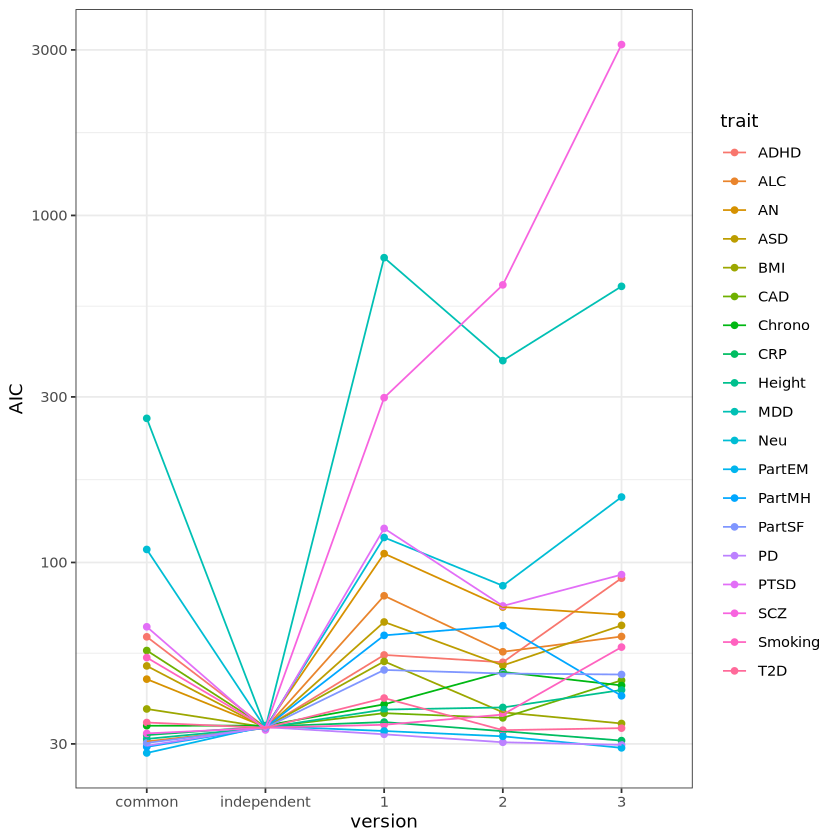

In [83]:
all_modelfits$version <- factor(all_modelfits$version, levels = c("common", "independent", "1", "2", "3"))

ggplot(all_modelfits, aes(x = version, y = AIC, fill = trait, group = trait, color = trait)) +
geom_point() + theme_bw() + scale_y_log10() + geom_line()

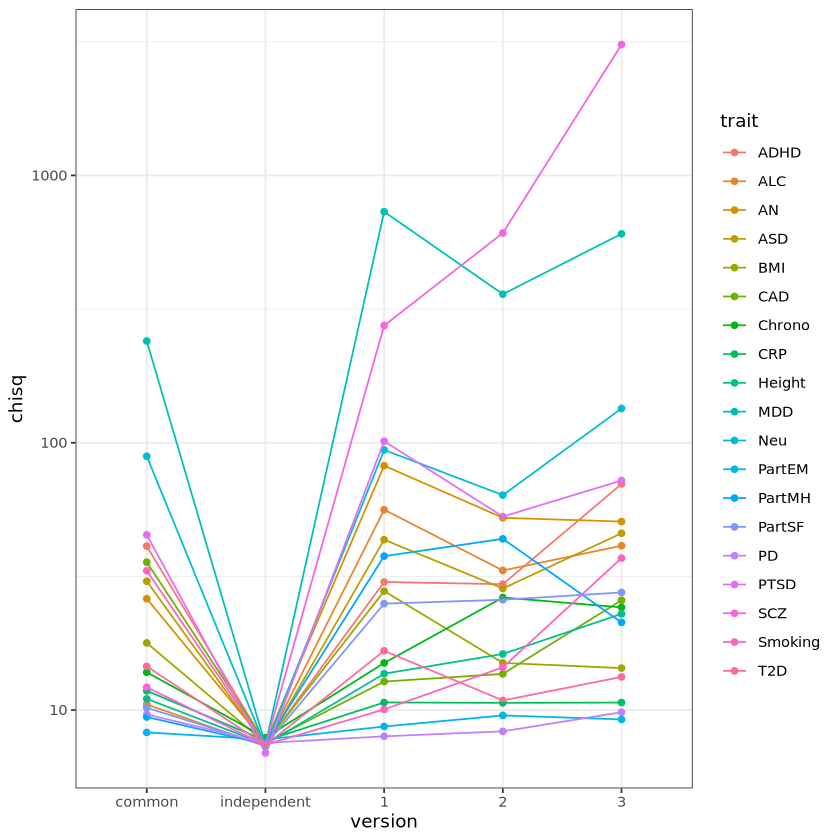

In [84]:
ggplot(all_modelfits, aes(x = version, y = chisq, fill = trait, group = trait, color = trait)) +
geom_point() + theme_bw() + scale_y_log10() + geom_line()

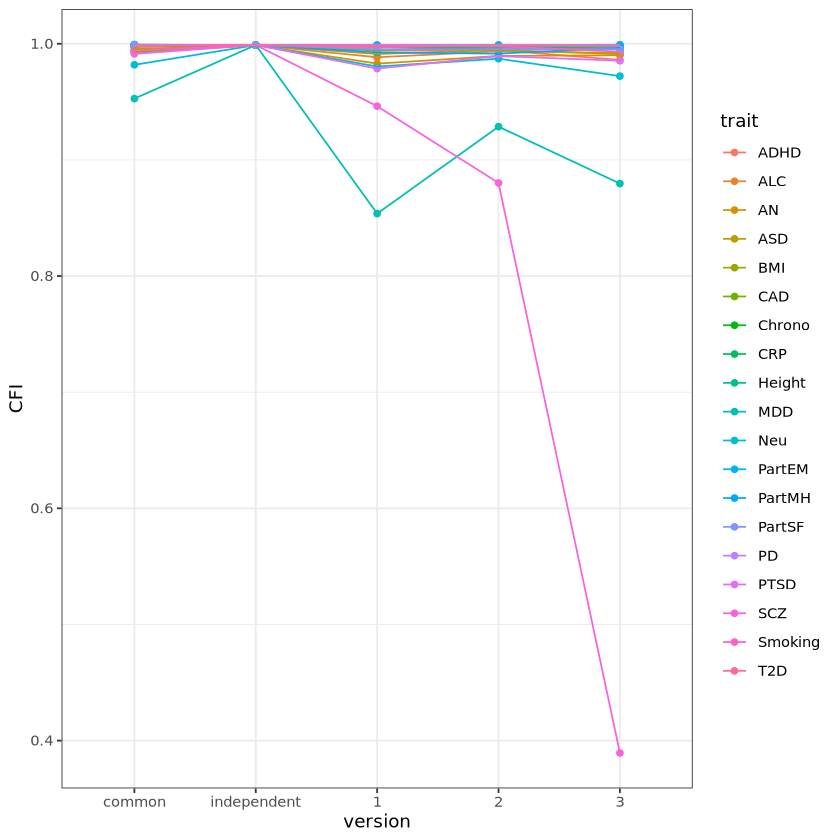

In [85]:
ggplot(all_modelfits, aes(x = version, y = CFI, fill = trait, group = trait, color = trait)) +
geom_point() + theme_bw() + geom_line()

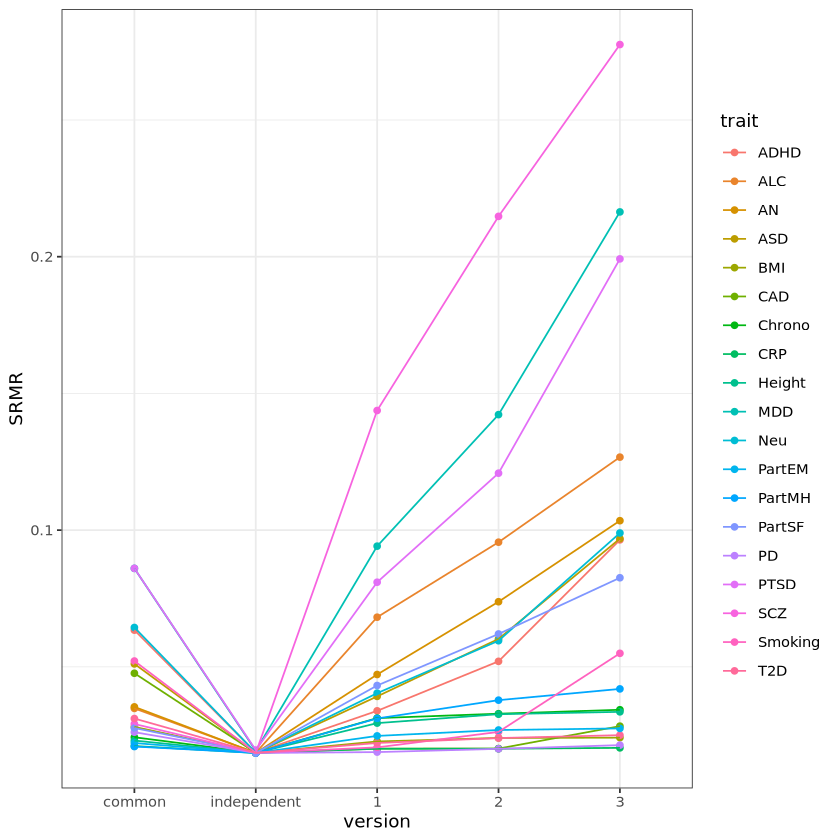

In [86]:
ggplot(all_modelfits, aes(x = version, y = SRMR, fill = trait, group = trait, color = trait)) +
geom_point() + theme_bw() + geom_line()

In [87]:
colnames(trait.qtrait)

[1] "Trait"                     "rGF1Trait_CPM"            
 [3] "SErGF1Trait_CPM"           "pvalrGF1Trait_CPM"        
 [5] "rGF1Trait_significat_CPM"  "QTrait_CPM"               
 [7] "df_CPM"                    "p_value_CPM"              
 [9] "Qsignificant_CPM"          "lSRMR_CPM"                
[11] "lSRMR_above_threshold_CPM" "heterogeneity_CPM"        
[13] "rGF1Trait_FUM"             "SErGF1Trait_FUM"          
[15] "pvalrGF1Trait_FUM"         "rGF1Trait_significat_FUM" 
[17] "QTrait_FUM"                "df_FUM"                   
[19] "p_value_FUM"               "Qsignificant_FUM"         
[21] "lSRMR_FUM"                 "lSRMR_above_threshold_FUM"
[23] "heterogeneity_FUM"         "Unconstrained_paths"

## Grotzinger QTRAIT and follow-up model

In [88]:
their_follow_up_model <- "BD=~NA*Clin+Comm+BDI+BDII
BD~~1*BD
Clin~~a*Clin
a > 0.0001
BD~~{trait}
BDII ~ b*{trait}
"

In [89]:
#extracting the relevant traits
follow_up_names <- trait.qtrait[trait.qtrait$Unconstrained_paths != "None",]$Trait
traits[follow_up_names]

ADHD    MDD    Neu 
"ADHD"  "MDD"  "Neu"

In [90]:
their_follow_up_models.fit <- lapply(traits[follow_up_names], function(trait) {
                                usermodel(covstruc = trait.covstructs[[trait]],
                                          estimation = "DWLS",
                                          model = str_glue(their_follow_up_model),
                                          imp_cov = TRUE
    )     
})



[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.253 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00237470346007324 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.243082909605935 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.278 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00262335916237683 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.23760444782533 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are negative”
Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   some estimated ov variances are nega

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.276 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00241517222659851 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.245664475433266 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [91]:
their_follow_up_models.fit[["MDD"]]$modelfit
trait_common.fit[["MDD"]]

,chisq,df,p_chisq,AIC,CFI,SRMR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df,141.6967,4,1.222813e-29,163.6967,0.9723664,0.05843148


$modelfit
      chisq df      p_chisq      AIC       CFI       SRMR
df 240.2205  5 6.885456e-50 260.2205 0.9527949 0.08600308

$results
    lhs op  rhs   Unstand_Est          Unstand_SE STD_Genotype
3    BD =~ Clin  0.4122312752  0.0133383399635992  0.945510232
4    BD =~ Comm  0.2441674623 0.00979028086773755  1.030177073
1    BD =~  BDI  0.3156350534  0.0107126993865506  0.873088754
2    BD =~ BDII  0.2890042839  0.0159690405601425  1.002726390
6    BD ~~  MDD  0.1154769237 0.00651122214635919  0.515601468
9  Clin ~~ Clin  0.0201511435 0.00621572590936099  0.106009507
10 Comm ~~ Comm -0.0034414845  0.0041612724372284 -0.061263617
7   BDI ~~  BDI  0.0310674691 0.00452493653901964  0.237716121
8  BDII ~~ BDII -0.0004533857 0.00898870249703421 -0.005457696
11  MDD ~~  MDD  0.0501604525 0.00189634131463222  1.000000151
5    BD ~~   BD  1.0000000000                      1.000000000
      STD_Genotype_SE      STD_All       p_value
3  0.0305933552033262  0.945510655 1.000105e-209
4  0.0413065399195001  1.030176463 2.756492e-137
1  0.0296328130571216  0.873088713 8.421543e-191
2  0.0554059564822121  1.002725128  3.317348e-73
6  0.0290724622120828  0.515601429  2.248511e-70
9  0.0326996153191947  0.106009601  1.187101e-03
10 0.0740753914210378 -0.061263545  4.082218e-01
7  0.0346226121098507  0.237716099  6.610329e-12
8   0.108206257278693 -0.005457682  9.597722e-01
11 0.0378055154597107  1.000000151 3.537102e-154
5                      1.000000000            NA

$resid_cov
$resid_cov$`Model Implied Covariance Matrix`
          Clin       Comm        BDI       BDII        MDD
Clin 0.1900858 0.10065346 0.13011464 0.11913660 0.04760320
Comm 0.1006535 0.05617627 0.07706781 0.07056544 0.02819571
BDI  0.1301146 0.07706781 0.13069296 0.09121988 0.03644856
BDII 0.1191366 0.07056544 0.09121988 0.08307009 0.03337333
MDD  0.0476032 0.02819571 0.03644856 0.03337333 0.05016045

$resid_cov$`Residual Covariance Matrix: Calculated as Observed Cov - Model Implied Cov`
              Clin          Comm           BDI          BDII           MDD
Clin -5.523851e-08 -4.568075e-03  2.629445e-02 -7.394152e-03 -7.273043e-03
Comm -4.568075e-03 -1.007502e-08 -6.391183e-04 -8.614000e-03  5.326898e-03
BDI   2.629445e-02 -6.391183e-04  7.805755e-08 -3.353627e-03 -7.555543e-03
BDII -7.394152e-03 -8.614000e-03 -3.353627e-03 -9.221502e-09  1.231258e-02
MDD  -7.273043e-03  5.326898e-03 -7.555543e-03  1.231258e-02 -1.180517e-08

In [92]:
for (trait in follow_up_names){
    #currentmodel
    temp <- their_follow_up_models.fit[[trait]]
    #create the semmodel used in the semPaths function
    tempsem <- semPlotModel_GSEM(temp)
    #extract the standardized estimates and the errors from results
    est_temp <- temp$results$STD_Genotype
    se_temp <- temp$results$STD_Genotype_SE

    labels_temp <- paste(round(as.numeric(est_temp), 2),"\n (", round(as.numeric(se_temp), 2),")")
    #create the object in which the plot can be deposited
    svg(filename = paste0("/local1/home/pazweifel/plots/bip_paper/",trait,"_follow_up_model.svg"), width = 11, height = 10)
    semPaths(tempsem, whatLabels = "std", layout = "circle", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        rotation = 1,
        esize = 2,
        edge.label.position = 0.5,
        edgeLabels = labels_temp[1:11])
    dev.off()
}

In [93]:
#make a named list out of follow_up_names to use for lapply
names(follow_up_names) <- follow_up_names

fit_table_follow <- bind_rows(
                lapply(follow_up_names, function(trait) {
                    temp_follow <- their_follow_up_models.fit[[trait]]$modelfit
                    temp_follow$Model <- "Follow-up"
                    temp_follow
                    }),
                    .id = "Trait")

fit_table_common <- bind_rows(
                        lapply(follow_up_names, function(trait) {
                            temp_follow <- trait_common.fit[[trait]]$modelfit
                            temp_follow$Model <- "Common"
                            temp_follow
                            }),
                    .id = "Trait")

fit_table_independent <- bind_rows(
                            lapply(follow_up_names, function(trait) {
                                temp_follow <- trait_independent.fit[[trait]]$modelfit
                                temp_follow$Model <- "Independent"
                                temp_follow
                                }),
                    .id = "Trait")
                            

In [94]:
follow_up_complete <- bind_rows(fit_table_follow, fit_table_common, fit_table_independent) %>% subset(select = -c(chisq, df, p_chisq)) %>% pivot_longer(cols = -c(Trait, Model), names_to = "Metric", values_to = "Value")

In [95]:
follow_up_complete

Trait,Model,Metric,Value
<chr>,<chr>,<chr>,<dbl>
ADHD,Follow-up,AIC,54.26524084
ADHD,Follow-up,CFI,0.99393745
ADHD,Follow-up,SRMR,0.04434389
MDD,Follow-up,AIC,163.69674415
MDD,Follow-up,CFI,0.97236643
MDD,Follow-up,SRMR,0.05843148
Neu,Follow-up,AIC,70.72588243
Neu,Follow-up,CFI,0.99036830
Neu,Follow-up,SRMR,0.03809385


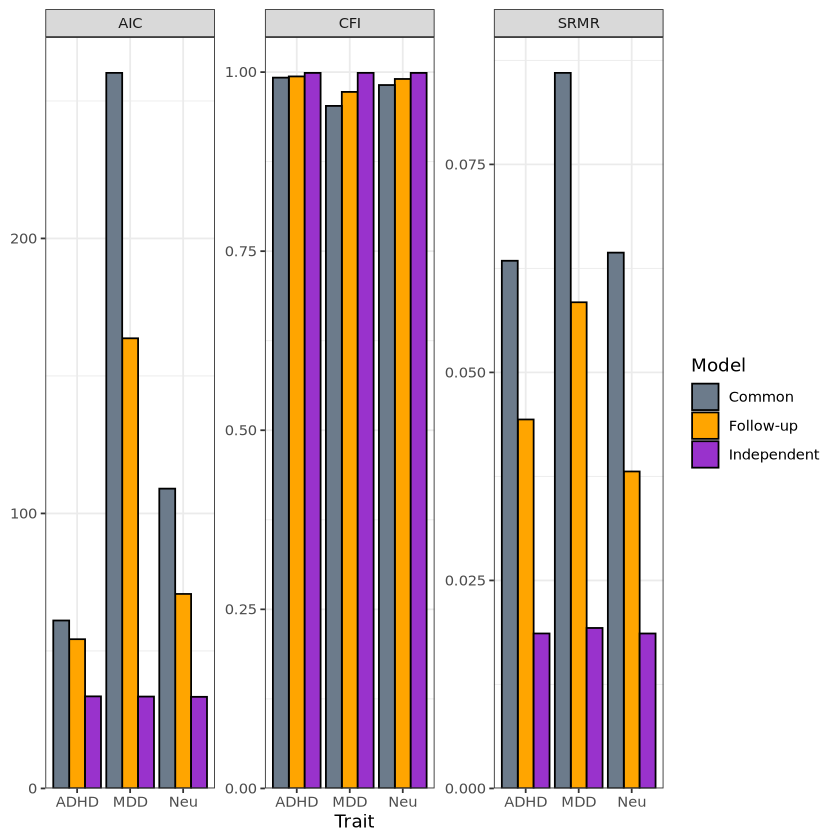

In [96]:
modelfit_follow_up_plot <- ggplot(follow_up_complete, aes(x = Trait, y = Value, fill = Model)) +
geom_col(position = position_dodge(), color = "black") + 
theme_bw() + 
facet_wrap(facets = vars(Metric), nrow = 1, ncol = 3, scales = "free") +
scale_fill_manual(values = c("slategray4","orange", "darkorchid")) +
scale_y_continuous(expand = expansion(mult = c(0,0.05))) +
theme(axis.title.y = element_blank())

modelfit_follow_up_plot

In [97]:
ggsave("/local1/home/pazweifel/plots/bip_paper/modelfit_follow_up.svg", modelfit_follow_up_plot, width = 8, height = 6)

In [98]:
model_fit_follow_up_wide <- pivot_wider(follow_up_complete, values_from = "Value", names_from = "Model")

In [99]:
model_fit_follow_up_wide %>% select(Trait, Metric, Common, everything()) %>% mutate(Common = round(Common, 3), `Follow-up` = round(`Follow-up`, 3), Independent = round(Independent, 3))

Trait,Metric,Common,Follow-up,Independent
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ADHD,AIC,61.063,54.265,33.469
ADHD,CFI,0.992,0.994,0.999
ADHD,SRMR,0.063,0.044,0.019
MDD,AIC,260.220,163.697,33.403
MDD,CFI,0.953,0.972,0.999
MDD,SRMR,0.086,0.058,0.019
Neu,AIC,109.020,70.726,33.308
Neu,CFI,0.982,0.990,0.999
Neu,SRMR,0.064,0.038,0.019


### Follow-up models with Marcs thresholds and custom function

In [100]:
##### qtrait with adjusted thresholds
trait.qtrait_adjusted <- bind_rows(lapply(traits, function(trait) {
    QTrait(
    LDSCoutput = trait.covstructs[[trait]],
    indicators = sample_names,
    traits = trait,
    mresid = 0.1,
    mresidthreshold = 0.05,
    lsrmr = 0.1,
    lsrmrthreshold = 0.05
    )
    }),
    .id = "Trait")


 ---------------------------- 

 Fitting common pathways model for external trait ADHD 
 

 Fitting independent pathways model for external trait ADHD 
 

 Fitting follow-up model for external trait ADHD 
 

 Most egregious outlier: BDII 
 

 ---------------------------- 

 Fitting follow-up model for external trait ADHD 
 

 Most egregious outliers: BDII,Comm 
 

 ---------------------------- 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait ALC 
 

 Fitting independent pathways model for external trait ALC 
 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait AN 
 

 Fitting independent pathways model for external trait AN 
 

 Fitting follow-up model for external trait AN 
 

 Most egregious outlier: Comm 
 

 ---------------------------- 
---------------------------- 

 ---------------------------- 

 Fitting common pathways model for external trait ASD 
 


In [101]:
follow_up_model_core <- "F1=~NA*Clin+Comm+BDI+BDII
F1~~1*F1
Clin~~a*Clin
a > 0.0001
F1~~{trait}
"
internal_1_model <- "\n{internal1} ~ b*{trait}"
internal_2_model <- "\n{internal2} ~ c*{trait}"
internal_3_model <- "\n{internal3} ~ d*{trait}"
internal_4_model <- "\n{internal4} ~ e*{trait}"

internal_models <- c(internal_1_model, internal_2_model, internal_3_model, internal_4_model)

In [102]:
#extracting the relevant traits
follow_up_names_adjusted <- trait.qtrait_adjusted[trait.qtrait_adjusted$Unconstrained_paths != "None",]$Trait
traits[follow_up_names_adjusted]
follow_up_table_adjusted <- trait.qtrait_adjusted[trait.qtrait_adjusted$Unconstrained_paths != "None",]

ADHD        AN       ASD       MDD       Neu   Smoking 
   "ADHD"      "AN"     "ASD"     "MDD"     "Neu" "Smoking"

In [103]:
their_follow_up_models.fit_adjusted <- lapply(traits[follow_up_names_adjusted], function(trait) {
                                outliers <- str_split_1(follow_up_table_adjusted[follow_up_table_adjusted$Trait == trait,][1,]$Unconstrained_paths, pattern = ",")
                                #assign outliers to the variables
                                internal1 <- outliers[1]
                                internal2 <- outliers[2]
                                internal3 <- outliers[3]
                                internal4 <- outliers[4]

                                combined_model <- follow_up_model_core
                                for (i in 1:length(outliers)){
                                    combined_model <- paste0(combined_model, internal_models[i])
                                    
                                }
                                #fit the follow up model with the pasted construct
                                usermodel(covstruc = trait.covstructs[[trait]],
                                          estimation = "DWLS",
                                          model = str_glue(combined_model),
                                          imp_cov = TRUE
    )     
})



[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.288 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00237470346007324 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.243082909605935 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.284 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00230453312512133 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.245173492660783 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.277 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00231669217864469 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.24280073263769 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


...

Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.279 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00241517222659851 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.245664475433266 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.327 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.00235157753222917 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.243830633895559 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruc = trait.covstructs[[trait]], estimation = "DWLS", :
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”


In [104]:
for (trait in follow_up_names){
    #currentmodel
    temp <- their_follow_up_models.fit_adjusted[[trait]]
    #create the semmodel used in the semPaths function
    tempsem <- semPlotModel_GSEM(temp)
    #extract the standardized estimates and the errors from results
    est_temp <- temp$results$STD_Genotype
    se_temp <- temp$results$STD_Genotype_SE
   
    labels_temp <- paste(round(as.numeric(est_temp), 2),"\n (", round(as.numeric(se_temp), 2),")")
    #create the object in which the plot can be deposited
    svg(filename = paste0("/local1/home/pazweifel/plots/bip_paper/",trait,"adj_threshold_follow_up_model.svg"), width = 11, height = 10)
    semPaths(tempsem, whatLabels = "std", layout = "circle", edge.color = "black", sizeMan = 12, sizeLat = 12, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 1,
        rotation = 1,
        esize = 2,
        edge.label.position = 0.5,
        edgeLabels = labels_temp[1:(length(est_temp)-1)])
    dev.off()
}

## Experimenting with bias model

### One bias phenotype model to see if it loads

In [105]:
bias_model_adhd <- "
Liability=~NA*Clin+Comm+ADHD
Bias=~NA*ADHD+Comm
Liability ~~ 0*Bias
Clin ~~ 0*Clin
Comm ~~ 0*Comm
"

#gives a negative cfi, huge standard error for adhd estimators

bias_model_yazheng_adhd <- "
Liability =~ NA*Clin+ADHD
Bias =~ NA*ADHD
Liability ~~ 0*Bias
Clin ~~ 0*Clin
ADHD ~~ 0*ADHD
"

In [106]:
usermodel(trait.covstructs$ADHD, estimation = "DWLS", model = bias_model_adhd, std.lv = TRUE, imp_cov = TRUE, CFIcalc = TRUE)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.185 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


$modelfit
   chisq df p_chisq AIC CFI SRMR
df    NA  0      NA  NA  NA   NA

$results
         lhs op       rhs Unstand_Est         Unstand_SE STD_Genotype
8  Liability =~      Clin  0.43296923 0.0123219222704378    1.0000000
9  Liability =~      Comm  0.22453277 0.0113247691469528    0.9514683
7  Liability =~      ADHD  0.06467061 0.0194437314912245    0.1532530
2       Bias =~      ADHD  0.23276176  0.129317194660438    0.5515866
3       Bias =~      Comm  0.07262377 0.0349469120011042    0.3077467
1       ADHD ~~      ADHD  0.11971174 0.0603021920040001    0.6722657
10 Liability ~~      Bias  0.00000000                       0.0000000
5       Clin ~~      Clin  0.00000000                       0.0000000
6       Comm ~~      Comm  0.00000000                       0.0000000
11 Liability ~~ Liability  1.00000000                       1.0000000
4       Bias ~~      Bias  1.00000000                       1.0000000
      STD_Genotype_SE   STD_All       p_value
8   0.028459117741689 1.0000000 1.765122e-270
9  0.0479892492698018 0.9514683  1.751708e-87
7  0.0460767367693355 0.1532530  8.808959e-04
2   0.306449115597428 0.5515866  7.187186e-02
3   0.148089205867753 0.3077467  3.769858e-02
1   0.338639251029269 0.6722657  4.712254e-02
10                    0.0000000            NA
5                     0.0000000            NA
6                     0.0000000            NA
11                    1.0000000            NA
4                     1.0000000            NA

$resid_cov
$resid_cov$`Model Implied Covariance Matrix`
           Clin       Comm       ADHD
Clin 0.18746235 0.09721578 0.02800038
Comm 0.09721578 0.05568918 0.03142471
ADHD 0.02800038 0.03142471 0.17807207

$resid_cov$`Residual Covariance Matrix: Calculated as Observed Cov - Model Implied Cov`
              Clin          Comm          ADHD
Clin -1.560529e-11 -4.440587e-12 -8.681944e-14
Comm -4.440587e-12 -5.889594e-13 -1.704054e-11
ADHD -8.681944e-14 -1.704054e-11  4.719919e-12

In [107]:
usermodel(trait.covstructs$ADHD, estimation = "DWLS", model = bias_model_yazheng_adhd, std.lv = TRUE, imp_cov = TRUE, CFIcalc = TRUE)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
   0.15 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


$modelfit
   chisq df p_chisq AIC CFI SRMR
df    NA  0      NA  NA  NA   NA

$results
        lhs op       rhs Unstand_Est         Unstand_SE STD_Genotype
6 Liability =~      Clin  0.43296923 0.0123219222696439     1.000000
5 Liability =~      ADHD  0.06467061 0.0194437314898109     0.153253
2      Bias =~      ADHD  0.41700094 0.0151652933410196     0.988187
7 Liability ~~      Bias  0.00000000                        0.000000
4      Clin ~~      Clin  0.00000000                        0.000000
1      ADHD ~~      ADHD  0.00000000                        0.000000
8 Liability ~~ Liability  1.00000000                        1.000000
3      Bias ~~      Bias  1.00000000                        1.000000
     STD_Genotype_SE  STD_All       p_value
6 0.0284591177420744 1.000000 1.765121e-270
5  0.046076736770227 0.153253  8.808958e-04
2 0.0359379180720689 0.988187 1.903825e-166
7                    0.000000            NA
4                    0.000000            NA
1                    0.000000            NA
8                    1.000000            NA
3                    1.000000            NA

$resid_cov
$resid_cov$`Model Implied Covariance Matrix`
           Clin       ADHD
Clin 0.18746235 0.02800038
ADHD 0.02800038 0.17807207

$resid_cov$`Residual Covariance Matrix: Calculated as Observed Cov - Model Implied Cov`
              Clin          ADHD
Clin -3.976086e-11 -3.271336e-11
ADHD -3.271336e-11 -4.140011e-11

### Multi bias model Bipolar created with Yazheng

In [108]:
#calcualte one big covariance matrix involving the clinical bipolar trait and all external ones
covstruct_bias_all <- here::here("matrices/Clinical_all_external.R")

pop_prev <- c(bip_prevalences["Clin"], other_prevalences)

samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))

paths <- c(samples[1])

for (name in names(other_prevalences)){
    if (name == "MDD"){
        paths <- c(paths, "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz")
        }
    else{
        paths <- c(paths, paste0(other_basepath, name, ".sumstats.gz"))
        }
}

    
if (!file.exists(covstruct_bias_all)){
    covstruct_bias_all_ldsc <- ldsc(
        traits = paths,
        trait.names = names(pop_prev),
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld, 
        wld = weights,
        stand = TRUE
        )
    dput(covstruct_bias_all_ldsc, covstruct_bias_all, control = c("all", "digits17"))
}

In [109]:
bias_all.covstruct <- dget("matrices/Clinical_all_external.R")

In [110]:
#similar to what we had above, one common bias 
model <- "
Liability =~ NA*Clin + ADHD + ALC + AN + ASD + BMI + CAD + Chrono + CRP + Height + Neu + PD + PTSD + SCZ + Smoking + T2D + PartEM + PartMH + PartSF
Bias =~ NA*ADHD + ALC + AN + ASD + BMI + CAD + Chrono + CRP + Height + Neu + PD + PTSD + SCZ + Smoking + T2D + PartEM + PartMH + PartSF

Liability ~~ 0*Bias
Bias ~~ 1*Bias
Liability ~~ 1*Liability

Clin ~~ 0*Clin
"
#idea: liability factor captures pleiotropic factors between phenotypes and clinical, "true" genetic correlation, bias factor captures shared bias variants between external phenotypes, and freely estimated residual variances captures phenotype specific variances

In [111]:
all_bias.fit <- usermodel(covstruc = bias_all.covstruct, estimation = "DWLS", model = model, CFIcalc = TRUE, imp_cov = TRUE)

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  2.925 


In [112]:
write.table(x = all_bias.fit$results,
            file = "/local1/scratch/pazweifel/all_bias_bip.fit.tsv",
            sep = "\t",
            row.names = FALSE,
            col.names = TRUE,
            quote = FALSE)
            

In [113]:
# 1. Define initial phenotypes

bias_phenotypes <- c("ADHD", "ALC", "AN", "ASD", "BMI", "CAD", "Chrono", 

                     "CRP", "Height", "Neu", "PD", "PTSD", "SCZ", 

                     "Smoking", "T2D", "PartEM", "PartMH", "PartSF")



# Helper function for the model string

build_model <- function(phenos) {

  paste0("

    Liability =~ NA*Clin

    Liability ~~ 1*Liability

    Bias =~ NA*", paste(phenos, collapse = " + "), "

    Bias ~~ 1*Bias

    Liability ~~ 0*Bias

    Clin ~~ 0*Clin

    Clin ~~ ", paste(phenos, collapse = " + ")

  )

}



# 2. Fit the initial model

fit1 <- usermodel(

  bias_all.covstruct, 

  estimation = "DWLS", 

  model = build_model(bias_phenotypes)

)

fit1

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  2.723 


Warning message in usermodel(bias_all.covstruct, estimation = "DWLS", model = build_model(bias_phenotypes)):
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(bias_all.covstruct, estimation = "DWLS", model = build_model(bias_phenotypes)):
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


$modelfit
      chisq  df p_chisq      AIC      CFI      SRMR
df 11804.86 135       0 11914.86 0.573763 0.1372956

$results
         lhs op       rhs   Unstand_Est          Unstand_SE  STD_Genotype
48 Liability =~      Clin  4.329691e-01  0.0126735981738992  0.9999999007
5       Bias =~      ADHD  2.716305e-01  0.0163500277769006  0.6436957989
6       Bias =~       ALC  1.422158e-01  0.0169908145904043  0.4130881877
7       Bias =~        AN -6.301574e-02  0.0126766256606749 -0.1666757927
8       Bias =~       ASD  3.094175e-02  0.0162399393467784  0.0986451802
9       Bias =~       BMI  2.510740e-01   0.010500519651464  0.5436570222
10      Bias =~       CAD  1.526189e-01 0.00614964091292162  0.5118284546
11      Bias =~    Chrono  2.216002e-02 0.00754066388556321  0.0679106945
12      Bias =~       CRP  1.486620e-01  0.0101033917165057  0.4961608421
13      Bias =~    Height -1.161646e-01  0.0129397950270036 -0.1599046530
14      Bias =~       Neu  7.163327e-02 0.00711647114290693  0.2262531007
18      Bias =~        PD  5.048884e-02  0.0300564451549747  0.1058118039
19      Bias =~      PTSD  1.041452e-01 0.00816659180604921  0.6144348900
20      Bias =~       SCZ  3.066303e-02 0.00976488697374862  0.0661837721
21      Bias =~   Smoking  1.405520e-01 0.00621944196908389  0.5618005960
22      Bias =~       T2D  2.303409e-01 0.00775369537664576  0.6098069590
15      Bias =~    PartEM -1.249098e-01 0.00667805223957455 -0.4810063357
16      Bias =~    PartMH -1.506646e-01 0.00687121784382251 -0.5075553249
17      Bias =~    PartSF -1.620966e-02 0.00634841343956596 -0.1341964459
27      Clin ~~      ADHD  2.800043e-02 0.00823111606802876  0.1532531444
28      Clin ~~       ALC  3.884414e-02  0.0103038275885903  0.2605939398
29      Clin ~~        AN  3.623107e-02 0.00639099997402508  0.2213332380
30      Clin ~~       ASD  2.415034e-02 0.00723628632920789  0.1778262322
31      Clin ~~       BMI -6.043132e-03 0.00458503777657618 -0.0302224985
32      Clin ~~       CAD  3.402988e-04 0.00374794824510671  0.0026354868
33      Clin ~~    Chrono -3.420939e-03 0.00434140656982086 -0.0242133780
35      Clin ~~       CRP  2.760912e-05 0.00528508318403289  0.0002126388
36      Clin ~~    Height -9.210610e-03 0.00701488114375109 -0.0292831052
37      Clin ~~       Neu  2.323896e-02 0.00455532677731472  0.1695276053
41      Clin ~~        PD  6.072277e-03  0.0179808269989091  0.0293889260
42      Clin ~~      PTSD  2.483588e-02 0.00529724117943262  0.3384217908
43      Clin ~~       SCZ  1.432240e-01 0.00789508723156683  0.7139939935
44      Clin ~~   Smoking  6.764609e-03 0.00378875372835724  0.0624502903
45      Clin ~~       T2D -5.830908e-03 0.00418044259256573 -0.0356535604
38      Clin ~~    PartEM -6.631343e-04 0.00458693051702289 -0.0058979817
39      Clin ~~    PartMH -9.000130e-03 0.00478878150386481 -0.0700273892
40      Clin ~~    PartSF  7.580470e-03 0.00303857764498596  0.1449440647
1       ADHD ~~      ADHD  1.042888e-01  0.0128098008765543  0.5856546258
2        ALC ~~       ALC  9.829926e-02  0.0228587195871303  0.8293439488
3         AN ~~        AN  1.389688e-01   0.010620119226989  0.9722196522
4        ASD ~~       ASD  9.743069e-02 0.00965649073061878  0.9902665168
24       BMI ~~       BMI  1.502436e-01 0.00596976399262808  0.7044371721
25       CAD ~~       CAD  6.562085e-02 0.00535447312107337  0.7380311147
26    Chrono ~~    Chrono  1.059886e-01 0.00390761414828427  0.9953882705
46       CRP ~~       CRP  6.767472e-02 0.00967644922945685  0.7538228729
47    Height ~~    Height  5.142521e-01  0.0237925987531712  0.9744306923
51       Neu ~~       Neu  9.510850e-02 0.00339548117806404  0.9488093705
55        PD ~~        PD  2.251163e-01  0.0578983177941912  0.9887519814
56      PTSD ~~      PTSD  1.788318e-02 0.00519406058913596  0.6224641158
57       SCZ ~~       SCZ  2.137085e-01 0.00938619816532628  0.9956199676
58   Smoking ~~   Smoking  4.283579e-02 0.00408354434432439  0.6843807151
59       T2D ~~       T2D  8

In [114]:
# 3. Extract and check the loadings

# Note: lhs is the Latent Factor (Bias), op is the loading (=~), rhs is the phenotype

loadings_df <- subset(fit1$results, lhs == "Bias" & op == "=~")



# 4. Filter phenotypes based on the 0.3 threshold in STD_Genotype

keep_phenos <- loadings_df$rhs[loadings_df$STD_Genotype >= 0.3]



# 5. Fit the pruned model

fit2 <- usermodel(

  bias_all.covstruct, 

  estimation = "DWLS", 

  model = build_model(keep_phenos)

)



fit2

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.311 


Warning message in usermodel(bias_all.covstruct, estimation = "DWLS", model = build_model(keep_phenos)):
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(bias_all.covstruct, estimation = "DWLS", model = build_model(keep_phenos)):
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


$modelfit
      chisq df      p_chisq      AIC       CFI      SRMR
df 240.4219 20 9.688563e-40 290.4219 0.9034549 0.1097517

$results
         lhs op       rhs   Unstand_Est          Unstand_SE  STD_Genotype
24 Liability =~      Clin  0.4329692192  0.0126735934979385  1.0000000112
3       Bias =~      ADHD  0.2180763175  0.0152149437994176  0.5167858566
4       Bias =~       ALC  0.0788375610  0.0163252318900269  0.2289962508
5       Bias =~       BMI  0.3120758955   0.012521697389455  0.6757459374
6       Bias =~       CAD  0.1503508490 0.00588632752351242  0.5042223596
7       Bias =~       CRP  0.1757785670   0.010685807805105  0.5866627281
8       Bias =~      PTSD  0.0789639533 0.00794530370141594  0.4658708307
9       Bias =~   Smoking  0.1307752355 0.00581069552623539  0.5227219389
10      Bias =~       T2D  0.2836579345 0.00894863820671415  0.7509593885
14      Clin ~~      ADHD  0.0280003743 0.00823111606802876  0.1532532561
15      Clin ~~       ALC  0.0388440260  0.0103038275885903  0.2605923451
16      Clin ~~       BMI -0.0060431584 0.00458503777657618 -0.0302224708
17      Clin ~~       CAD  0.0003402742 0.00374794824510671  0.0026358267
19      Clin ~~       CRP  0.0000275562 0.00528508318403289  0.0002124855
20      Clin ~~      PTSD  0.0248358658 0.00529724117943262  0.3384223145
21      Clin ~~   Smoking  0.0067646264 0.00378875372835724  0.0624500818
22      Clin ~~       T2D -0.0058309343 0.00418044259256573 -0.0356535927
1       ADHD ~~      ADHD  0.1305148620  0.0132363872112923  0.7329328458
2        ALC ~~       ALC  0.1123100933  0.0224367197083241  0.9475587227
12       BMI ~~       BMI  0.1158903161 0.00625108124546817  0.5433674469
13       CAD ~~       CAD  0.0663080577 0.00528247570386447  0.7457599894
23       CRP ~~       CRP  0.0588768784 0.00976600754416695  0.6558229073
27      PTSD ~~      PTSD  0.0224941236 0.00512502183418779  0.7829624433
28   Smoking ~~   Smoking  0.0454885020 0.00400192420191518  0.7267616476
29       T2D ~~       T2D  0.0622161835 0.00755858101675805  0.4360598043
26 Liability ~~ Liability  1.0000000000                      1.0000000000
11      Bias ~~      Bias  1.0000000000                      1.0000000000
25 Liability ~~      Bias  0.0000000000                      0.0000000000
18      Clin ~~      Clin  0.0000000000                      0.0000000000
      STD_Genotype_SE       STD_All       p_value
24 0.0292713481993435  1.0000000112 8.545049e-256
3  0.0360555757922609  0.5167857358  1.360435e-46
4  0.0474191921302641  0.2289964791  1.370932e-06
5  0.0271135502494449  0.6757459311 4.211122e-137
6  0.0197406146755903  0.5042223149 6.671587e-144
7  0.0356639698083338  0.5866638827  8.425417e-61
8   0.046875618316665  0.4658712793  2.832173e-23
9  0.0232259413922963  0.5227219721 3.629349e-112
10 0.0236907292772636  0.7509594608 1.632146e-220
14 0.0450509332836206  0.1532532561  6.695064e-04
15 0.0691251945185925  0.2605923451  1.633367e-04
16 0.0229302665991206 -0.0302224708  1.874979e-01
17 0.0290303880732508  0.0026358267  9.276599e-01
19 0.0407396346131338  0.0002124855  9.958399e-01
20  0.072182053772794  0.3384223145  2.752782e-06
21 0.0349771630430182  0.0624500818  7.418852e-02
22 0.0255615235567687 -0.0356535927  1.630723e-01
1  0.0743316306273125  0.7329325033  6.185900e-23
2   0.189299297164025  0.9475606126  5.567735e-07
12 0.0293090368752465  0.5433674367  9.961337e-77
13 0.0594114411287009  0.7457598572  3.853562e-36
23  0.108783178227706  0.6558254887  1.652263e-09
27  0.178389284999358  0.7829639511  1.138319e-05
28 0.0639380412627131  0.7267617399  6.128987e-30
29 0.0529765029171672  0.4360598882  1.853490e-16
26                     1.0000000000            NA
11                     1.0000000000            NA
25                     0.0000000000            NA
18                     0.0000000000            NA

In [115]:
fitlist_yazheng <- list(fit1, fit2)

saveRDS(object = fitlist_yazheng,
        file = "/local1/scratch/pazweifel/bip_bias_fits.R")
        

In [116]:
aaa <- readRDS(file = "/local1/scratch/pazweifel/bip_bias_fits.R")

### Estimate Covamtrix with Clinical, Community and selected biases

In [117]:
#calcualte covariance matrix including the selected phenotypes after yazheng analysis, clinical and community
keep_phenos <- keep_phenos[keep_phenos != "ALC"]

covstruct_bias_selected <- here::here("matrices/Clinical_community_selected_external.R")

pop_prev <- c(bip_prevalences["Clin"], bip_prevalences["Comm"], other_prevalences[keep_phenos])

samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))

paths <- c(samples[1], samples[2])

for (name in keep_phenos){
        paths <- c(paths, paste0(other_basepath, name, ".sumstats.gz"))
        
}

    
if (!file.exists(covstruct_bias_selected)){
    covstruct_bias_selected_ldsc <- ldsc(
        traits = paths,
        trait.names = names(pop_prev),
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld, 
        wld = weights,
        stand = TRUE
        )
    dput(covstruct_bias_selected_ldsc, covstruct_bias_selected, control = c("all", "digits17"))
}

In [118]:
covstruct.bias_clincom <- dget("matrices/Clinical_community_selected_external.R")

In [119]:
# 1. Define and clean the phenotype list
# Assuming keep_phenos was defined by your previous 0.3 threshold filtering
keep_phenos <- keep_phenos[keep_phenos != "ALC"]

# ---------------------------------------------------------
# 2. Define the NULL Model String
# Commu is NOT loaded by Bias; rG is estimated between Liability and Liab_commu
# ---------------------------------------------------------
model_null <- paste0("
  Liability =~ NA*Clin
  Liability ~~ 1*Liability
  
  Liab_commu =~ NA*Comm
  Liab_commu ~~ 1*Liab_commu
  
  Bias =~ NA*", paste(keep_phenos, collapse = " + "), "
  Bias ~~ 1*Bias
  
  Liability ~~ 0*Bias
  Liab_commu ~~ 0*Bias
  Clin ~~ 0*Clin
  Comm ~~ 0*Comm
  
  # Estimate rG between the two Latent Factors
  Liability ~~ Liab_commu
  
  # Free residual covariances
  Clin ~~ ", paste(keep_phenos, collapse = " + ")
)

# ---------------------------------------------------------
# 3. Define the FULL Model String
# Same as Null, but adding Bias =~ Commu
# ---------------------------------------------------------
model_full <- paste0("
  Liability =~ NA*Clin
  Liability ~~ 1*Liability
  
  Liab_commu =~ NA*Comm
  Liab_commu ~~ 1*Liab_commu

  # Bias now loads onto the pruned list AND Comm
  Bias =~ NA*", paste(keep_phenos, collapse = " + "), " + Comm
  Bias ~~ 1*Bias
  
  Liability ~~ 0*Bias
  Liab_commu ~~ 0*Bias
  Clin ~~ 0*Clin
  Comm ~~ 0*Comm
  
  # Estimate rG between the two Latent Factors
  Liability ~~ Liab_commu
  
  # Free residual covariances
  Clin ~~ ", paste(keep_phenos, collapse = " + ")
)

# ---------------------------------------------------------
# 4. Fit the Models
# ---------------------------------------------------------
fit_null <- usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_null)
fit_full <- usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_full)

# ---------------------------------------------------------
# 5. Compare results
# ---------------------------------------------------------

# Extract rG (Liability ~~ Liab_commu) from both
rg_null <- subset(fit_null$results, lhs == "Liability" & op == "~~" & rhs == "Liab_commu")
rg_full <- subset(fit_full$results, lhs == "Liability" & op == "~~" & rhs == "Liab_commu")

# Extract the loading of Bias on Commu from the Full model
loading_full <- subset(fit_full$results, lhs == "Bias" & op == "=~" & rhs == "Comm")

# Combine for comparison table
comparison_table <- data.frame(
  Model = c("Null", "Full", "Full (Loading)"),
  Relationship = c("rG(Liab, Comm)", "rG(Liab, Comm)", "Bias -> Comm"),
  Unstand_Est = c(rg_null$Unstand_Est, rg_full$Unstand_Est, loading_full$Unstand_Est),
  STD_Genotype = c(rg_null$STD_Genotype, rg_full$STD_Genotype, loading_full$STD_Genotype),
  P_Value = c(rg_null$p_value, rg_full$p_value, loading_full$p_value)
)

print(comparison_table)

# Optional: Compare Model Fit Indices
cat("\nModel Fit Comparison:\n")
cat("Null Model AIC:", fit_null$modelfit$AIC, "\n")
cat("Full Model AIC:", fit_full$modelfit$AIC, "\n")

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.339 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.000834273222745319 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.139729471445952 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_null):
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_null):
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_null):
“The st

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.344 
[1] "The S matrix was smoothed prior to model estimation due to a non-positive definite matrix. The largest absolute difference in a cell between the smoothed and non-smoothed matrix was  0.000834273222745319 As a result of the smoothing, the largest Z-statistic change for the genetic covariances was  0.139729471445952 . We recommend setting the smooth_check argument to true if you are going to run a multivariate GWAS."


Warning message in usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_full):
“A difference greater than .025 was observed pre- and post-smoothing for Z-statistics in the genetic covariance matrix. This reflects a large difference and results should be interpreted with caution!! This can often result from including low powered traits, and you might consider removing those traits from the model. If you are going to run a multivariate GWAS we strongly recommend setting the smooth_check argument to true to check smoothing for each SNP.”
Warning message in usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_full):
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(covstruct.bias_clincom, estimation = "DWLS", model = model_full):
“The st

           Model   Relationship Unstand_Est STD_Genotype      P_Value
1           Null rG(Liab, Comm) -0.94040379    0.9404059 5.780760e-94
2           Full rG(Liab, Comm) -0.94699612    0.9470045 9.681761e-92
3 Full (Loading)   Bias -> Comm  0.02801478    0.1178346 9.568334e-04

Model Fit Comparison:
Null Model AIC: 408.8012 
Full Model AIC: 415.7705 


In [120]:
fit_full

$modelfit
      chisq df      p_chisq      AIC       CFI    SRMR
df 365.7705 20 2.486422e-65 415.7705 0.8926864 0.12686

$results
          lhs op        rhs   Unstand_Est          Unstand_SE  STD_Genotype
26  Liability =~       Clin -4.331598e-01  0.0123165000127756  0.9999998536
23 Liab_commu =~       Comm  2.360908e-01 0.00924318507821433  0.9930335884
2        Bias =~       ADHD  2.206575e-01  0.0149910402196974  0.5229007723
3        Bias =~        BMI  3.128742e-01  0.0122874065700688  0.6774736470
4        Bias =~        CAD  1.505443e-01 0.00599738538828786  0.5048714089
6        Bias =~        CRP  1.778123e-01   0.010417210481764  0.5934498470
7        Bias =~       PTSD  7.987942e-02 0.00772342824563493  0.4691254350
8        Bias =~    Smoking  1.320804e-01 0.00575572969050306  0.5279352010
9        Bias =~        T2D  2.824595e-01 0.00968420380293274  0.7477866771
5        Bias =~       Comm  2.801478e-02 0.00848181941832586  0.1178345717
28  Liability ~~ Liab_commu -9.469961e-01  0.0466180425989057  0.9470044699
13       Clin ~~       ADHD  2.798698e-02 0.00852283706053562  0.1531120596
14       Clin ~~        BMI -6.054670e-03 0.00518134559429224 -0.0302666972
15       Clin ~~        CAD  3.372553e-04 0.00374300565538614  0.0026107524
17       Clin ~~        CRP  2.569472e-05 0.00528864705790325  0.0001977569
18       Clin ~~       PTSD  2.504416e-02  0.0051314186420631  0.3395571708
19       Clin ~~    Smoking  6.776549e-03 0.00377013719548614  0.0625321533
20       Clin ~~        T2D -5.832350e-03 0.00467831779427188 -0.0356469737
1        ADHD ~~       ADHD  1.293834e-01  0.0128320663489351  0.7265747564
11        BMI ~~        BMI  1.153922e-01 0.00614763013548132  0.5410294108
12        CAD ~~        CAD  6.624990e-02 0.00515079857030588  0.7451035142
22        CRP ~~        CRP  5.815782e-02  0.0100423664707819  0.6478173015
30       PTSD ~~       PTSD  2.261220e-02  0.0052254538670439  0.7799124503
31    Smoking ~~    Smoking  4.514629e-02 0.00406447823028105  0.7212847755
32        T2D ~~        T2D  6.289462e-02 0.00764268193873037  0.4408154242
29  Liability ~~  Liability  1.000000e+00                      1.0000000000
25 Liab_commu ~~ Liab_commu  1.000000e+00                      1.0000000000
10       Bias ~~       Bias  1.000000e+00                      1.0000000000
27  Liability ~~       Bias  0.000000e+00                      0.0000000000
24 Liab_commu ~~       Bias  0.000000e+00                      0.0000000000
16       Clin ~~       Clin  0.000000e+00                      0.0000000000
21       Comm ~~       Comm  0.000000e+00                      0.0000000000
      STD_Genotype_SE       STD_All       p_value
26 0.0284341459779381  0.9999998536 5.942212e-271
23 0.0388783813086908  0.9930332438 6.711646e-144
2  0.0355248642623546  0.5229007790  4.846868e-49
3  0.0266061876581369  0.6774736629 5.067878e-143
4  0.0201130560231148  0.5048717487 4.769738e-139
6   0.034767515365396  0.5934498403  2.521138e-65
7  0.0453590652539552  0.4691275170  4.526588e-25
8  0.0230060761600934  0.5279351081 1.555653e-116
9  0.0256380700868453  0.7477865505 5.080416e-187
5  0.0356758721446328  0.1178345308  9.568334e-04
28 0.0466183667530023  0.9470044699  9.681761e-92
13 0.0466269781713669  0.1531120596  1.024311e-03
14 0.0259010442205812 -0.0302666972  2.425843e-01
15 0.0289793705273616  0.0026107524  9.282055e-01
17 0.0407492089267354  0.0001977569  9.961235e-01
18 0.0695734964770763  0.3395571708  1.057886e-06
19 0.0347897822017123  0.0625321533  7.226775e-02
20  0.028593249855136 -0.0356469737  2.125161e-01
1  0.0720606377072967  0.7265747753  6.581133e-24
11 0.0288238986292656  0.5410294361  1.324088e-78
12   0.05793044589877  0.7451045173  7.358563e-38
22  0.111861496269769  0.6478172870  6.986591e-09
30  0.180232104187191  0.7799193728  1.509361e-05
31 0.0649365597603074  0.7212845216  1.153119e-28
32 0.0535659389582833  0.4408152749  1.881673e-16
29                     1.0000000000            NA
25          

In [121]:
Unstand_Est <-c(rg_null$Unstand_Est, rg_full$Unstand_Est, loading_full$Unstand_Est)
STD_Genotype <- c(rg_null$STD_Genotype, rg_full$STD_Genotype, loading_full$STD_Genotype)

In [122]:
Unstand_Est
STD_Genotype

[1] -0.94040379 -0.94699612  0.02801478

[1] 0.9404059 0.9470045 0.1178346

### GWAS by subtraction models for external phenotypes

In [123]:
#filter out all traits where a follow up model was fit and which outlier traits were used
follow_up_traits <- follow_up_table_adjusted %>% filter(Unconstrained_paths != "None") %>% subset(select = c(Trait, Unconstrained_paths))

In [124]:
bdII_traits <- c("ADHD", "ASD", "MDD", "Neu", "Smoking")
Comm_traits <- c("ADHD", "AN", "ASD", "MDD", "Neu", "Smoking")

int_ext_traits <- list("BDII" = bdII_traits, "Comm" = Comm_traits)

In [125]:
gwas_by_sub_model <- "
Liability_clin =~ NA*Clin
Liability_other =~ NA*{internal_trait}
Bias =~ NA*{external_trait} + {internal_trait}

Liability_clin ~~ 0*Bias
Liability_other ~~ 0*Bias

{internal_trait} ~~ 0*{internal_trait}
{external_trait} ~~ 0*{external_trait}
{external_trait} ~~ 0*{internal_trait}

Clin ~~ {external_trait}
Clin ~~ 0*{internal_trait}
Clin ~~ 0*Clin
"

In [126]:
#Community
names(Comm_traits) <- Comm_traits

comm_gwas_by_sub.fits <- lapply(Comm_traits, function(external_trait){
    internal_trait <- "Comm"

    usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", std.lv = TRUE, model = str_glue(gwas_by_sub_model))
    })

[1] "Running primary model"
[1] "Error: The primary model produced correlations among your latent variables that are either greater than 1 or less than -1, or the latent variables have negative variances. \n              Consequently, model fit estimates could not be computed and results should likely not be interpreted. Results are provided below \n              to enable troubleshooting. A model constraint that constrains the latent correlations to be above -1, less than 1, or to have positive variances is suggested."
               lhs op             rhs Unstandardized_Estimate          SE
1   Liability_clin =~            Clin             -0.43296923 0.012321922
2  Liability_other =~            Comm              0.22392767 0.010072985
3             Bias =~            ADHD              0.42198586 0.015676493
4             Bias =~            Comm              0.07446863 0.012809134
10            Clin ~~            ADHD              0.02800038 0.008522837
16  Liability_clin ~~ Liabilit

Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.169 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Error: The primary model produced correlations among your latent variables that are either greater than 1 or less than -1, or the latent variables have negative variances. \n              Consequently, model fit estimates could not be computed and results should likely not be interpreted. Results are provided below \n              to enable troubleshooting. A model constraint that constrains the latent correlations to be above -1, less than 1, or to have positive variances is suggested."
               lhs op             rhs Unstandardized_Estimate          SE
1   Liability_clin =~            Clin             -0.43296923 0.012321922
2  Liability_other =~            Comm              0.18124236 0.010383498
3             Bias =~             MDD              0.22362217 0.004240057
4             Bias =~            Comm              0.15113036 0.008777576
10            Clin ~~             MDD              0.03969544 0.003688300
16  Liability_clin ~~ Liabilit

Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.172 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


In [127]:
#Community
names(bdII_traits) <- bdII_traits

bdII_gwas_by_sub.fits <- lapply(bdII_traits, function(external_trait){
    internal_trait <- "BDII"

    usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", std.lv = TRUE, model = str_glue(gwas_by_sub_model))
    })

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.176 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.161 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Error: The primary model produced correlations among your latent variables that are either greater than 1 or less than -1, or the latent variables have negative variances. \n              Consequently, model fit estimates could not be computed and results should likely not be interpreted. Results are provided below \n              to enable troubleshooting. A model constraint that constrains the latent correlations to be above -1, less than 1, or to have positive variances is suggested."
               lhs op             rhs Unstandardized_Estimate          SE
1   Liability_clin =~            Clin              0.43296923 0.012321922
2  Liability_other =~            BDII              0.20150677 0.029738532
3             Bias =~             MDD              0.22362217 0.004240057
4             Bias =~            BDII              0.20529158 0.014838229
10            Clin ~~             MDD              0.03969544 0.003688300
16  Liability_clin ~~ Liabilit

Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.173 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(trait.covstructs[[external_trait]], estimation = "DWLS", :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


In [128]:
comm_gwas_by_sub.fits$Neu

$modelfit
   chisq df p_chisq AIC CFI SRMR
df    NA  0      NA  NA  NA   NA

$results
               lhs op             rhs Unstand_Est          Unstand_SE
9   Liability_clin =~            Clin -0.43296923  0.0123219222712568
13 Liability_other =~            Comm  0.22455756 0.00944354531896333
2             Bias =~             Neu  0.31660674 0.00578839701720022
1             Bias =~            Comm  0.07254710 0.00830592120704322
6             Clin ~~             Neu  0.02323901 0.00444505341050739
12  Liability_clin ~~ Liability_other -0.99988962  0.0512111393055104
10  Liability_clin ~~            Bias  0.00000000                    
14 Liability_other ~~            Bias  0.00000000                    
7             Comm ~~            Comm  0.00000000                    
16             Neu ~~             Neu  0.00000000                    
8             Comm ~~             Neu  0.00000000                    
5             Clin ~~            Comm  0.00000000                    
4             Clin ~~            Clin  0.00000000                    
11  Liability_clin ~~  Liability_clin  1.00000000                    
15 Liability_other ~~ Liability_other  1.00000000                    
3             Bias ~~            Bias  1.00000000                    
   STD_Genotype    STD_Genotype_SE   STD_All               p_value
9     1.0000000 0.0284591177563306 1.0000000 1.76512188785215e-270
13    0.9515734  0.040017473589384 0.9515734 5.51594847028828e-125
2     1.0000000 0.0182826080362072 1.0000000              < 5e-300
1     0.3074218 0.0351967371726621 0.3074218  2.44989035713483e-18
6     0.1695276 0.0324264786186024 0.1695276     1.71297932785e-07
12    0.9998896 0.0512111393480379 0.9998896  6.75197929576009e-85
10    0.0000000                    0.0000000                  <NA>
14    0.0000000                    0.0000000                  <NA>
7     0.0000000                    0.0000000                  <NA>
16    0.0000000                    0.0000000                  <NA>
8     0.0000000                    0.0000000                  <NA>
5     0.0000000                    0.0000000                  <NA>
4     0.0000000                    0.0000000                  <NA>
11    1.0000000                    1.0000000                  <NA>
15    1.0000000                    1.0000000                  <NA>
3     1.0000000                    1.0000000                  <NA>

In [129]:
community_table <- bind_rows(
    lapply(Comm_traits, function(trait){
        try(
            a <- filter(comm_gwas_by_sub.fits[[trait]]$results, lhs == "Liability_clin" & rhs == "Liability_other")
            )
        try(tibble(rg = a$STD_Genotype, se = a$STD_Genotype_SE))
        }),
    .id = "External_trait")

Error in UseMethod("filter") : 
  no applicable method for 'filter' applied to an object of class "NULL"
Error in UseMethod("filter") : 
  no applicable method for 'filter' applied to an object of class "NULL"


In [130]:
community_table$Internal_trait <- "Community"

In [131]:
bdii_table <- bind_rows(
    lapply(bdII_traits, function(trait){
        try(
            a <- filter(bdII_gwas_by_sub.fits[[trait]]$results, lhs == "Liability_clin" & rhs == "Liability_other")
            )
        try(tibble(rg = a$STD_Genotype, se = a$STD_Genotype_SE))
        }),
    .id = "External_trait")

Error in UseMethod("filter") : 
  no applicable method for 'filter' applied to an object of class "NULL"


In [132]:
bdii_table$Internal_trait <- "BDII"

In [133]:
combined_table <- bind_rows(community_table, bdii_table)

In [134]:
combined_table

External_trait,rg,se,Internal_trait
<chr>,<dbl>,<chr>,<chr>
AN,0.9986611,0.0532456383023662,Community
ASD,0.9957128,0.0559421139147135,Community
Neu,0.9998896,0.0512111393480379,Community
Smoking,0.9687430,0.0482220142838341,Community
ADHD,0.9719855,0.0725500269844533,BDII
ASD,0.9592717,0.0705444803059959,BDII
Neu,0.9889309,0.0715933435019714,BDII
Smoking,0.9317776,0.059305645215572,BDII


### 2 factor model including all external phenotypes wiht patterned correlation (same direction)

In [135]:
#traits: MDD, PTSD, Neu, AN, ASD, ADHD, Smoking
ambivalent_correlation_traits <- c("MDD", "PTSD", "Neu", "AN", "ASD", "ADHD", "Smoking")


two_factor_selected_traits_model <- paste0(
"Bias =~ NA*",paste(ambivalent_correlation_traits, collapse = " + "),"
Liability =~ NA*Clin + ",paste(ambivalent_correlation_traits, collapse = " + "),"
Bias ~~ 0*Liability
Clin ~~ 0*Clin
MDD ~~ a*MDD
a> 0.001")
    


In [136]:
two_factor_selected_traits_model
covstruct_2_factor_bias <- dget("matrices/Clinical_all_external.R")

[1] "Bias =~ NA*MDD + PTSD + Neu + AN + ASD + ADHD + Smoking\nLiability =~ NA*Clin + MDD + PTSD + Neu + AN + ASD + ADHD + Smoking\nBias ~~ 0*Liability\nClin ~~ 0*Clin\nMDD ~~ a*MDD\na> 0.001"

In [137]:
two_factor_extcorr.fit <- usermodel(covstruct_2_factor_bias, model = two_factor_selected_traits_model, std.lv = TRUE, estimation = "DWLS")

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.306 


In [138]:
two_factors_semobject <- semPlotModel_GSEM(two_factor_extcorr.fit)

In [139]:
se <- two_factor_extcorr.fit$results$STD_Genotype_SE
est <- two_factor_extcorr.fit$results$STD_Genotype
est.se <- paste0(round(as.numeric(est), 2),"\n (",round(as.numeric(se), 2),")")

In [140]:
pdf("/local1/home/pazweifel/plots/bip_paper/2_factor_extcorr_model.pdf", width = 30, height = 35)
semPaths(two_factors_semobject, layout = "circle", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)
dev.off()

agg_record_2126089027 
                    2

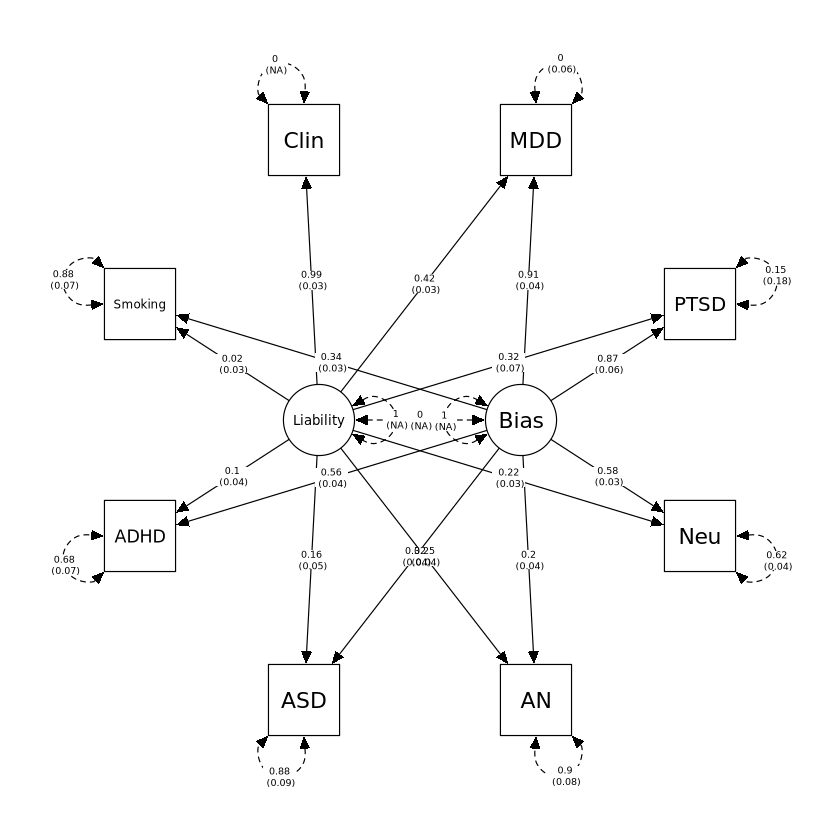

In [141]:
semPaths(two_factors_semobject, layout = "circle", edge.color = "black", sizeMan = 8, sizeLat = 8, nCharNodes = 0, residuals = TRUE, style = "mx",
        edge.label.cex = 0.5,
        esize = 1,
        edgeLabels = est.se)

In [142]:
two_factor_extcorr.fit

$modelfit
      chisq df      p_chisq      AIC       CFI      SRMR
df 194.3449 14 7.831332e-34 238.3449 0.9287744 0.0845053

$results
         lhs op       rhs Unstand_Est          Unstand_SE STD_Genotype
7       Bias =~       MDD 0.202092198  0.0080806689264856    0.9116406
9       Bias =~      PTSD 0.147449835  0.0100593636692212    0.8661571
8       Bias =~       Neu 0.183238955 0.00822496712016979    0.5782818
5       Bias =~        AN 0.075431287  0.0137584697148664    0.1993721
6       Bias =~       ASD 0.099427118  0.0117226487570252    0.3155532
4       Bias =~      ADHD 0.235699522  0.0163687624287238    0.5561219
10      Bias =~   Smoking 0.086096536  0.0075945105115747    0.3423470
17 Liability =~      Clin 0.429043178  0.0127666432394772    0.9911711
18 Liability =~       MDD 0.093881491 0.00760208165163155    0.4203106
20 Liability =~      PTSD 0.054054024  0.0122287115775542    0.3185127
19 Liability =~       Neu 0.070415278  0.0101268587138078    0.2210212
15 Liability =~        AN 0.094520224  0.0153273515487348    0.2493220
16 Liability =~       ASD 0.049080585  0.0159172329573214    0.1565326
14 Liability =~      ADHD 0.041708909  0.0189145464422359    0.0993042
21 Liability =~   Smoking 0.004486300 0.00867291537325953    0.0183736
23       MDD ~~       MDD 0.001000000 0.00275733004565744    0.0010000
1       ADHD ~~      ADHD 0.120778010  0.0129460865617913    0.6808671
2         AN ~~        AN 0.128315848  0.0107480415331777    0.8980890
3        ASD ~~       ASD 0.086093401 0.00924564571041544    0.8759241
24       Neu ~~       Neu 0.061705024 0.00377057508855644    0.6167398
25      PTSD ~~      PTSD 0.004066133 0.00529778191992477    0.1483243
26   Smoking ~~   Smoking 0.055157921 0.00411501003193926    0.8824609
12      Bias ~~ Liability 0.000000000                        0.0000000
13      Clin ~~      Clin 0.000000000                        0.0000000
11      Bias ~~      Bias 1.000000000                        1.0000000
22 Liability ~~ Liability 1.000000000                        1.0000000
      STD_Genotype_SE   STD_All       p_value
7  0.0363582214434662 0.9076784 4.838299e-138
9  0.0591426299710715 0.8661559  1.198041e-48
8  0.0259079099086292 0.5782818 5.988292e-110
5  0.0362448483017816 0.1993722  4.192748e-08
6  0.0372616701216573 0.3155531  2.220691e-17
4  0.0386334729785108 0.5561219  5.223321e-47
10 0.0302413559701663 0.3423470  8.635873e-30
17  0.029479939928665 0.9911711 1.344624e-247
18 0.0339964314108664 0.4184838  4.904846e-35
20 0.0721285943851266 0.3185122  9.858447e-06
19 0.0319729839693862 0.2210212  3.567910e-12
15 0.0405234169817368 0.2493220  6.969982e-10
16 0.0508057823176099 0.1565326  2.045899e-03
14 0.0448048656686447 0.0993042  2.744544e-02
21 0.0346599619878067 0.0183736  6.049628e-01
23 0.0560725079877848 0.0010000  7.168517e-01
1  0.0726407890700665 0.6808671  1.065658e-20
2  0.0751805650074783 0.8980893  7.452604e-33
3  0.0939898943500041 0.8759238  1.257100e-20
24 0.0375686311612787 0.6167398  3.406764e-60
25  0.184137226035743 0.1483239  4.427747e-01
26 0.0657061193412444 0.8824610  5.722899e-41
12                    0.0000000            NA
13                    0.0000000            NA
11                    1.0000000            NA
22                    1.0000000            NA

### Covstruct for selected external phenotype bias gwas

In [143]:
ambivalent_correlation_traits <- c("MDD", "PTSD", "Neu", "AN", "ASD", "ADHD", "Smoking")

#create a path for a covstruct object where you store the covariance structure 
covstruct_ambivalent_correlations_path <- here::here("matrices",paste("Clinical_ambivalent_external", "R", sep = "."))

#extract population prevalence 
pop_prev <- as.vector(all_prevalences[c("Clin", ambivalent_correlation_traits)])
#fill the samp_prev vector depending on the pop_prev vector, if NA use NA and if not use 0.5
samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))
#check if the covstruct file already exists to not do the analysis unnecessarily, first time no file there
paths <- c(samples[1])

for (name in ambivalent_correlation_traits){
    if (name == "MDD"){
        paths <- c(paths, "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz")
        }
    else{
        paths <- c(paths, paste0(other_basepath, name, ".sumstats.gz"))
        }
}

In [144]:
sample_names <- c("Clin", ambivalent_correlation_traits)

In [145]:
if (!file.exists(covstruct_ambivalent_correlations_path)){
    covstruct_ambi_corr_ldsc <- ldsc(
        traits = paths,
        trait.names = sample_names,
        sample.prev = samp_prev,
        population.prev = pop_prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_ambi_corr_ldsc, covstruct_ambivalent_correlations_path, control = c("all", "digits17"))
}

In [146]:
covstruct_ambivalent_correlations <- dget("matrices/Clinical_ambivalent_external.R")

### Sumstats prep for selected external phenotype bias gwas

In [147]:
sumstats_path <- "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/"
ref <- "/local1/scratch/pazweifel/jolien_paper_sumstats/reference.1000G.maf.0.005.txt"

traits <- c("Clin", "MDD", "PTSD", "Neu", "AN", "ASD", "ADHD", "Smoking")
se.logit <- c(T, T, T, F, T, T, T, F)
linprob <- c(F, F, F, T, F,F,F,F)
ols <- c(F, F, F, F, F, F, F, T)
            
path_clin <- paste0(sumstats_path,"BD_Clin.txt")
path_rest <- paste0(sumstats_path, traits[2:length(traits)],".txt")
all_paths <- c(path_clin, path_rest)

In [148]:
all_paths

[1] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/BD_Clin.txt"
[2] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/MDD.txt"    
[3] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/PTSD.txt"   
[4] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/Neu.txt"    
[5] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/AN.txt"     
[6] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/ASD.txt"    
[7] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/ADHD.txt"   
[8] "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/Smoking.txt"

In [149]:
#run the sumstats function
dir.create("bipolar_bias", showWarnings = FALSE)

bip_ambivalent_bias_sumstats_path <- "bipolar_bias/clin_ambivalent_bias_combined_sumstats.R"

if (!file.exists(bip_ambivalent_bias_sumstats_path)){
    bias_sumstats <- sumstats(
             files = all_paths,
             ref = ref,
             trait.names = traits,
             se.logit = se.logit,
             OLS = ols, 
             linprob = linprob,
             parallel = TRUE,
             cores = 10)
    
    saveRDS(bias_sumstats, file = bip_ambivalent_bias_sumstats_path) 
    }
     

In [150]:
sumstats_ambivalent_bias <- readRDS("bipolar_bias/clin_ambivalent_bias_combined_sumstats.R")

In [151]:
nrow(sumstats_ambivalent_bias)

[1] 892245

### GWAS results

In [152]:
bias_gwas <- readRDS("/local1/home/pazweifel/src/bipolar_bias/GWAS_Bias_factor.R")

In [153]:
head(bias_gwas[[1]])

,SNP,CHR,BP,MAF,A1,A2,lhs,op,rhs,free,⋯,est,SE,Z_Estimate,Pval_Estimate,chisq,chisq_df,chisq_pval,AIC,error,warning
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
27,rs6687776,1,1030565,0.1660040,C,T,Bias,~,SNP,8,⋯,-0.004993359,0.01356185,-0.3681916,0.7127304,251.4452,35,1.470821e-34,271.4452,0,0
2789225,rs6678318,1,1030633,0.1660040,G,A,Bias,~,SNP,8,⋯,-0.005098482,0.01366059,-0.3732257,0.7089805,251.5577,35,1.400532e-34,271.5577,0,0
2789230,rs6671356,1,1040026,0.1341950,T,C,Bias,~,SNP,8,⋯,-0.011206577,0.01418265,-0.7901612,0.4294336,252.0724,35,1.119549e-34,272.0724,0,0
2789236,rs6604968,1,1041700,0.1351890,A,G,Bias,~,SNP,8,⋯,-0.012554556,0.01418284,-0.8851937,0.3760522,252.2156,35,1.051918e-34,272.2156,0,0
2789240,rs4970405,1,1048955,0.0994036,A,G,Bias,~,SNP,8,⋯,-0.016680806,0.01664867,-1.0019302,0.3163773,250.1299,35,2.605725e-34,270.1299,0,0
2789248,rs12726255,1,1049950,0.1341950,A,G,Bias,~,SNP,8,⋯,-0.012387897,0.01440024,-0.8602566,0.3896476,252.9177,35,7.749454e-35,272.9177,0,0


In [154]:
bias_gwas_filtered <- bias_gwas[[1]] %>% filter(error == 0 & warning == 0 & Pval_Estimate < 0.1)

In [155]:
nrow(bias_gwas[[1]])
nrow(bias_gwas_filtered)

[1] 892245

[1] 176757

In [156]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





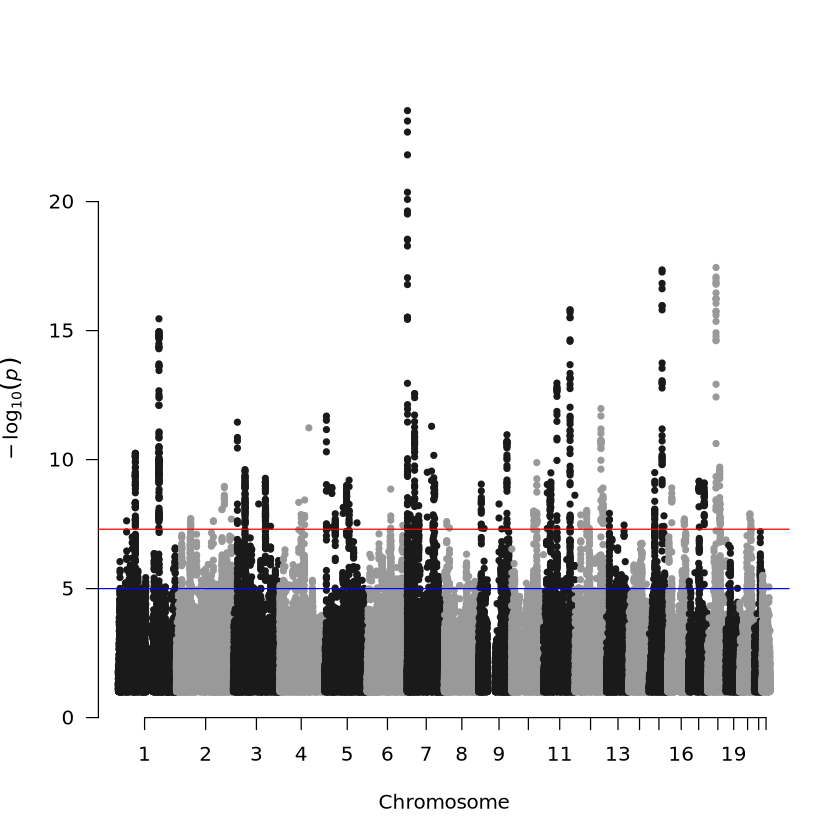

In [157]:
manhattan(bias_gwas_filtered, chr = "CHR", bp = "BP", p = "Pval_Estimate", snp = "SNP")

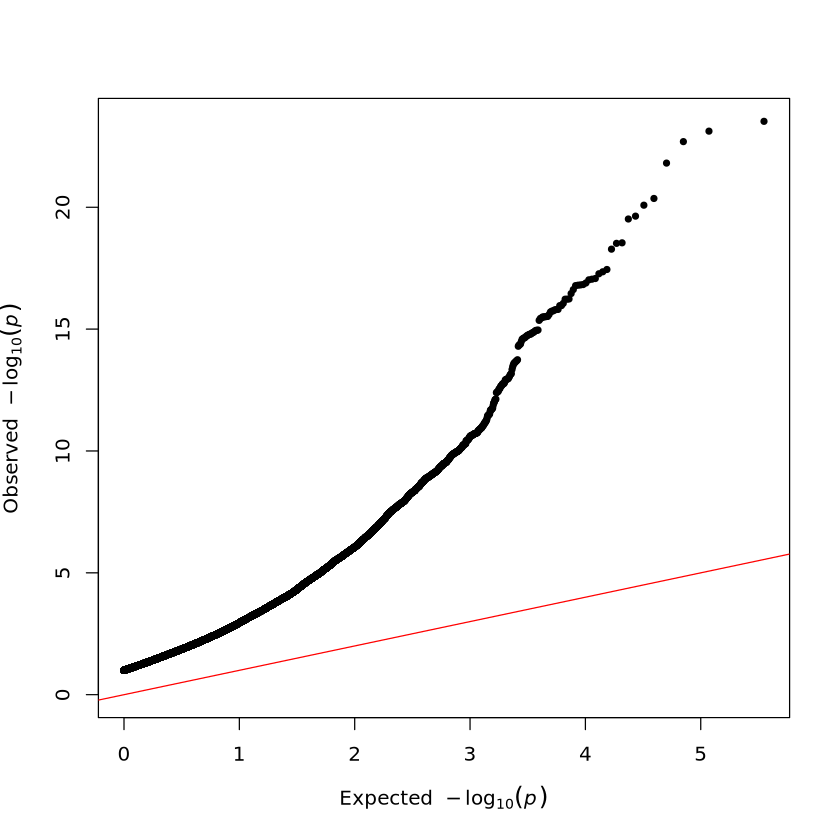

In [158]:
qq(bias_gwas_filtered$Pval_Estimate)

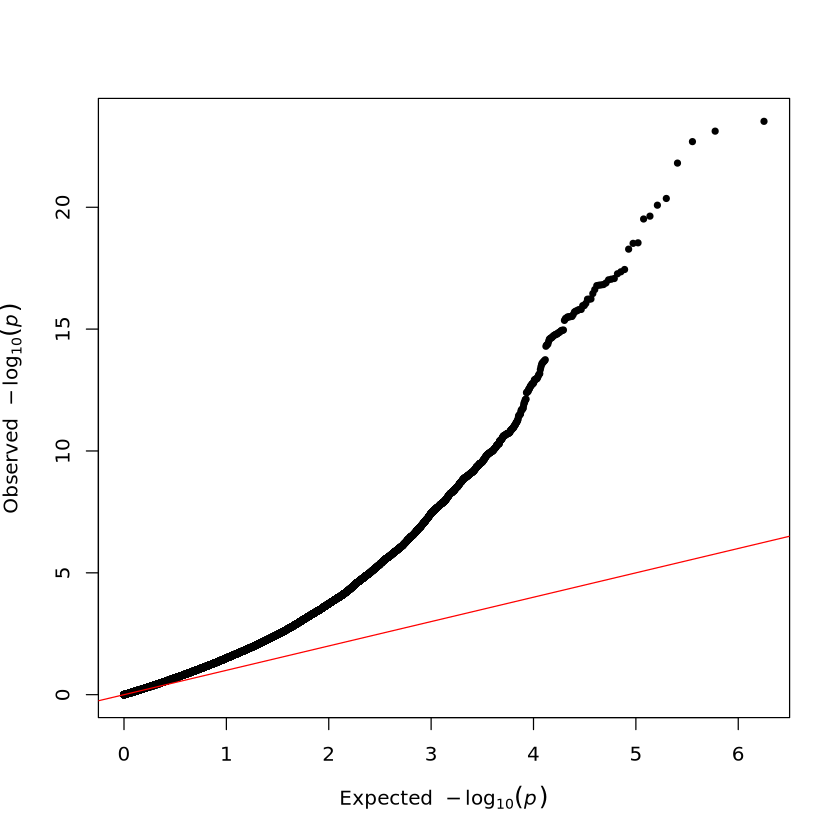

In [159]:
qq(filter(bias_gwas[[1]], warning == 0 & error == 0)$Pval_Estimate)

In [160]:
path_to_plots <- "/local1/home/pazweifel/plots/bip_paper/gwas_bias_factor"

pdf(paste0(path_to_plots, "_manhattan.pdf"), height = 10, width = 12)
manhattan(bias_gwas_filtered, chr = "CHR", bp = "BP", p = "Pval_Estimate", snp = "SNP")
dev.off()

pdf(paste0(path_to_plots, "_qq.pdf"), height = 10, width = 12)
qq(filter(bias_gwas[[1]], warning == 0 & error == 0)$Pval_Estimate)
dev.off()

agg_record_1552920421 
                    2

agg_record_1552920421 
                    2

### Clean and save factor sumstats file

In [161]:
bias_gwas_clean <- filter(bias_gwas[[1]], warning == 0 & error == 0)
head(bias_gwas_clean)

,SNP,CHR,BP,MAF,A1,A2,lhs,op,rhs,free,⋯,est,SE,Z_Estimate,Pval_Estimate,chisq,chisq_df,chisq_pval,AIC,error,warning
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
27,rs6687776,1,1030565,0.1660040,C,T,Bias,~,SNP,8,⋯,-0.004993359,0.01356185,-0.3681916,0.7127304,251.4452,35,1.470821e-34,271.4452,0,0
2789225,rs6678318,1,1030633,0.1660040,G,A,Bias,~,SNP,8,⋯,-0.005098482,0.01366059,-0.3732257,0.7089805,251.5577,35,1.400532e-34,271.5577,0,0
2789230,rs6671356,1,1040026,0.1341950,T,C,Bias,~,SNP,8,⋯,-0.011206577,0.01418265,-0.7901612,0.4294336,252.0724,35,1.119549e-34,272.0724,0,0
2789236,rs6604968,1,1041700,0.1351890,A,G,Bias,~,SNP,8,⋯,-0.012554556,0.01418284,-0.8851937,0.3760522,252.2156,35,1.051918e-34,272.2156,0,0
2789240,rs4970405,1,1048955,0.0994036,A,G,Bias,~,SNP,8,⋯,-0.016680806,0.01664867,-1.0019302,0.3163773,250.1299,35,2.605725e-34,270.1299,0,0
2789248,rs12726255,1,1049950,0.1341950,A,G,Bias,~,SNP,8,⋯,-0.012387897,0.01440024,-0.8602566,0.3896476,252.9177,35,7.749454e-35,272.9177,0,0


In [162]:
#calculate sample size for factor
##Calculate Implied Sample Size for Factor
#restrict to MAF >= 10%

CorrelatedFactors1<-subset(bias_gwas_clean, bias_gwas_clean$MAF >= .1)

N_hat_F1<-mean(1/((2*CorrelatedFactors1$MAF*(1-CorrelatedFactors1$MAF))*CorrelatedFactors1$SE^2))

In [163]:
N_hat_F1

[1] 20970.33

In [164]:
nrow(bias_gwas_clean)

[1] 892233

In [165]:
#prepare the sumstats file for further use in gsem
bias_gwas_gsemready <- bias_gwas_clean %>% rename(Beta = est, P = Pval_Estimate, Z = Z_Estimate) %>% mutate(N = N_hat_F1)

In [166]:
head(bias_gwas_gsemready)

,SNP,CHR,BP,MAF,A1,A2,lhs,op,rhs,free,⋯,SE,Z,P,chisq,chisq_df,chisq_pval,AIC,error,warning,N
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
27,rs6687776,1,1030565,0.1660040,C,T,Bias,~,SNP,8,⋯,0.01356185,-0.3681916,0.7127304,251.4452,35,1.470821e-34,271.4452,0,0,20970.33
2789225,rs6678318,1,1030633,0.1660040,G,A,Bias,~,SNP,8,⋯,0.01366059,-0.3732257,0.7089805,251.5577,35,1.400532e-34,271.5577,0,0,20970.33
2789230,rs6671356,1,1040026,0.1341950,T,C,Bias,~,SNP,8,⋯,0.01418265,-0.7901612,0.4294336,252.0724,35,1.119549e-34,272.0724,0,0,20970.33
2789236,rs6604968,1,1041700,0.1351890,A,G,Bias,~,SNP,8,⋯,0.01418284,-0.8851937,0.3760522,252.2156,35,1.051918e-34,272.2156,0,0,20970.33
2789240,rs4970405,1,1048955,0.0994036,A,G,Bias,~,SNP,8,⋯,0.01664867,-1.0019302,0.3163773,250.1299,35,2.605725e-34,270.1299,0,0,20970.33
2789248,rs12726255,1,1049950,0.1341950,A,G,Bias,~,SNP,8,⋯,0.01440024,-0.8602566,0.3896476,252.9177,35,7.749454e-35,272.9177,0,0,20970.33


In [167]:
data.table::fwrite(x = bias_gwas_gsemready, file = "/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/Ambivalent_correlation_bias_factor.txt", sep = "\t")

### GWAS by subtraction with bias factor GWAS sumstats

In [168]:
gwas_by_sub_model <- "
Liability_clin =~ NA*Clin
Liability_other =~ NA*{internal_trait}
Bias =~ NA*Bias_GWAS + {internal_trait}

Liability_clin ~~ 0*Bias
Liability_other ~~ 0*Bias
Clin ~~ 0*Clin
{internal_trait} ~~ 0*{internal_trait}
Bias_GWAS ~~ 0*Bias_GWAS
Clin ~~ Bias_GWAS
Bias_GWAS ~~ 0*{internal_trait}
Clin ~~ 0*{internal_trait}
"

In [169]:
### create the new covstruct including the bias factor sumstats
covstruct_ambivalent_bias_factor <- "matrices/ambivalent_bias_factor.R"

path_factor <- "/local1/scratch/pazweifel/sumstats_ambits/munged/Ambivalent_correlation_bias_factor.sumstats.gz"

combined_paths <- c(samples, path_factor)

pop.prev <- c(all_prevalences[bip_names], NA)

samp.prev <- c(ifelse(is.na(pop.prev), NA, 0.5))

if (!file.exists(covstruct_ambivalent_bias_factor)){
    covstruct_ambifac <- ldsc(
        traits = combined_paths,
        trait.names = c(bip_names, "Bias_GWAS"),
        sample.prev = samp.prev,
        population.prev = pop.prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_ambifac, covstruct_ambivalent_bias_factor, control = c("all", "digits17"))
}

In [170]:
covstruct_ambivalent_factor <- dget("matrices/ambivalent_bias_factor.R")

In [171]:
gbs_traits <- c("BDII", "Comm")
names(gbs_traits) <- gbs_traits

gwas_by_sub_bias.fit <- lapply(gbs_traits, function(trait){
    internal_trait <- trait

    usermodel(covstruct_ambivalent_factor, estimation = "DWLS", model = str_glue(gwas_by_sub_model), std.lv = TRUE, CFIcalc = TRUE)
})

[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.169 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


Warning message in usermodel(covstruct_ambivalent_factor, estimation = "DWLS", model = str_glue(gwas_by_sub_model), :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(covstruct_ambivalent_factor, estimation = "DWLS", model = str_glue(gwas_by_sub_model), :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


[1] "Running primary model"
[1] "Calculating CFI"
[1] "Calculating Standardized Results"
[1] "Calculating SRMR"
elapsed 
  0.196 
[1] "Model fit statistics are all printed as NA as you have specified a fully saturated model (i.e., df = 0)"


Warning message in usermodel(covstruct_ambivalent_factor, estimation = "DWLS", model = str_glue(gwas_by_sub_model), :
“The unstandardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”
Warning message in usermodel(covstruct_ambivalent_factor, estimation = "DWLS", model = str_glue(gwas_by_sub_model), :
“The standardized model produced the following warning: lavaan->lav_object_post_check():  
   the covariance matrix of the residuals of the observed variables (theta) 
   is not positive definite ; use lavInspect(fit, "theta") to investigate.”


In [172]:
gwas_by_sub_bias.fit[[1]]

$modelfit
   chisq df p_chisq AIC CFI SRMR
df    NA  0      NA  NA  NA   NA

$results
               lhs op             rhs Unstand_Est         Unstand_SE
10  Liability_clin =~            Clin   0.4329692 0.0123219222650867
14 Liability_other =~            BDII   0.2760317 0.0228217567336801
5             Bias =~       Bias_GWAS   1.2685729 0.0287220336099643
4             Bias =~            BDII   0.0809699 0.0156412531674593
8             Clin ~~       Bias_GWAS  -0.0557338 0.0210717290716284
13  Liability_clin ~~ Liability_other   0.9426518 0.0604565947725389
11  Liability_clin ~~            Bias   0.0000000                   
15 Liability_other ~~            Bias   0.0000000                   
9             Clin ~~            Clin   0.0000000                   
1             BDII ~~            BDII   0.0000000                   
3        Bias_GWAS ~~       Bias_GWAS   0.0000000                   
2             BDII ~~       Bias_GWAS   0.0000000                   
7             Clin ~~            BDII   0.0000000                   
12  Liability_clin ~~  Liability_clin   1.0000000                   
16 Liability_other ~~ Liability_other   1.0000000                   
6             Bias ~~            Bias   1.0000000                   
   STD_Genotype    STD_Genotype_SE    STD_All               p_value
10    1.0000000  0.028459117746937  1.0000000 1.76511970347479e-270
14    0.9595684 0.0793352318372153  0.9595684  1.12091042519872e-33
5     1.0000000 0.0226412171796341  1.0000000              < 5e-300
4     0.2814755 0.0543736601472614  0.2814755  2.25858427256398e-07
8    -0.1014720 0.0383643395089106 -0.1014720   0.00817015450585836
13    0.9426518 0.0604565951188601  0.9426518  8.22404529531112e-55
11    0.0000000                     0.0000000                  <NA>
15    0.0000000                     0.0000000                  <NA>
9     0.0000000                     0.0000000                  <NA>
1     0.0000000                     0.0000000                  <NA>
3     0.0000000                     0.0000000                  <NA>
2     0.0000000                     0.0000000                  <NA>
7     0.0000000                     0.0000000                  <NA>
12    1.0000000                     1.0000000                  <NA>
16    1.0000000                     1.0000000                  <NA>
6     1.0000000                     1.0000000                  <NA>

In [173]:
gwas_by_sub_bias.fit[[2]]

$modelfit
   chisq df p_chisq AIC CFI SRMR
df    NA  0      NA  NA  NA   NA

$results
               lhs op             rhs Unstand_Est          Unstand_SE
10  Liability_clin =~            Clin -0.43296923  0.0123219222688567
14 Liability_other =~            Comm  0.23333972  0.0093668376348375
2             Bias =~       Bias_GWAS  1.26857286  0.0287220336303286
3             Bias =~            Comm  0.03523849 0.00897536422112567
5             Clin ~~       Bias_GWAS -0.05573380  0.0210717290716284
13  Liability_clin ~~ Liability_other -0.96225695  0.0463617106982564
11  Liability_clin ~~            Bias  0.00000000                    
15 Liability_other ~~            Bias  0.00000000                    
6             Clin ~~            Clin  0.00000000                    
9             Comm ~~            Comm  0.00000000                    
1        Bias_GWAS ~~       Bias_GWAS  0.00000000                    
8             Comm ~~       Bias_GWAS  0.00000000                    
7             Clin ~~            Comm  0.00000000                    
12  Liability_clin ~~  Liability_clin  1.00000000                    
16 Liability_other ~~ Liability_other  1.00000000                    
4             Bias ~~            Bias  1.00000000                    
   STD_Genotype    STD_Genotype_SE    STD_All               p_value
10    1.0000000 0.0284591177435207  1.0000000 1.76512103815337e-270
14    0.9887882 0.0396924211918574  0.9887882 5.61822945495611e-137
2     1.0000000  0.022641217164332  1.0000000              < 5e-300
3     0.1493248 0.0380335338264063  0.1493248  8.63218010553082e-05
5    -0.1014720 0.0383643395089106 -0.1014720   0.00817015394398823
13    0.9622569 0.0463617107678631  0.9622569  1.09512711289038e-95
11    0.0000000                     0.0000000                  <NA>
15    0.0000000                     0.0000000                  <NA>
6     0.0000000                     0.0000000                  <NA>
9     0.0000000                     0.0000000                  <NA>
1     0.0000000                     0.0000000                  <NA>
8     0.0000000                     0.0000000                  <NA>
7     0.0000000                     0.0000000                  <NA>
12    1.0000000                     1.0000000                  <NA>
16    1.0000000                     1.0000000                  <NA>
4     1.0000000                     1.0000000                  <NA>

In [174]:
bias_corrected_liability_correlations <- bind_rows(
    lapply(gbs_traits, function(trait){
        current_df_line <- gwas_by_sub_bias.fit[[trait]]$results %>% filter(lhs == "Liability_clin", rhs == "Liability_other")
        tibble(External_trait = "Bias_Factor", rg = round(current_df_line$STD_Genotype, 3), se = round(as.double(current_df_line$STD_Genotype_SE), 3), Internal_trait = trait)
        }))

In [175]:
bias_corrected_liability_correlations

External_trait,rg,se,Internal_trait
<chr>,<dbl>,<dbl>,<chr>
Bias_Factor,0.943,0.060,BDII
Bias_Factor,0.962,0.046,Comm


### Preparation for Factor GWAS

In [176]:
#load the non-munged summary stats for which the error are missing and the original summary stats
######original_sumstats <- c("daner_adhd_meta_filtered_NA_iPSYCH23_PGC11_sigPCs_woSEX_2ell6sd_EUR_Neff_70.meta.gz",  "iPSYCH-PGC_ASD_Nov2017.gz",  "PGC3_SCZ_wave3.european.autosome.public.v3.vcf.tsv.gz",  "pgcAN2.2019-07.vcf.tsv.gz",  "pgc-panic2019.vcf.tsv.gz")
#####original_path <- "/local1/scratch/pazweifel/sumstats_ambits/original_sumstats/"
####original_paths <- paste0(original_path, original_sumstats)

###bad_sumstats <- c("ADHD.txt", "ASD.txt", "SCZ.txt", "AN.txt", "PD.txt")
##bad_path <- "/local1/scratch/pazweifel/sumstats_ambits/non_munged/"
#bad_paths <- paste0(bad_path, bad_sumstats)

In [177]:
#names(original_paths) <- c("ADHD", "ASD", "SCZ", "AN", "PD")
###names(bad_paths) <- names(original_paths)traits <- names(bad_paths)
##names(traits) <- traits

##sumstats with overhead
#overhead_sumstats <- c("SCZ", "AN", "PD")

In [178]:
#original_datasets <- lapply(traits, function(trait) {
    ######if (trait %in% overhead_sumstats){
     #####   fread(original_paths[[trait]], skip = "CHROM", data.table = FALSE)
   #### }
    ###else{
       # fread(original_paths[[trait]], data.table = FALSE)
    ##}
   # }
#######)

In [179]:
##bad_datasets <- lapply(traits, function(trait) {
#  #  fread(bad_paths[[trait]], data.table = FALSE)
    #})

In [180]:
#for (trait in bad_datasets){
#    print(nrow(trait))#
#    }

In [181]:
#for (trait in bad_datasets){
#    print("SNP" %in% colnames(trait))
#    }

In [182]:
#for (trait in original_datasets){
#    print("SNP" %in% colnames(trait))
#    }

In [183]:
##check how it is named for the ones not calling it SNP
#head(original_datasets$SCZ)
# its "ID", so rename it
#original_datasets_curated <- lapply(traits, function(trait){
#    if (!("SNP" %in% colnames(original_datasets[[trait]]))){
#        rename(original_datasets[[trait]], SNP = ID)
#    }
#    else{
#        original_datasets[[trait]]
#    }
#    }
#)

In [184]:
#for (trait in original_datasets_curated){
#    print("SNP" %in% colnames(trait))
#    }

In [185]:
#now match on the snp column and combined the bad_one with the original one, so that the new df now also contains the error column
#good_sumstats <- lapply(traits, function(trait) {
#    inner_join(x = bad_datasets[[trait]], y = select(original_datasets_curated[[trait]], SNP, SE), by = join_by(SNP))
#    }
#)

In [186]:
#for (trait in good_sumstats){
#    print(sum(is.na(trait$SE)))
#    }

In [187]:
#for (trait in good_sumstats){
#    print(nrow(trait))
#    }

In [188]:
#for (trait in bad_datasets){
#    print(nrow(trait))
#    }

In [189]:
#head(good_sumstats$AN)

In [190]:
#no NA values in the SE column and all variatns could be assigned a standard error. Now save the corrected summary statistics to a GSEM ready folder.

In [191]:
#new_folder_path <- "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/"
#
#for (trait in traits){
#    write.table(
#        good_sumstats[[trait]],
#        file = paste0(new_folder_path, trait, ".txt"),
#        sep = "\t",
#        col.names = TRUE,
#        row.names = FALSE,
#        quote = FALSE)
#    }

In [192]:
#cleanup of the clinical dataset..

In [193]:
#clinical_bd_bad <- fread("/local1/scratch/pazweifel/heritability_analysis/ldsc_bipolar_comclin/bip2024_eur_clinical_no23andMe_wbeta_use_neff.txt", data.table = FALSE)

In [194]:
#head(clinical_bd_bad)

In [195]:
#clinical_bd_bad_selected <- clinical_bd_bad %>% select(-c(Nca, Nco, N, BETA)) %>% rename(N = NEFF)

In [196]:
#head(clinical_bd_bad_selected)

In [197]:
#clinical_bd_good <- clinical_bd_bad_selected %>% filter(!str_detect(SNP, "^[0-9]"))

In [198]:
#head(clinical_bd_good)
#nrow(clinical_bd_good)
#nrow(clinical_bd_bad)

In [199]:
#clinical_path <- "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/BD_Clin.txt"

#if (!file.exists(clinical_path)){
#    write.table(x = clinical_bd_good,
#                file = clinical_path,
#                sep = "\t",
#                col.names = TRUE,
#                row.names = FALSE,
#                quote = FALSE)
#}

### Calculate the new Covariance matrix with correct order

In [200]:
###calcualte one big covariance matrix involving the clinical bipolar trait and all external ones
#covstruct_bias_selected <- here::here("matrices/Clinical_selected_external.R")

#selected_traits <- c("ADHD", "ALC", "AN", "ASD", "BMI", "CAD", "Chrono", "CRP", "Height", "Neu", "PartEM", "PartMH", "PartSF", "PD", "PTSD", "SCZ", "Smoking", "T2D")

#pop_prev <- c(bip_prevalences["Clin"], other_prevalences[selected_traits])

#samp_prev <- as.vector(ifelse(is.na(pop_prev), NA, 0.5))

#paths <- c(samples[1])
#other_basepath <- "/local1/scratch/pazweifel/sumstats_ambits/munged/"

In [201]:
#names(pop_prev)

In [202]:
#for (name in selected_traits){
#    paths <- c(paths, paste0(other_basepath, name, ".sumstats.gz"))
#}

    
#if (!file.exists(covstruct_bias_selected)){
#    covstruct_bias_selected_ldsc <- ldsc(
#        traits = paths,
#        trait.names = names(pop_prev),
#        sample.prev = samp_prev,
#        population.prev = pop_prev,
#        ld = ld, 
#        wld = weights,
#        stand = TRUE
#        )
#    dput(covstruct_bias_selected_ldsc, covstruct_bias_selected, control = c("all", "digits17"))
#}

In [203]:
#covstruct.bias_selected <- dget("matrices/Clinical_selected_external.R")

In [204]:
#usermodel(covstruc = bias_all.covstruct, estimation = "DWLS", model = model, CFIcalc = TRUE, imp_cov = TRUE)

### Create the combined variant file

In [205]:
#sumstats_path <- "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/"
#ref <- "/local1/scratch/pazweifel/jolien_paper_sumstats/reference.1000G.maf.0.005.txt"

#traits <- c("Clin", "ADHD", "ALC", "AN", "ASD", "BMI", "CAD", "Chrono", "CRP", "Height", "Neu", "PartEM", "PartMH", "PartSF", "PD", "PTSD", "SCZ", "Smoking", "T2D")
#se.logit <- c(T,T,F,T,T,F,T,F,F,F,F,T,T,T,T,T,T,F,T)
#linprob <- c(F,F,T,F,F,F,F,F,F,F,T,F,F,F,F,F,F,F,F)
#ols <- c(F,F,F,F,F,T,F,T,T,T,F,F,F,F,F,F,F,T,F)
#
#path_clin <- paste0(sumstats_path,"BD_Clin.txt")
#path_rest <- paste0(sumstats_path, traits[2:length(traits)],".txt")
#all_paths <- c(path_clin, path_rest)

In [206]:
#run the sumstats function
##dir.create("bipolar_bias", showWarnings = FALSE)

#bip_bias_sumstats_path <- "bipolar_bias/clin_bias_combined_sumstats.R"

#if (!file.exists(bip_bias_sumstats_path)){
#    bias_sumstats <- sumstats(files = all_paths,
#             ref = ref,
#             trait.names = traits,
#             se.logit = se.logit,
#             OLS = ols, 
#             linprob = linprob,
#             parallel = TRUE,
#             cores = 10)
#    
#    saveRDS(bias_sumstats, file = bip_bias_sumstats_path) 
#    }
     

### Create tables for paper

base.fit
anchor.fit
trait_common.fit
trait_independent.fit
their_follow_up_models.fit_adjusted
comm_gwas_by_sub.fits
bdII_gwas_by_sub.fits
two_factor_extcorr.fit
gwas_by_sub_bias.fit

In [207]:
gwas_by_sub_bias.fit[["Comm"]]

$modelfit
   chisq df p_chisq AIC CFI SRMR
df    NA  0      NA  NA  NA   NA

$results
               lhs op             rhs Unstand_Est          Unstand_SE
10  Liability_clin =~            Clin -0.43296923  0.0123219222688567
14 Liability_other =~            Comm  0.23333972  0.0093668376348375
2             Bias =~       Bias_GWAS  1.26857286  0.0287220336303286
3             Bias =~            Comm  0.03523849 0.00897536422112567
5             Clin ~~       Bias_GWAS -0.05573380  0.0210717290716284
13  Liability_clin ~~ Liability_other -0.96225695  0.0463617106982564
11  Liability_clin ~~            Bias  0.00000000                    
15 Liability_other ~~            Bias  0.00000000                    
6             Clin ~~            Clin  0.00000000                    
9             Comm ~~            Comm  0.00000000                    
1        Bias_GWAS ~~       Bias_GWAS  0.00000000                    
8             Comm ~~       Bias_GWAS  0.00000000                    
7             Clin ~~            Comm  0.00000000                    
12  Liability_clin ~~  Liability_clin  1.00000000                    
16 Liability_other ~~ Liability_other  1.00000000                    
4             Bias ~~            Bias  1.00000000                    
   STD_Genotype    STD_Genotype_SE    STD_All               p_value
10    1.0000000 0.0284591177435207  1.0000000 1.76512103815337e-270
14    0.9887882 0.0396924211918574  0.9887882 5.61822945495611e-137
2     1.0000000  0.022641217164332  1.0000000              < 5e-300
3     0.1493248 0.0380335338264063  0.1493248  8.63218010553082e-05
5    -0.1014720 0.0383643395089106 -0.1014720   0.00817015394398823
13    0.9622569 0.0463617107678631  0.9622569  1.09512711289038e-95
11    0.0000000                     0.0000000                  <NA>
15    0.0000000                     0.0000000                  <NA>
6     0.0000000                     0.0000000                  <NA>
9     0.0000000                     0.0000000                  <NA>
1     0.0000000                     0.0000000                  <NA>
8     0.0000000                     0.0000000                  <NA>
7     0.0000000                     0.0000000                  <NA>
12    1.0000000                     1.0000000                  <NA>
16    1.0000000                     1.0000000                  <NA>
4     1.0000000                     1.0000000                  <NA>

In [208]:
traits <- other_names
names(traits) <- traits
traits

ADHD       ALC        AN       ASD       MDD       BMI       CAD    Chrono 
   "ADHD"     "ALC"      "AN"     "ASD"     "MDD"     "BMI"     "CAD"  "Chrono" 
      CRP    Height       Neu        PD      PTSD       SCZ   Smoking       T2D 
    "CRP"  "Height"     "Neu"      "PD"    "PTSD"     "SCZ" "Smoking"     "T2D" 
   PartEM    PartMH    PartSF 
 "PartEM"  "PartMH"  "PartSF"

In [209]:
base.results.table <- mutate(tibble(base.fit$results), Model = "Base", External_phenotype = "None", p_value = as.character(p_value)) %>% relocate(Model, External_phenotype)

base.modelfit.table <- mutate(tibble(base.fit$modelfit), Model = "Base", External_phenotype = "None") %>% relocate(Model, External_phenotype)

In [210]:
anchor.results.table <- mutate(tibble(anchor.fit$results), Model = "Anchor", External_phenotype = "None", p_value = as.character(p_value)) %>% relocate(Model, External_phenotype)

anchor.modelfit.table <- mutate(tibble(anchor.fit$modelfit), Model = "Anchor", External_phenotype = "None") %>% relocate(Model, External_phenotype)

In [211]:
trait_common.results.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- trait_common.fit[[trait]]$results
        mutate(tibble(temp), Model = "Common", External_phenotype = trait, p_value = as.character(temp$p_value)) %>% relocate(Model, External_phenotype)
        }))

trait_common.modelfit.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- trait_common.fit[[trait]]$modelfit
        mutate(tibble(temp), Model = "Common", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        }))

In [212]:
nrow(trait_common.results.table)

[1] 209

In [213]:
trait_independent.results.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- trait_independent.fit[[trait]]$results
        mutate(tibble(temp), Model = "Independent", External_phenotype = trait, p_value = as.character(temp$p_value)) %>% relocate(Model, External_phenotype)
        }))

trait_independent.modelfit.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- trait_independent.fit[[trait]]$modelfit
        mutate(tibble(temp), Model = "Independent", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        }))

In [214]:
follow_up_names <- names(their_follow_up_models.fit_adjusted)
names(follow_up_names) <- follow_up_names

In [215]:
trait_follow_up.results.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- their_follow_up_models.fit_adjusted[[trait]]$results
        mutate(tibble(temp), Model = "Follow-up", External_phenotype = trait, p_value = as.character(temp$p_value)) %>% relocate(Model, External_phenotype)
        }))

trait_follow_up.modelfit.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- their_follow_up_models.fit_adjusted[[trait]]$modelfit
        mutate(tibble(temp), Model = "Follow-up", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        }))

In [216]:
comm_mask <- sapply(comm_gwas_by_sub.fits, is.null)
comm_gwas_by_sub.fits.filtered <- comm_gwas_by_sub.fits[!comm_mask]

In [217]:
comm_gwasbysub.results.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- comm_gwas_by_sub.fits.filtered[[trait]]$results
        mutate(tibble(temp), p_value = as.character(temp$p_value), Model = "Comm_GWAS_by_sub", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        
        }))

comm_gwasbysub.modelfit.table <- bind_rows(
    lapply(traits, function(trait){

        temp <- comm_gwas_by_sub.fits[[trait]]$modelfit
        mutate(tibble(temp), Model = "Comm_GWAS_by_sub", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        
        }))

In [218]:
bdII_mask <- sapply(bdII_gwas_by_sub.fits, is.null)
bdII_gwas_by_sub.fits.filtered <- bdII_gwas_by_sub.fits[!bdII_mask]

In [219]:
bdII_gwasbysub.results.table <- bind_rows(
    lapply(traits, function(trait){
        temp <- bdII_gwas_by_sub.fits.filtered[[trait]]$results
        mutate(tibble(temp), p_value = as.character(temp$p_value), Model = "BDII_GWAS_by_sub", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        
        }))

bdII_gwasbysub.modelfit.table <- bind_rows(
    lapply(traits, function(trait){

        temp <- bdII_gwas_by_sub.fits.filtered[[trait]]$modelfit
        mutate(tibble(temp), Model = "BDII_GWAS_by_sub", External_phenotype = trait) %>% relocate(Model, External_phenotype)
        
        }))

In [220]:
common_bias.results.table <- mutate(tibble(two_factor_extcorr.fit$results), Model = "Common_bias", External_phenotype = "None", p_value = as.character(p_value)) %>% relocate(Model, External_phenotype)

common_bias.modelfit.table <- mutate(tibble(two_factor_extcorr.fit$modelfit), Model = "Common_bias", External_phenotype = "None") %>% relocate(Model, External_phenotype)

In [221]:
com_bias.traits <- names(gwas_by_sub_bias.fit)
names(com_bias.traits) <- com_bias.traits

In [222]:
common_bias_gwasbysub.results.table <- bind_rows(
    lapply(com_bias.traits, function(trait){
        temp <- gwas_by_sub_bias.fit[[trait]]$results
        mutate(tibble(temp), p_value = as.character(temp$p_value), Model = paste0(trait,"_GWAS_by_sub"), External_phenotype = "Common_Bias") %>% relocate(Model, External_phenotype)
        
        }))

common_bias_gwasbysub.modelfit.table <- bind_rows(
    lapply(com_bias.traits, function(trait){

        temp <- gwas_by_sub_bias.fit[[trait]]$modelfit
        mutate(tibble(temp), Model = paste0(trait,"_GWAS_by_sub"), External_phenotype = "Common_Bias") %>% relocate(Model, External_phenotype)
        
        }))

In [223]:
combined.table.results.goodies <- bind_rows(base.results.table,
                                    anchor.results.table,
                                    trait_common.results.table,
                                    trait_independent.results.table,
                                    trait_follow_up.results.table,
                                    common_bias.results.table)

combined.table.results.badies <- bind_rows(comm_gwasbysub.results.table,
                                           bdII_gwasbysub.results.table,
                                           common_bias_gwasbysub.results.table)
    

In [224]:
combined.table.results <- bind_rows(combined.table.results.goodies, combined.table.results.badies) %>% mutate(op = paste0("`", op))

In [225]:
head(combined.table.results)

Model,External_phenotype,lhs,op,rhs,Unstand_Est,Unstand_SE,STD_Genotype,STD_Genotype_SE,STD_All,p_value
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
Base,None,BD,`=~,Clin,0.437244488,0.0132666812073236,1.0038839,0.030452824624281,1.0038839,3.23950342790449e-238
Base,None,BD,`=~,Comm,0.222550644,0.0107035722732005,0.9411593,0.0452655874835151,0.9411593,5.09389955132504e-96
Base,None,BD,`=~,BDI,0.347975938,0.0108876974489879,0.9613993,0.0300815557844358,0.9613993,3.86492239989597e-224
Base,None,BD,`=~,BDII,0.259795073,0.0161819761794392,0.9026899,0.0562267964986999,0.9026899,5.30843320096865e-58
Base,None,Clin,`~~,Clin,0.000100000,0.0059768042373838,0.0001000,0.0315011407299536,0.0001000,0.986650937452484
Base,None,Comm,`~~,Comm,0.006381599,0.00436246046159522,0.1142192,0.0780207353579752,0.1142192,0.14351009879239


In [226]:
write_csv(combined.table.results, file = "/local1/home/pazweifel/plots/bip_paper/combined.results.table.csv")

In [227]:
combined.table.modelfit.goodies <- bind_rows(base.modelfit.table,
                                    anchor.modelfit.table,
                                    trait_common.modelfit.table,
                                    trait_independent.modelfit.table,
                                    trait_follow_up.modelfit.table,
                                    common_bias.modelfit.table)

combined.table.modelfit.badies <- bind_rows(comm_gwasbysub.modelfit.table,
                                           bdII_gwasbysub.modelfit.table,
                                           common_bias_gwasbysub.modelfit.table)
    

In [228]:
combined.table.modelfit <- bind_rows(combined.table.modelfit.goodies, combined.table.modelfit.badies)

In [229]:
write_csv(x = combined.table.modelfit, file = "/local1/home/pazweifel/plots/bip_paper/combined.modelfit.table.csv")

In [230]:
combined.table.modelfit

Model,External_phenotype,chisq,df,p_chisq,AIC,CFI,SRMR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Base,None,7.353786,2,2.530147e-02,23.35379,0.9988052,0.02269718
Anchor,None,7.353768,2,2.530169e-02,23.35377,0.9988052,0.02269717
Common,ADHD,41.063092,5,9.111411e-08,61.06309,0.9922649,0.06341767
Common,ALC,10.502388,5,6.218925e-02,30.50239,0.9987970,0.03479384
Common,AN,26.107445,5,8.505453e-05,46.10745,0.9954364,0.03535471
Common,ASD,30.336535,5,1.266121e-05,50.33653,0.9944894,0.05107370
Common,MDD,240.220475,5,6.885456e-50,260.22048,0.9527949,0.08600308
Common,BMI,17.830075,5,3.167083e-03,37.83007,0.9971767,0.02803427
Common,CAD,35.755458,5,1.063013e-06,55.75546,0.9931615,0.04764801


In [231]:
follow_up_phenos <- filter(combined.table.modelfit, Model == "Follow-up")$External_phenotype

temp <- combined.table.modelfit %>% filter(External_phenotype %in% follow_up_phenos & (Model == "Follow-up" | Model == "Independent" | Model == "Common")) %>% select(-c(chisq, df, p_chisq, AIC)) %>% arrange(External_phenotype) 

paper_table <- temp %>%
  select(Model, External_phenotype, CFI, SRMR) %>%   # drop AIC
  pivot_longer(cols = c(CFI, SRMR),
               names_to = "Metric",
               values_to = "Value") %>%
  mutate(
    Model = factor(Model, levels = c("Common", "Independent", "Follow-up")),
    Metric = factor(Metric, levels = c("CFI", "SRMR")),
    Value = round(Value, 3)
  ) %>%
  pivot_wider(names_from = Model, values_from = Value) %>%
  arrange(External_phenotype, Metric)

paper_table

External_phenotype,Metric,Common,Independent,Follow-up
<chr>,<fct>,<dbl>,<dbl>,<dbl>
ADHD,CFI,0.992,0.999,0.999
ADHD,SRMR,0.063,0.019,0.013
AN,CFI,0.995,0.999,0.998
AN,SRMR,0.035,0.019,0.030
ASD,CFI,0.994,0.999,0.999
ASD,SRMR,0.051,0.019,0.015
MDD,CFI,0.953,0.999,0.998
MDD,SRMR,0.086,0.019,0.011
Neu,CFI,0.982,0.999,0.999


In [232]:
write_csv(file = "/local1/home/pazweifel/plots/bip_paper/follow_up_table.csv", x = paper_table, col_names = TRUE)

In [233]:
follow_up_table_adjusted

,Trait,rGF1Trait_CPM,SErGF1Trait_CPM,pvalrGF1Trait_CPM,rGF1Trait_significat_CPM,QTrait_CPM,df_CPM,p_value_CPM,Qsignificant_CPM,lSRMR_CPM,⋯,pvalrGF1Trait_FUM,rGF1Trait_significat_FUM,QTrait_FUM,df_FUM,p_value_FUM,Qsignificant_FUM,lSRMR_FUM,lSRMR_above_threshold_FUM,heterogeneity_FUM,Unconstrained_paths
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
ADHD,ADHD,0.20207690,0.04166307,1.232970e-06,*,18.988517,3,2.748977e-04,*,0.12115231,⋯,1.930875e-03,*,2.781940,1,0.09533262,NS,0.015019621,No,No,"BDII,Comm"
AN,AN,0.23074782,0.03704739,4.710703e-10,*,8.636123,3,3.454125e-02,*,0.06242593,⋯,3.179615e-08,*,1.704904,2,0.42636815,NS,0.049031017,No,No,Comm
ASD,ASD,0.20630098,0.04708236,1.177543e-05,*,12.570177,3,5.664633e-03,*,0.09544419,⋯,7.732356e-04,*,2.011669,1,0.15609350,NS,0.014673658,No,No,"BDII,Comm"
MDD,MDD,0.49773796,0.03098105,4.424979e-58,*,68.588403,3,8.560160e-15,*,0.17351999,⋯,1.220914e-35,*,2.388206,1,0.12225383,NS,0.047724207,No,No,"BDII,Comm"
Neu,Neu,0.22202042,0.02660110,7.044157e-17,*,45.176291,3,8.487918e-10,*,0.12166932,⋯,4.903826e-08,*,4.213571,1,0.04010182,*,0.009329146,No,No,"BDII,Comm"
Smoking,Smoking,0.09672052,0.03073280,1.648740e-03,*,20.467339,3,1.357970e-04,*,0.09645885,⋯,1.373443e-01,NS,3.252120,1,0.07133114,NS,0.009136744,No,No,"BDII,Comm"


### S-LDSC enrich and comparison

In [234]:
#load the s-ldsc covstruct
sldsc_covstruct <- readRDS("S_LDSC_community_liability_Neu.RData")

In [235]:
#specify the model syntax for a common factor model
model<-"
Liability_clin =~ NA*Clin
Liability_comm =~ NA*Comm
Bias =~ NA*Neu + Comm

Liability_clin ~~ 0*Bias
Liability_comm ~~ 0*Bias
Clin ~~ 0*Clin
Comm ~~ 0*Comm
Neu ~~ 0*Neu
Clin ~~ Neu
Neu ~~ 0*Comm
Clin ~~ 0*Comm
"

#specify the F1 factor variance as the parameter of interest
params<-c("Liability_comm~~Liability_comm")

#use unit variance identification
std.lv=TRUE

#estimate enrichment using the enrich function
#enrich_gwasbysub<-enrich(s_covstruc=sldsc_covstruct,model=model,params=params,std.lv=std.lv)

In [236]:
#specify the model syntax for a common factor model
model<-"
Liability_clin =~ NA*Clin
"

#specify the F1 factor variance as the parameter of interest
params<-c("Liability_clin~~Liability_clin")

#use unit variance identification
std.lv=TRUE

#estimate enrichment using the enrich function
#enrich_clin<-enrich(s_covstruc=sldsc_covstruct,model=model,params=params,std.lv=std.lv)

### Prepare the GWASbySub factors for LDSC by creating a suitable summary file

In [237]:
gwasbysub_gwas <- readRDS("bipolar_bias/GWAS_Comm_liability.R")

In [238]:
##Calculate Implied Sample Size for Factor
#restrict to MAF >= 10%
gwasbysub_gwas_N <- lapply(gwasbysub_gwas, function(gwas){
        subby<-subset(gwas, gwas$MAF >= .1)
        
        N_hat_F1<-round(mean(1/((2*subby$MAF*(1-subby$MAF))*subby$SE^2)), 0)
        mutate(tibble(gwas), N = N_hat_F1) %>% rename(P = Pval_Estimate, Z = Z_Estimate, Beta = est) %>% select(SNP, CHR, BP, MAF, A1, A2, Beta, SE, Z, P, N)
    })

In [239]:
path <- "../plots/bip_paper/gwasbysub_bias_factor_neuro_manhattan.pdf"

if (!file.exists(path)){
    pdf(file = path)
    manhattan(gwasbysub_gwas[[1]], chr = "CHR", snp = "SNP", p = "Pval_Estimate", bp = "BP")
    dev.off()
    }

In [240]:
path <- "../plots/bip_paper/gwasbysub_community_factor_neuro_manhattan.pdf"
if (!file.exists(path)){
    pdf(file = path)
    manhattan(gwasbysub_gwas[[2]], chr = "CHR", snp = "SNP", p = "Pval_Estimate", bp = "BP")
    dev.off()
    }

In [241]:
path <- "../plots/bip_paper/gwasbysub_clinical_factor_neuro_manhattan.pdf"
if (!file.exists(path)){
    pdf(file = path)
    manhattan(gwasbysub_gwas[[3]], chr = "CHR", snp = "SNP", p = "Pval_Estimate", bp = "BP")
    dev.off()
    }

In [242]:
gwasbysub_filepaths <- c("/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/gwasbysub_neuro_bias.tsv", "/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/gwasbysub_neuro_community_liab.tsv", "/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/gwasbysub_neuro_clinical_liab.tsv")

for (i in c(1:length(gwasbysub_gwas_N))){
    if (!file.exists(gwasbysub_filepaths[i])){
        write_tsv(gwasbysub_gwas_N[[i]], file = gwasbysub_filepaths[i])
        }}

In [243]:
head(gwasbysub_gwas_N[[3]])

SNP,CHR,BP,MAF,A1,A2,Beta,SE,Z,P,N
<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs6689308,1,1029805,0.166998,A,G,-0.006779278,0.01022746,-0.6628507,0.5074262,41685
rs6687776,1,1030565,0.166004,C,T,-0.005842609,0.01022774,-0.5712510,0.5678295,41685
rs6678318,1,1030633,0.166004,G,A,-0.005792468,0.01022776,-0.5663479,0.5711573,41685
rs6671356,1,1040026,0.134195,T,C,-0.006562029,0.01063004,-0.6173099,0.5370303,41685
rs6604968,1,1041700,0.135189,A,G,-0.006288687,0.01063005,-0.5915951,0.5541218,41685
rs12726255,1,1049950,0.134195,A,G,-0.007058890,0.01068750,-0.6604808,0.5089453,41685


### Plotting SLDSC results

In [244]:
cluster_annotations <- read.xlsx("bipolar_bias/cluster_annotations.xlsx") %>% mutate(Name = as.character(Cluster.ID)) %>% select(-c(Cluster.ID))

In [245]:
head(cluster_annotations)

,Cluster.name,Supercluster,Class.auto-annotation,Neurotransmitter.auto-annotation,Neuropeptide.auto-annotation,Subtype.auto-annotation,Transferred.MTG.Label,Top.three.regions,Top.three.dissections,Top.Enriched.Genes,⋯,Total.UMI,Fraction.unspliced,Fraction.mitochondrial,H19.30.002,H19.30.001,H18.30.002,H18.30.001,Fraction.cells.from.top.donor,Number.of.donors,Name
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Bcell_0,Miscellaneous,BCELL,NA,NA,NA,N/A,"Midbrain: 21.0%, Basal forebrain: 19.0%, Pons: 14.3%","Human GPi: 11.4%, Human SN: 11.4%, Human SN-RN: 4.8%","IGHM, MS4A1, FCRL1, AC244205.1, IGLL5, IGHA1, BLK, IGLC3, IGLC2, IKZF3",⋯,2258.867,0.6081129,0.020988592,58,20,27,0,0.5523810,3,0
2,Tcell_1,Miscellaneous,TCELL,NA,NA,NA,N/A,"Midbrain: 15.0%, Basal forebrain: 14.0%, Pons: 13.2%","Human SpC: 8.2%, Human CbDN: 7.6%, Human SN: 7.4%","CD2, IL7R, PTPRC, SLFN12L, IL32, CCL5, GRAP2, RUNX3, CD69, CD3E",⋯,2184.314,0.5828840,0.021212410,708,400,1364,2,0.5513339,4,1
3,Nkcell_2,Miscellaneous,NK,NA,NA,NA,N/A,"Thalamus: 17.6%, Cerebral cortex: 15.5%, Basal forebrain: 14.8%","Human GPe: 5.7%, Human GPi: 5.5%, Human CbDN: 5.1%","NKG7, GNLY, PRF1, KLRF1, PYHIN1, CCL4, RUNX3, CST7, GZMA, GZMB",⋯,2263.349,0.5582284,0.020092552,245,126,300,0,0.4470939,3,2
4,Mono_3,Miscellaneous,MONO,NA,NAMPT,NA,N/A,"Thalamus: 21.9%, Pons: 16.1%, Basal forebrain: 13.9%","Human PnEN: 8.9%, Human MoAN: 6.6%, Human PnRF: 3.8%","FCN1, CLEC12A, S100A4, TNFRSF1B, IFI30, LYZ, CYTIP, FGR, LILRB2, KYNU",⋯,2407.775,0.5696419,0.051116823,195,112,196,0,0.3896620,3,3
5,Mgl_4,Microglia,MGL,NA,NAMPT,NA,Micro-PVM,"Spinal cord: 31.8%, Pons: 26.0%, Medulla: 13.2%","Human SpC: 31.8%, Human MN: 11.5%, Human PnEN: 11.4%","SRGN, RGS1, GPR183, CD69, HLA-DRA, OLR1, TNFRSF1B, IFI30, CXCR4, CD74",⋯,2439.644,0.6722630,0.005220894,176,135,434,0,0.5825503,3,4
6,Mgl_5,Microglia,MGL,NA,NA,NA,Micro-PVM,"Hippocampus: 40.4%, Medulla: 29.6%, Basal forebrain: 20.1%","Human MoAN: 26.6%, Human DGR-CA4Rpy: 25.2%, Human SEP: 18.8%","HLA-DRA, TTR, CD74, HLA-DRB1, SRGN, RGS1, HLA-DPA1, MS4A6A, HLA-DQA1, HLA-DRB5",⋯,2327.416,0.6150336,0.015576116,57,534,186,0,0.6872587,3,5


In [246]:
annotation_order_data_labels <- c(
  "Miscellaneous",
  "Microglia",
  "Vascular",
  "Fibroblast",
  "Oligodendrocyte precursor",
  "Committed oligodendrocyte precursor",
  "Oligodendrocyte",
  "Bergmann glia",
  "Astrocyte",
  "Ependymal",
  "Choroid plexus",
  "Deep-layer near-projecting",
  "Deep-layer corticothalamic and 6b",
  "Hippocampal CA1-3",
  "Upper-layer intratelencephalic",
  "Deep-layer intratelencephalic",
  "Amygdala excitatory",
  "Hippocampal CA4",
  "Hippocampal dentate gyrus",
  "Medium spiny neuron",
  "Eccentric medium spiny neuron",
  "Splatter",
  "MGE interneuron",
  "LAMP5-LHX6 and Chandelier",
  "CGE interneuron",
  "Upper rhombic lip",
  "Cerebellar inhibitory",
  "Lower rhombic lip",
  "Mammillary body",
  "Thalamic excitatory",
  "Midbrain-derived inhibitory"
)



In [247]:
#load the data
samples <- c("Clinical", "Liability_clinical", "Liability_Community", "Community", "Bias_Neuro")
names(samples) <- samples

pathlist <- c("bipolar_bias/Clinical_sldsc.h2.cell_type_results.txt", "bipolar_bias/gwasbysub_neuro_clinical_liab.h2.cell_type_results.txt", "bipolar_bias/gwasbysub_neuro_community_liab.h2.cell_type_results.txt", "bipolar_bias/Community_sldsc.h2.cell_type_results.txt", "bipolar_bias/gwasbysub_neuro_bias.h2.cell_type_results.txt")
names(pathlist) <- c("Clinical", "Liability_clinical", "Liability_Community", "Community", "Bias_Neuro")

enrich_table <- bind_rows(lapply(samples, function(sample){
    a <- read_table(pathlist[sample])
    a %>% mutate(Phenotype = sample, Name = str_remove(Name, pattern = "Cluster"), Bonfer = Coefficient_P_value*nrow(a), sign = Bonfer < 0.05, BH = p.adjust(Coefficient_P_value, method = "fdr")) %>% left_join(y = cluster_annotations, by = "Name") %>% mutate(Supercluster= factor(Supercluster, levels = annotation_order_data_labels)) %>% arrange(Supercluster, Name)
    })) %>% mutate(Phenotype = factor(Phenotype, levels = unique(Phenotype)), Name = factor(Name, levels = unique(Name))) 


── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_s

In [248]:
head(enrich_table)

Name,Coefficient,Coefficient_std_error,Coefficient_P_value,Phenotype,Bonfer,sign,BH,Cluster.name,Supercluster,⋯,DoubletFinder.score,Total.UMI,Fraction.unspliced,Fraction.mitochondrial,H19.30.002,H19.30.001,H18.30.002,H18.30.001,Fraction.cells.from.top.donor,Number.of.donors
<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<lgl>,<dbl>,<chr>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,-6.703470e-09,6.445812e-09,0.850823761,Clinical,392.229754,FALSE,0.99999060,Bcell_0,Miscellaneous,⋯,0.01335801,2258.867,0.6081129,0.020988592,58,20,27,0,0.5523810,3
1,2.253130e-09,7.130042e-09,0.375999286,Clinical,173.335671,FALSE,0.72879730,Tcell_1,Miscellaneous,⋯,0.02237083,2184.314,0.5828840,0.021212410,708,400,1364,2,0.5513339,4
113,1.935042e-08,7.792516e-09,0.006510298,Clinical,3.001247,FALSE,0.04840721,L5ET_113,Miscellaneous,⋯,0.05838341,34997.159,0.7076904,0.001962773,179,87,363,1,0.5761905,4
114,5.567357e-09,6.857494e-09,0.208434645,Clinical,96.088371,FALSE,0.52221941,L5ET_114,Miscellaneous,⋯,0.15461957,44164.402,0.7043433,0.004051415,235,203,476,1,0.5202186,4
116,1.033780e-08,6.734198e-09,0.062377313,Clinical,28.755941,FALSE,0.23190275,Misc_116,Miscellaneous,⋯,0.10091509,43364.541,0.7237284,0.003902777,468,293,580,0,0.4325130,3
117,1.337796e-08,6.863723e-09,0.025642845,Clinical,11.821351,FALSE,0.12443528,L5ET_117,Miscellaneous,⋯,0.06258908,49616.195,0.7426846,0.005575297,948,526,1181,0,0.4448211,3


In [249]:
#add a shape column to make the legend more interpretable
x <- rep(x = c(0:5), length.out = 31)
names(x) <- annotation_order_data_labels

enrich_table <- enrich_table %>% mutate(shape = x[Supercluster])

In [250]:
p_cut <- max(enrich_table$Coefficient_P_value[enrich_table$BH <= 0.05], na.rm = TRUE)

library(Polychrome)
cluster_cols <- setNames(
  Polychrome::palette36.colors(31),
  levels(enrich_table$Supercluster)
)

enrich_table$Phenotype <- recode(enrich_table$Phenotype, Liability_clinical = "Liability[BD]", Liability_Community = "Liability[Comm]", Bias_Neuro = "Bias[Neu]")

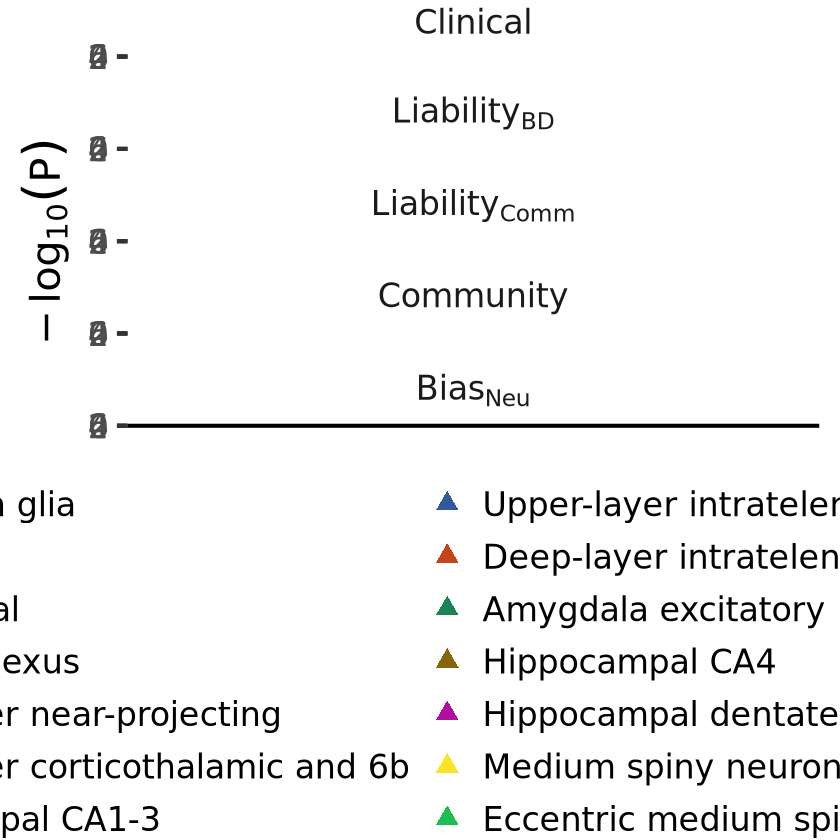

In [317]:
sldsc_plot <- ggplot(enrich_table, aes(x = Name, y = -log10(Coefficient_P_value))) +
geom_point(aes(color = Supercluster), size = 4, shape = 17) +
scale_color_manual(values = cluster_cols) +
geom_hline(yintercept = -log10(0.05/length(unique(enrich_table$Name))), color = "red", linetype = "dashed") +
geom_hline(yintercept = -log10(p_cut), color = "blue", linetype = "dashed") +
labs(y = expression(-log[10](P)), color = "Category") + 
facet_wrap(vars(Phenotype), nrow = 5, labeller = label_parsed) +
theme_bw(base_size = 25) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_blank(), axis.ticks.x = element_blank(),
strip.background = element_blank(), strip.placement = "outside", axis.title.x = element_blank(), legend.position = "bottom") 

sldsc_plot

In [252]:
ggsave("/local1/home/pazweifel/plots/bip_paper/sldsc_combined.pdf", plot = sldsc_plot, device = "pdf", width = 30, height = 20)

### Factor GWAS GWASbysub with bias factor

In [253]:
samples <- c("/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_clinical_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_community_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDI_cleaned_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDII_cleaned_neff.sumstats.gz")

In [254]:
### create the new covstruct including the bias factor sumstats
covstruct_ambivalent_bias_factor_2 <- "matrices/ambivalent_bias_factor_clin_com.R"
orig_names <- c("Clin", "Comm")
path_factor <- "/local1/scratch/pazweifel/sumstats_ambits/munged/Ambivalent_correlation_bias_factor.sumstats.gz"

combined_paths <- c(samples[1:2], path_factor)

pop.prev <- c(all_prevalences[orig_names], NA)

samp.prev <- c(ifelse(is.na(pop.prev), NA, 0.5))

if (!file.exists(covstruct_ambivalent_bias_factor_2)){
    covstruct_ambifac <- ldsc(
        traits = combined_paths,
        trait.names = c(orig_names, "Combined_Bias"),
        sample.prev = samp.prev,
        population.prev = pop.prev,
        ld = ld,
        wld = weights,
        stand = TRUE
    )
    #store the file in the previously defined path, now the path is, contorl tell how to deparse
    dput(covstruct_ambifac, covstruct_ambivalent_bias_factor_2, control = c("all", "digits17"))
}

In [255]:
sumstats_path <- "/local1/scratch/pazweifel/sumstats_ambits/gsem_ready/"
factor_path <- "/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/Ambivalent_correlation_bias_factor.txt"
ref <- "/local1/scratch/pazweifel/jolien_paper_sumstats/reference.1000G.maf.0.005.txt"

traits <- c("Clin", "Comm", "Combined_Bias")
se.logit <- c(T, T, F)
linprob <- c(F, F, F)
ols <- c(F, F, T)
            
path_clin <- paste0(sumstats_path,"BD_Clin.txt")
path_comm <- paste0(sumstats_path, "Comm.txt")
all_paths <- c(path_clin, path_comm, factor_path)

In [256]:
#run the sumstats function
dir.create("bipolar_bias", showWarnings = FALSE)

bip_ambivalent_bias_sumstats_path <- "bipolar_bias/clin_comm_combinedbias_sumstats.R"

if (!file.exists(bip_ambivalent_bias_sumstats_path)){
    bias_sumstats <- sumstats(
             files = all_paths,
             ref = ref,
             trait.names = traits,
             se.logit = se.logit,
             OLS = ols, 
             linprob = linprob,
             parallel = TRUE,
             cores = 3)
    
    saveRDS(bias_sumstats, file = bip_ambivalent_bias_sumstats_path) 
    }
     

### Check the GWAS results and prep the sumstats for munging and ldsc

In [257]:
combi_factors <- readRDS("bipolar_bias/GWAS_combined_bias_comm_liability.R")

In [258]:
##Calculate Implied Sample Size for Factor
#restrict to MAF >= 10%
gwasbysub_gwas_N <- lapply(combi_factors, function(gwas){
        subby<-subset(gwas, gwas$MAF >= .1)
        
        N_hat_F1<-round(mean(1/((2*subby$MAF*(1-subby$MAF))*subby$SE^2)), 0)
        mutate(tibble(gwas), N = N_hat_F1) %>% rename(P = Pval_Estimate, Z = Z_Estimate, Beta = est) %>% select(SNP, CHR, BP, MAF, A1, A2, Beta, SE, Z, P, N)
    })

In [259]:
path <- "../plots/bip_paper/gwasbysub_bias_factor_common_bias_manhattan.pdf"

if (!file.exists(path)){
    pdf(file = path)
    manhattan(gwasbysub_gwas[[1]], chr = "CHR", snp = "SNP", p = "Pval_Estimate", bp = "BP")
    dev.off()
    }

In [260]:
path <- "../plots/bip_paper/gwasbysub_community_factor_common_bias_manhattan.pdf"
if (!file.exists(path)){
    pdf(file = path)
    manhattan(gwasbysub_gwas[[2]], chr = "CHR", snp = "SNP", p = "Pval_Estimate", bp = "BP")
    dev.off()
    }

In [261]:
path <- "../plots/bip_paper/gwasbysub_clinical_factor_common_bias_manhattan.pdf"
if (!file.exists(path)){
    pdf(file = path)
    manhattan(gwasbysub_gwas[[3]], chr = "CHR", snp = "SNP", p = "Pval_Estimate", bp = "BP")
    dev.off()
    }

In [262]:
gwasbysub_filepaths <- c("/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/gwasbysub_common_bias_bias.tsv", "/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/gwasbysub_common_bias_community_liab.tsv", "/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats/gwasbysub_common_bias_clinical_liab.tsv")

for (i in c(1:length(gwasbysub_gwas_N))){
    if (!file.exists(gwasbysub_filepaths[i])){
        write_tsv(gwasbysub_gwas_N[[i]], file = gwasbysub_filepaths[i])
        }}

### Plot the SLDSC results

In [263]:
#load the data
samples <- c("Clinical", "Liability_clinical", "Liability_Community", "Community", "Bias_Common")
names(samples) <- samples

pathlist <- c("bipolar_bias/Clinical_sldsc.h2.cell_type_results.txt", "bipolar_bias/gwasbysub_common_bias_clinical_liab.h2.cell_type_results.txt", "bipolar_bias/gwasbysub_common_bias_community_liab.h2.cell_type_results.txt", "bipolar_bias/Community_sldsc.h2.cell_type_results.txt", "bipolar_bias/gwasbysub_common_bias_bias.h2.cell_type_results.txt")
names(pathlist) <- c("Clinical", "Liability_clinical", "Liability_Community", "Community", "Bias_Common")

enrich_table_common <- bind_rows(lapply(samples, function(sample){
    a <- read_table(pathlist[sample])
    a %>% mutate(Phenotype = sample, Name = str_remove(Name, pattern = "Cluster"), Bonfer = Coefficient_P_value*nrow(a), sign = Bonfer < 0.05, BH = p.adjust(Coefficient_P_value, method = "fdr")) %>% left_join(y = cluster_annotations, by = "Name") %>% mutate(Supercluster= factor(Supercluster, levels = annotation_order_data_labels)) %>% arrange(Supercluster, Name)
    })) %>% mutate(Phenotype = factor(Phenotype, levels = unique(Phenotype)), Name = factor(Name, levels = unique(Name))) 


── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_std_error = col_double(),
  Coefficient_P_value = col_double()
)


── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  Name = col_character(),
  Coefficient = col_double(),
  Coefficient_s

In [264]:
p_cut_common <- max(enrich_table_common$Coefficient_P_value[enrich_table_common$BH <= 0.05], na.rm = TRUE)

library(Polychrome)
cluster_cols <- setNames(
  Polychrome::palette36.colors(31),
  levels(enrich_table_common$Supercluster)
)

enrich_table_common$Phenotype <- recode(enrich_table_common$Phenotype, Liability_clinical = "Liability[BD]", Liability_Community = "Liability[Comm]", Bias_Common = "Bias[BF]")

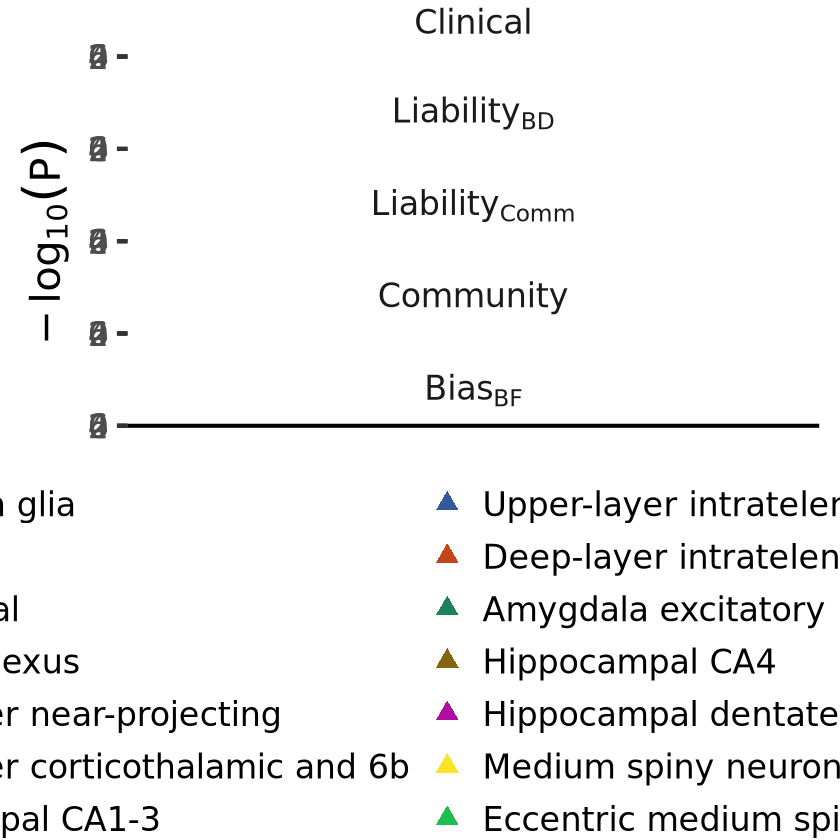

In [318]:
sldsc_plot_combias <- ggplot(enrich_table_common, aes(x = Name, y = -log10(Coefficient_P_value))) +
geom_point(aes(color = Supercluster), size = 4, shape = 17) +
scale_color_manual(values = cluster_cols) +
geom_hline(yintercept = -log10(0.05/length(unique(enrich_table_common$Name))), color = "red", linetype = "dashed") +
geom_hline(yintercept = -log10(p_cut_common), color = "blue", linetype = "dashed") +
labs(y = expression(-log[10](P)), color = "Category") + 
facet_wrap(vars(Phenotype), nrow = 5, labeller = label_parsed) +
theme_bw(base_size = 25) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_blank(), axis.ticks.x = element_blank(),
strip.background = element_blank(), strip.placement = "outside", axis.title.x = element_blank(), legend.position = "bottom") 

sldsc_plot_combias

In [319]:
sldsc_plot_combias_wol <- sldsc_plot_combias + theme(legend.position = "None")
sldsc_plot_wol <- sldsc_plot + theme(legend.position = "None")

In [320]:
library(cowplot)

shared_legend <- get_legend(sldsc_plot_combias)

In [327]:
combined_wol <- plot_grid(plotlist = list(sldsc_plot_wol,sldsc_plot_combias_wol), nrow = 2)

In [328]:
combined_wl <- plot_grid(plotlist = list(combined_wol, shared_legend), nrow = 2, rel_heights = c(1, 0.2))

In [329]:
ggsave("/local1/home/pazweifel/plots/bip_paper/combined_enrichment_plot.pdf", combined_wl, device = pdf, height = 30, width = 25)

In [266]:
ggsave("/local1/home/pazweifel/plots/bip_paper/sldsc_combined_commonbias.pdf", plot = sldsc_plot_combias, device = "pdf", width = 30, height = 20)

In [267]:
write_csv(trait.qtrait_adjusted, file = "/local1/home/pazweifel/plots/bip_paper/qtrait_results_adjusted.csv")

### Follow-up trait table formatted for paper

In [268]:
follow_up_table_adjusted

,Trait,rGF1Trait_CPM,SErGF1Trait_CPM,pvalrGF1Trait_CPM,rGF1Trait_significat_CPM,QTrait_CPM,df_CPM,p_value_CPM,Qsignificant_CPM,lSRMR_CPM,⋯,pvalrGF1Trait_FUM,rGF1Trait_significat_FUM,QTrait_FUM,df_FUM,p_value_FUM,Qsignificant_FUM,lSRMR_FUM,lSRMR_above_threshold_FUM,heterogeneity_FUM,Unconstrained_paths
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
ADHD,ADHD,0.20207690,0.04166307,1.232970e-06,*,18.988517,3,2.748977e-04,*,0.12115231,⋯,1.930875e-03,*,2.781940,1,0.09533262,NS,0.015019621,No,No,"BDII,Comm"
AN,AN,0.23074782,0.03704739,4.710703e-10,*,8.636123,3,3.454125e-02,*,0.06242593,⋯,3.179615e-08,*,1.704904,2,0.42636815,NS,0.049031017,No,No,Comm
ASD,ASD,0.20630098,0.04708236,1.177543e-05,*,12.570177,3,5.664633e-03,*,0.09544419,⋯,7.732356e-04,*,2.011669,1,0.15609350,NS,0.014673658,No,No,"BDII,Comm"
MDD,MDD,0.49773796,0.03098105,4.424979e-58,*,68.588403,3,8.560160e-15,*,0.17351999,⋯,1.220914e-35,*,2.388206,1,0.12225383,NS,0.047724207,No,No,"BDII,Comm"
Neu,Neu,0.22202042,0.02660110,7.044157e-17,*,45.176291,3,8.487918e-10,*,0.12166932,⋯,4.903826e-08,*,4.213571,1,0.04010182,*,0.009329146,No,No,"BDII,Comm"
Smoking,Smoking,0.09672052,0.03073280,1.648740e-03,*,20.467339,3,1.357970e-04,*,0.09645885,⋯,1.373443e-01,NS,3.252120,1,0.07133114,NS,0.009136744,No,No,"BDII,Comm"


In [269]:
colnames(follow_up_table_adjusted)

[1] "Trait"                     "rGF1Trait_CPM"            
 [3] "SErGF1Trait_CPM"           "pvalrGF1Trait_CPM"        
 [5] "rGF1Trait_significat_CPM"  "QTrait_CPM"               
 [7] "df_CPM"                    "p_value_CPM"              
 [9] "Qsignificant_CPM"          "lSRMR_CPM"                
[11] "lSRMR_above_threshold_CPM" "heterogeneity_CPM"        
[13] "rGF1Trait_FUM"             "SErGF1Trait_FUM"          
[15] "pvalrGF1Trait_FUM"         "rGF1Trait_significat_FUM" 
[17] "QTrait_FUM"                "df_FUM"                   
[19] "p_value_FUM"               "Qsignificant_FUM"         
[21] "lSRMR_FUM"                 "lSRMR_above_threshold_FUM"
[23] "heterogeneity_FUM"         "Unconstrained_paths"

In [270]:
follow_up_table_short <- trait.qtrait_adjusted %>% select(c(Trait, rGF1Trait_CPM, SErGF1Trait_CPM, QTrait_CPM, df_CPM, lSRMR_CPM, rGF1Trait_FUM, SErGF1Trait_FUM, QTrait_FUM, df_FUM, lSRMR_FUM, Unconstrained_paths))
follow_up_table_short

,Trait,rGF1Trait_CPM,SErGF1Trait_CPM,QTrait_CPM,df_CPM,lSRMR_CPM,rGF1Trait_FUM,SErGF1Trait_FUM,QTrait_FUM,df_FUM,lSRMR_FUM,Unconstrained_paths
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ADHD,ADHD,0.202076901,0.04166307,18.9885167,3,0.12115231,0.13163215,0.04245289,2.781940,1,0.015019621,"BDII,Comm"
ALC,ALC,0.292159549,0.06810187,-1.6617702,3,0.05879574,NA,NA,NA,NA,NA,None
AN,AN,0.230747823,0.03704739,8.6361225,3,0.06242593,0.20939741,0.03785718,1.704904,2,0.049031017,Comm
ASD,ASD,0.206300977,0.04708236,12.5701770,3,0.09544419,0.15497260,0.04609259,2.011669,1,0.014673658,"BDII,Comm"
MDD,MDD,0.497737963,0.03098105,68.5884028,3,0.17351999,0.39763055,0.03191044,2.388206,1,0.047724207,"BDII,Comm"
BMI,BMI,-0.022124074,0.02358510,11.3706979,3,0.04005225,NA,NA,NA,NA,NA,None
CAD,CAD,0.029874587,0.02515406,27.6729631,3,0.08586107,NA,NA,NA,NA,NA,None
Chrono,Chrono,-0.043299071,0.02654000,5.8262381,3,0.03081890,NA,NA,NA,NA,NA,None
CRP,CRP,-0.003599079,0.03718641,4.3214501,3,0.01945448,NA,NA,NA,NA,NA,None


In [271]:
follow_up_table_short_paper <- follow_up_table_short %>% mutate(rg_common_combined = paste0(round(rGF1Trait_CPM, 2), " (", round(SErGF1Trait_CPM, 2), ")"), Qtrait_common_combined = paste0(round(QTrait_CPM, 2), " (", df_CPM, ")")) %>%
mutate(rg_fu_combined = paste0(round(rGF1Trait_FUM, 2), " (", round(SErGF1Trait_FUM, 2), ")"), Qtrait_fu_combined = paste0(round(QTrait_FUM, 2), " (", df_FUM, ")"), lSRMR_CPM = round(lSRMR_CPM,2), lSRMR_FUM = round(lSRMR_FUM, 2)) %>%
select(c(Trait, rg_common_combined, Qtrait_common_combined, lSRMR_CPM, rg_fu_combined, Qtrait_fu_combined, lSRMR_FUM, Unconstrained_paths)) %>% arrange(Unconstrained_paths) %>%
mutate(lSRMR_FUM = ifelse(is.na(lSRMR_FUM), "-", lSRMR_FUM), rg_fu_combined = ifelse(rg_fu_combined == "NA (NA)", "-", rg_fu_combined),  Qtrait_fu_combined = ifelse(Qtrait_fu_combined == "NA (NA)", "-", Qtrait_fu_combined))

In [272]:
follow_up_table_short_paper

,Trait,rg_common_combined,Qtrait_common_combined,lSRMR_CPM,rg_fu_combined,Qtrait_fu_combined,lSRMR_FUM,Unconstrained_paths
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
ADHD,ADHD,0.2 (0.04),18.99 (3),0.12,0.13 (0.04),2.78 (1),0.02,"BDII,Comm"
ASD,ASD,0.21 (0.05),12.57 (3),0.10,0.15 (0.05),2.01 (1),0.01,"BDII,Comm"
MDD,MDD,0.5 (0.03),68.59 (3),0.17,0.4 (0.03),2.39 (1),0.05,"BDII,Comm"
Neu,Neu,0.22 (0.03),45.18 (3),0.12,0.15 (0.03),4.21 (1),0.01,"BDII,Comm"
Smoking,Smoking,0.1 (0.03),20.47 (3),0.10,0.05 (0.03),3.25 (1),0.01,"BDII,Comm"
AN,AN,0.23 (0.04),8.64 (3),0.06,0.21 (0.04),1.7 (2),0.05,Comm
ALC,ALC,0.29 (0.07),-1.66 (3),0.06,-,-,-,None
BMI,BMI,-0.02 (0.02),11.37 (3),0.04,-,-,-,None
CAD,CAD,0.03 (0.03),27.67 (3),0.09,-,-,-,None


In [273]:
knitr::kable(follow_up_table_short_paper, format = "pipe")



|        |Trait   |rg_common_combined |Qtrait_common_combined | lSRMR_CPM|rg_fu_combined |Qtrait_fu_combined |lSRMR_FUM |Unconstrained_paths |
|:-------|:-------|:------------------|:----------------------|---------:|:--------------|:------------------|:---------|:-------------------|
|ADHD    |ADHD    |0.2 (0.04)         |18.99 (3)              |      0.12|0.13 (0.04)    |2.78 (1)           |0.02      |BDII,Comm           |
|ASD     |ASD     |0.21 (0.05)        |12.57 (3)              |      0.10|0.15 (0.05)    |2.01 (1)           |0.01      |BDII,Comm           |
|MDD     |MDD     |0.5 (0.03)         |68.59 (3)              |      0.17|0.4 (0.03)     |2.39 (1)           |0.05      |BDII,Comm           |
|Neu     |Neu     |0.22 (0.03)        |45.18 (3)              |      0.12|0.15 (0.03)    |4.21 (1)           |0.01      |BDII,Comm           |
|Smoking |Smoking |0.1 (0.03)         |20.47 (3)              |      0.10|0.05 (0.03)    |3.25 (1)           |0.01      |BDII,Comm          

In [274]:
write.table(x = follow_up_table_short_paper, file = "follow_up_table_bipolar.tsv", sep = "\t", row.names = FALSE)

### Create enrichment table

In [275]:
unique(enrich_table$Phenotype)
unique(enrich_table_common$Phenotype)

[1] Clinical        Liability[BD]   Liability[Comm] Community      
[5] Bias[Neu]      
Levels: Clinical Liability[BD] Liability[Comm] Community Bias[Neu]

[1] Clinical        Liability[BD]   Liability[Comm] Community      
[5] Bias[BF]       
Levels: Clinical Liability[BD] Liability[Comm] Community Bias[BF]

In [276]:
write_csv(enrich_table, "/local1/home/pazweifel/plots/bip_paper/enrichments_neuroticism.csv")
write_csv(enrich_table_common, "/local1/home/pazweifel/plots/bip_paper/enrichments_bias_facotr.csv")

### Comparison of correlations, Community and biased cleaned one

In [277]:
#need Clinical, Community, Liability Community Neu, Liability Community common bias, ADHD, MDD, PTSD, Clinical MDD and Help

In [278]:
path_original_base <- "/local1/scratch/pazweifel/sumstats_ambits/munged/"
path_factor_base <- "/local1/scratch/pazweifel/sumstats_ambits/factor_sumstats_munged/"

reg_sumstats <- c("Clin", "Comm", "ADHD", "MDD", "PTSD")
factor_sumstats <- c("gwasbysub_common_bias_community_liab", "gwasbysub_neuro_community_liab")

samples <- c("/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_clinical_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/bip2024_eur_community_no23andMe_wbeta_use_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDI_cleaned_neff.sumstats.gz",
             "/local1/scratch/pazweifel/heritability_analysis/ldsc_correlation_bipolar/sumstats/pgc-bip2021-BDII_cleaned_neff.sumstats.gz")

In [279]:
samples_correlations <- c(samples[1:2])
for (phenotype in reg_sumstats[3:length(reg_sumstats)]){
    if (phenotype == "MDD"){
            samples_correlations <- c(samples_correlations, "/local1/scratch/pazweifel/jolien_paper_sumstats/munged_sumstats/mdd_munged.sumstats.gz")
        } else {
            samples_correlations <- c(samples_correlations, paste0(other_basepath,phenotype,".sumstats.gz"))
        }}

samples_factors <- paste0(path_factor_base, factor_sumstats, ".sumstats.gz")

In [280]:
samples_correlations_all <- c(samples_correlations, samples_factors)

In [281]:
covstruct_path_correlations <- "matrices/correlations.R"

trait_names <- c(reg_sumstats, "Comm_cBias_corrected", "Comm_Neu_corrected")
pop.prev <- c(all_prevalences[reg_sumstats], NA, NA)
samp.prev <- ifelse(is.na(pop.prev), NA, 0.5)

In [282]:
if (!file.exists(covstruct_path_correlations)){
    covstruct <- ldsc(
        traits = samples_correlations_all,
        sample.prev = samp.prev,
        population.prev = pop.prev,
        ld = ld,
        wld = weights,
        stand = TRUE,
        trait.names = trait_names)
    dput(covstruct, covstruct_path_correlations, control = c("all", "digits17"))
    }   

In [283]:
correlation_covstruct <- dget("matrices/correlations.R")

In [284]:
sstand <- correlation_covstruct$S_Stand
vstand <- correlation_covstruct$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:dim(vstand)[1]), function(index) vstand[index, index])
                      
#copy the structure of the sstand matrix
error_matrix <- sstand
                      
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
                      
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
error_matrix
                      
#vectorize the error matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)

#initialize the dataframe for the matrix values of both matrices
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

#vectorize the standard matrix and store matrix values in df columns
sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 4)
expanded_df$se <- round(error_vectorized, 4)

Clin,Comm,ADHD,MDD,PTSD,Comm_cBias_corrected,Comm_Neu_corrected
0.05691824,0.05697720,0.04664759,0.03809381,0.06992250,0.05984483,0.05860182
0.05697720,0.07845389,0.05738641,0.04026576,0.08388788,0.07857207,0.07712694
0.04664759,0.05738641,0.07429866,0.03913456,0.08632555,0.05888781,0.05898757
0.03809381,0.04026576,0.03913456,0.03792161,0.05119897,0.04249366,0.04022123
0.06992250,0.08388788,0.08632555,0.05119897,0.18146762,0.08835136,0.09169249
0.05984483,0.07857207,0.05888781,0.04249366,0.08835136,0.08013830,0.08097050
0.05860182,0.07712694,0.05898757,0.04022123,0.09169249,0.08097050,0.08066669


In [285]:
Comm_phenos <- c("Comm", "Comm_cBias_corrected", "Comm_Neu_corrected")

In [286]:
filtered_corr_df <- expanded_df %>% filter(y %in% Comm_phenos & !x %in% Comm_phenos)

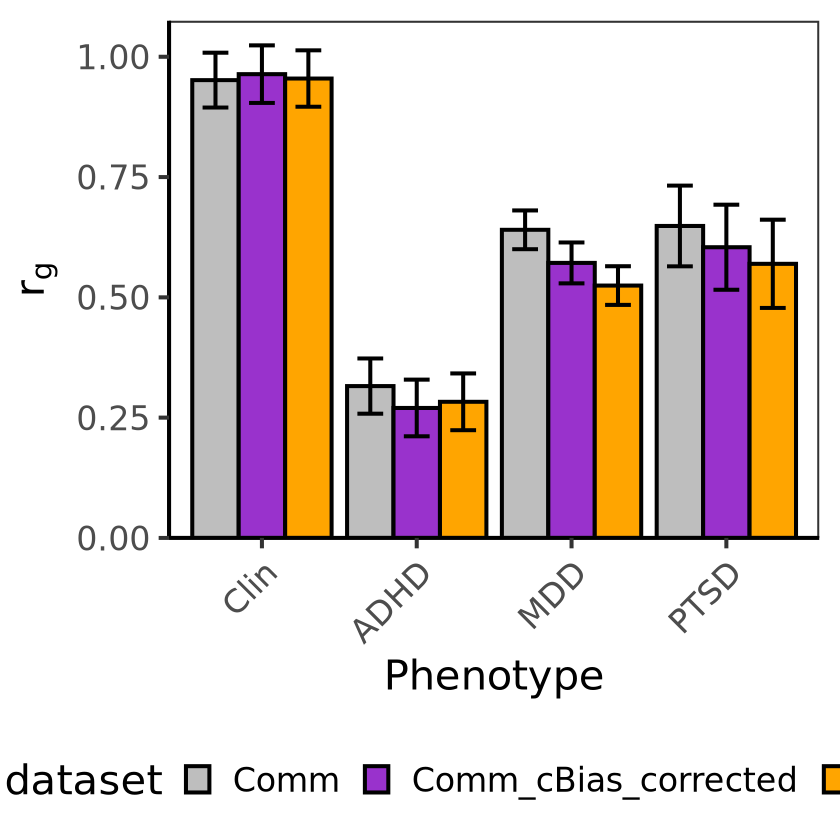

In [313]:
comm_corr_plot <- ggplot(filtered_corr_df, aes(x = x, y = values, fill = y, group = y)) +
geom_col(color = "black", position = position_dodge()) +
geom_errorbar(aes(ymin = values - se, ymax = values + se), position = position_dodge(width = 0.9), width = 0.5) +
theme_bw(base_size = 25) +
scale_fill_manual(values = c("grey", "darkorchid", "orange")) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "bottom") +
labs(y = expression(r[g]), x = "Phenotype", fill = "Community dataset") +
scale_y_continuous(expand = expansion(mult = c(0,0.05))) 

comm_corr_plot

In [330]:
ggsave("/local1/home/pazweifel/plots/bip_paper/comm_phenos_correlations.pdf", plot = comm_corr_plot, device = "pdf", width = 15, height = 10)

In [315]:
write_csv(filtered_corr_df, "/local1/home/pazweifel/plots/bip_paper/community_cleaned_correlations.csv")

### Make the plot for the GWAS by subtraction generated liability correlations

In [306]:
combined_table
bias_corrected_liability_correlations

External_trait,rg,se,Internal_trait
<chr>,<dbl>,<chr>,<chr>
AN,0.9986611,0.0532456383023662,Community
ASD,0.9957128,0.0559421139147135,Community
Neu,0.9998896,0.0512111393480379,Community
Smoking,0.9687430,0.0482220142838341,Community
ADHD,0.9719855,0.0725500269844533,BDII
ASD,0.9592717,0.0705444803059959,BDII
Neu,0.9889309,0.0715933435019714,BDII
Smoking,0.9317776,0.059305645215572,BDII


External_trait,rg,se,Internal_trait
<chr>,<dbl>,<dbl>,<chr>
Bias_Factor,0.943,0.060,BDII
Bias_Factor,0.962,0.046,Comm


In [307]:
base_covstruct <- dget("matrices/BD.R")

In [308]:
sstand <- base_covstruct$S_Stand
vstand <- base_covstruct$V_Stand

#extract the standard error
vstand_diag <- sapply(c(1:10), function(index) vstand[index, index])
                      
#copy the structure of the sstand matrix
error_matrix <- sstand
                      
#overwrite lower triangle with vstand values
error_matrix[lower.tri(error_matrix, diag = TRUE)] <- vstand_diag
                      
#transpose the matrix and copy the values to the upper triangle, making it symmetric
error_matrix[upper.tri(error_matrix)] <- t(error_matrix)[upper.tri(error_matrix)]
error_matrix <- sqrt(error_matrix)
error_matrix
                      
#vectorize the error matrix so that you can use it for the ggplot
error_vectorized <- c(error_matrix)

#initialize the dataframe for the matrix values of both matrices
tempnames <- dimnames(sstand)[[2]]
expanded_df <- expand.grid(x = tempnames, y = tempnames)

#vectorize the standard matrix and store matrix values in df columns
sstand_vectorized <- c(sstand)
expanded_df$values <- round(sstand_vectorized, 3)
expanded_df$se <- round(error_vectorized, 3)
observed <- filter(expanded_df, x == "Clin"  &( y == "Comm" | y== "BDII")) %>% rename(Internal_trait = y, rg = values) %>% mutate(External_trait = "Observed") %>% select(-c(x))

Clin,Comm,BDI,BDII
0.05691824,0.05697720,0.05415812,0.07875669
0.05697720,0.07845389,0.05672839,0.08664490
0.05415812,0.05672839,0.05427365,0.07053401
0.07875669,0.08664490,0.07053401,0.15183248


In [309]:
combined_table <- combined_table %>% mutate(se = as.double(se))
gwasbysub_liability_correlations <- bind_rows(combined_table, bias_corrected_liability_correlations, observed) %>% mutate(Internal_trait = recode(Internal_trait, "Comm" = "Community")) %>% arrange(desc(rg)) %>%
mutate(External_trait = factor(External_trait, levels = unique(External_trait))) %>% arrange(Internal_trait, desc(rg)) %>% mutate(Internal_trait = factor(Internal_trait, levels = unique(Internal_trait)))


In [310]:
gwasbysub_liability_correlations 

External_trait,rg,se,Internal_trait
<fct>,<dbl>,<dbl>,<fct>
Neu,0.9889309,0.07159334,BDII
ADHD,0.9719855,0.07255003,BDII
ASD,0.9592717,0.07054448,BDII
Bias_Factor,0.9430000,0.06000000,BDII
Smoking,0.9317776,0.05930565,BDII
Observed,0.9050000,0.07900000,BDII
Neu,0.9998896,0.05121114,Community
AN,0.9986611,0.05324564,Community
ASD,0.9957128,0.05594211,Community


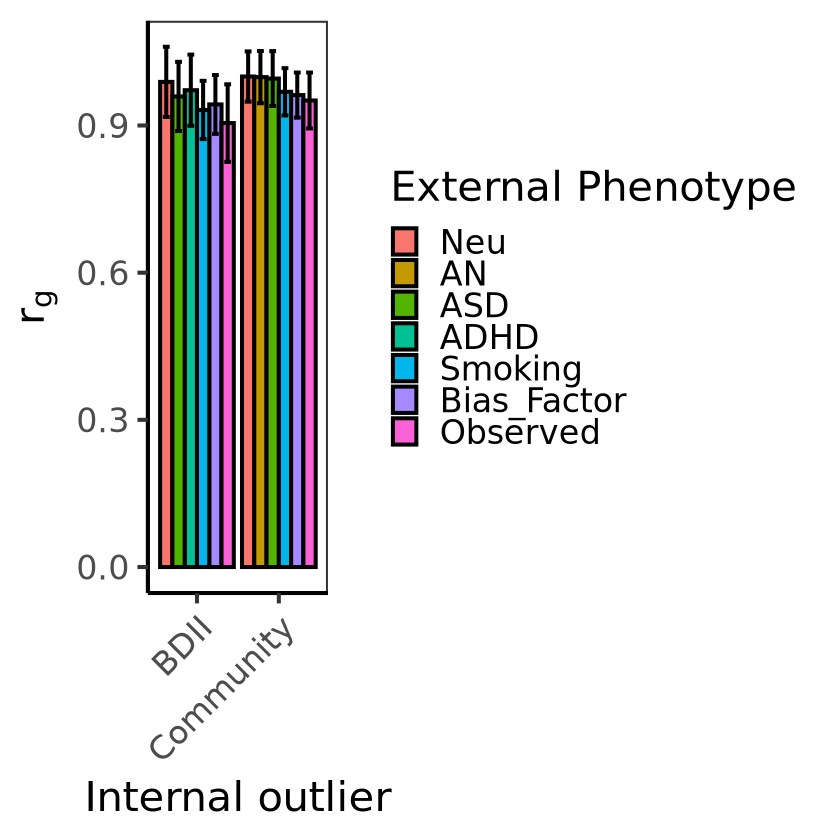

In [311]:
correlations_gwasbysub_plot <- ggplot(gwasbysub_liability_correlations, aes(x = Internal_trait, y = rg, fill = External_trait, group = External_trait)) +
geom_col(color = "black", position = position_dodge()) +
geom_errorbar(aes(ymin = rg - se, ymax = rg + se), position = position_dodge(width = 0.9), width = 0.5) +
theme_bw(base_size = 25) +
theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
panel.background = element_blank(), axis.line = element_line(colour = "black"), axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(y = expression(r[g]), x = "Internal outlier", fill = "External Phenotype")

correlations_gwasbysub_plot

In [312]:
ggsave("/local1/home/pazweifel/plots/bip_paper/gwasbysub_correlations_liability.pdf", correlations_gwasbysub_plot, device = "pdf", width = 10, height = 8)